# **Identification, Elimination, Optimization:**  
A Linear Programming and Machine Learning Approach for Rice Supply Chain Profit Maximization 

## **DATA OVERVIEW**

In this project, the data used is rice supply chain data in West Java, Indonesia, specifically in 5 districts, namely Garut, Subang, Karawang, Indramayu, and Tasikmalaya. There are 5 main actors in the rice supply chain process, farmers, millers, middlemen, wholesalers, and retailers, each of them has a role in the supply chain process. Each actor has different operational characteristics so that the variables they have are also different according to their respective roles. In general, the dataset includes various input variables such as labor costs, rent, raw material purchases and output variables such as production value or sales value. With this data structure, analysis can be carried out to measure the efficiency of each actor, see the factors causing inefficiency, and produce data-based optimization recommendations to improve supply chain performance.  

**IMPORT LIBRARY**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pulp
from pulp import *
import shap
from scipy import stats
from scipy.optimize import linprog
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import (GridSearchCV, KFold,cross_val_score, cross_val_predict,train_test_split)
from sklearn.metrics import (r2_score, mean_absolute_error,mean_absolute_percentage_error)


### **LOAD FARM DATA**

In [ ]:
df_farm = pd.read_excel('Data Raw/Farmer Data.xlsx')
df_farm.head(4)

,Kabupaten,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR)
0,Garut,1,2800,4900000,1400000,644000.0,3640000,364000.0,470000.0,16200000.0
1,Garut,2,1400,4900000,500000,322000.0,1820000,182000.0,540000.0,8100000.0
2,Garut,3,2000,2000000,700000,200000.0,2600000,260000.0,690000.0,14850000.0
3,Garut,4,1000,1800000,800000,230000.0,1300000,100000.0,340000.0,13050000.0


In [ ]:
df_farm.columns

Index(['Kabupaten', 'dmu', 'Land area (m2)', 'Land lease value (IDR)',
       'Labor cost (IDR)', 'Seed purchase value (IDR)',
       'Fertilizer purchase value (IDR)', 'Pesticide purchase value (IDR)',
       'Equipment rent value (IDR)', 'Production value (IDR)'],
      dtype='object')

In [ ]:
df_farm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Kabupaten                        400 non-null    object 
 1   dmu                              400 non-null    int64  
 2   Land area (m2)                   400 non-null    int64  
 3   Land lease value (IDR)           400 non-null    int64  
 4   Labor cost (IDR)                 400 non-null    int64  
 5   Seed purchase value (IDR)        400 non-null    float64
 6   Fertilizer purchase value (IDR)  400 non-null    int64  
 7   Pesticide purchase value (IDR)   400 non-null    float64
 8   Equipment rent value (IDR)       400 non-null    float64
 9   Production value (IDR)           400 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 31.4+ KB


In [ ]:
df_farm.isnull().sum()

Kabupaten                          0
dmu                                0
Land area (m2)                     0
Land lease value (IDR)             0
Labor cost (IDR)                   0
Seed purchase value (IDR)          0
Fertilizer purchase value (IDR)    0
Pesticide purchase value (IDR)     0
Equipment rent value (IDR)         0
Production value (IDR)             0
dtype: int64

In [ ]:
print(f"Number of Duplicates : {df_farm.duplicated().sum()}")

Number of Duplicates : 0


### **LOAD MILLER DATA**

In [ ]:
df_miller = pd.read_excel('Data Raw/Miller Data.xlsx')
df_miller.head(4)

,Kabupaten,dmu,Number of machines (unit),Value of milled grains (IDR),Amount of milled rice (Kg),Labor cost (IDR),Supporting equipment cost (IDR),nilaiberashasilgiling,Total revenue of milling machine (IDR)
0,Garut,1,4,331000000.0,40000,8.987595e+06,1.599538e+06,3.870532e+08,37440000
1,Garut,2,5,315000000.0,42000,7.190076e+06,1.599538e+06,4.200000e+08,35000000
2,Garut,3,2,240000000.0,36000,2.000000e+06,3.000000e+06,3.600000e+08,30000000
3,Garut,4,2,270000000.0,36000,4.500000e+06,6.000000e+06,3.600000e+08,30000000


In [ ]:
df_miller.columns

Index(['Kabupaten', 'dmu', 'Number of machines (unit)',
       'Value of milled grains (IDR)', 'Amount of milled rice (Kg)',
       'Labor cost (IDR)', 'Supporting equipment cost (IDR)',
       'nilaiberashasilgiling', 'Total revenue of milling machine (IDR)'],
      dtype='object')

In [ ]:
df_miller.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 9 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Kabupaten                               105 non-null    object 
 1   dmu                                     105 non-null    int64  
 2   Number of machines (unit)               105 non-null    int64  
 3   Value of milled grains (IDR)            105 non-null    float64
 4   Amount of milled rice (Kg)              105 non-null    int64  
 5   Labor cost (IDR)                        105 non-null    float64
 6   Supporting equipment cost (IDR)         105 non-null    float64
 7   nilaiberashasilgiling                   105 non-null    float64
 8   Total revenue of milling machine (IDR)  105 non-null    int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 7.5+ KB


In [ ]:
df_miller.isnull().sum()

Kabupaten                                 0
dmu                                       0
Number of machines (unit)                 0
Value of milled grains (IDR)              0
Amount of milled rice (Kg)                0
Labor cost (IDR)                          0
Supporting equipment cost (IDR)           0
nilaiberashasilgiling                     0
Total revenue of milling machine (IDR)    0
dtype: int64

In [ ]:
print(f"Number of Duplicates : {df_miller.duplicated().sum()}")

Number of Duplicates : 0


### **LOAD MIDDLEMEN DATA**

In [ ]:
df_middleman = pd.read_excel('Data Raw/Middlemen Data.xlsx')
df_middleman.head(4)

,Kabupaten,dmu,Total rice purchase (kg),Total rice purchase (IDR),Building rent cost (IDR),Labor cost (IDR),Supporting equipment cost (IDR),Value of rice sold (IDR),Total precipitation (%),Precipitation quality (%)
0,Garut,1,700,6300000.0,1000000,5.000000e+05,300000,6300000,5,5
1,Garut,2,700,6300000.0,1000000,1.000000e+06,300000,6300000,5,5
2,Garut,3,1000,10000000.0,3200000,5.035347e+06,1200000,7040000,5,5
3,Garut,4,900,9000000.0,1100000,6.400000e+06,180000,7920000,20,10


In [ ]:
df_middleman.columns

Index(['Kabupaten', 'dmu', 'Total rice purchase (kg)',
       'Total rice purchase (IDR)', 'Building rent cost (IDR)',
       'Labor cost (IDR)', 'Supporting equipment cost (IDR)',
       'Value of rice sold (IDR)', 'Total precipitation (%)',
       'Precipitation quality (%)'],
      dtype='object')

In [ ]:
df_middleman.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Kabupaten                        104 non-null    object 
 1   dmu                              104 non-null    int64  
 2   Total rice purchase (kg)         104 non-null    int64  
 3   Total rice purchase (IDR)        104 non-null    float64
 4   Building rent cost (IDR)         104 non-null    int64  
 5   Labor cost (IDR)                 104 non-null    float64
 6   Supporting equipment cost (IDR)  104 non-null    int64  
 7   Value of rice sold (IDR)         104 non-null    int64  
 8   Total precipitation (%)          104 non-null    int64  
 9   Precipitation quality (%)        104 non-null    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 8.3+ KB


In [ ]:
df_middleman.isnull().sum()

Kabupaten                          0
dmu                                0
Total rice purchase (kg)           0
Total rice purchase (IDR)          0
Building rent cost (IDR)           0
Labor cost (IDR)                   0
Supporting equipment cost (IDR)    0
Value of rice sold (IDR)           0
Total precipitation (%)            0
Precipitation quality (%)          0
dtype: int64

In [ ]:
print(f"Number of Duplicates : {df_middleman.duplicated().sum()}")

Number of Duplicates : 0


### **LOAD WHOLESALER DATA**

In [ ]:
df_wholesaler = pd.read_excel('Data Raw/Wholesale Data.xlsx')
df_wholesaler.head(4)

,Kabupaten,dmu,Value of rice purchase (IDR),Building rent cost (IDR),Labor cost (IDR),Supporting equipment cost (IDR),Precipitation quality (%),Value of rice sold (IDR)
0,Garut,1,80000000.0,32500000,4500000,1000000,5,100000000.0
1,Garut,2,9000000.0,10000000,600000,600000,5,9000000.0
2,Garut,3,9000000.0,10000000,600000,600000,5,9000000.0
3,Garut,4,16000000.0,10000000,1000000,7000000,5,16000000.0


In [ ]:
df_wholesaler.columns

Index(['Kabupaten', 'dmu', 'Value of rice purchase (IDR)',
       'Building rent cost (IDR)', 'Labor cost (IDR)',
       'Supporting equipment cost (IDR)', 'Precipitation quality (%)',
       'Value of rice sold (IDR)'],
      dtype='object')

In [ ]:
df_wholesaler.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Kabupaten                        104 non-null    object 
 1   dmu                              104 non-null    int64  
 2   Value of rice purchase (IDR)     104 non-null    float64
 3   Building rent cost (IDR)         104 non-null    int64  
 4   Labor cost (IDR)                 104 non-null    int64  
 5   Supporting equipment cost (IDR)  104 non-null    int64  
 6   Precipitation quality (%)        104 non-null    int64  
 7   Value of rice sold (IDR)         104 non-null    float64
dtypes: float64(2), int64(5), object(1)
memory usage: 6.6+ KB


In [ ]:
df_wholesaler.isnull().sum()

Kabupaten                          0
dmu                                0
Value of rice purchase (IDR)       0
Building rent cost (IDR)           0
Labor cost (IDR)                   0
Supporting equipment cost (IDR)    0
Precipitation quality (%)          0
Value of rice sold (IDR)           0
dtype: int64

In [ ]:
print(f"Number of Duplicates : {df_wholesaler.duplicated().sum()}")

Number of Duplicates : 0


### **LOAD RETAIL DATA**

In [ ]:
df_retail = pd.read_excel('Data Raw/Retail Data.xlsx')
df_retail.head(4)

,Kabupaten,dmu,Value of rice purchase (IDR),Building rent cost (IDR),Labor cost (IDR),Supporting equipment cost (IDR),Value of rice sold (IDR),Precipitation quality (%)
0,Garut,1,1375000,200000,3000000.0,150000,1750000,0.05
1,Garut,2,2700000,200000,3000000.0,200000,3500000,0.05
2,Garut,3,2700000,200000,3000000.0,200000,3500000,0.05
3,Garut,4,2695000,200000,3000000.0,30000,3000000,0.10


In [ ]:
df_retail.columns

Index(['Kabupaten', 'dmu', 'Value of rice purchase (IDR)',
       'Building rent cost (IDR)', 'Labor cost (IDR)',
       'Supporting equipment cost (IDR)', 'Value of rice sold (IDR)',
       'Precipitation quality (%)'],
      dtype='object')

In [ ]:
df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Kabupaten                        102 non-null    object 
 1   dmu                              102 non-null    int64  
 2   Value of rice purchase (IDR)     102 non-null    int64  
 3   Building rent cost (IDR)         102 non-null    int64  
 4   Labor cost (IDR)                 102 non-null    float64
 5   Supporting equipment cost (IDR)  102 non-null    int64  
 6   Value of rice sold (IDR)         102 non-null    int64  
 7   Precipitation quality (%)        102 non-null    float64
dtypes: float64(2), int64(5), object(1)
memory usage: 6.5+ KB


In [ ]:
df_retail.isnull().sum()

Kabupaten                          0
dmu                                0
Value of rice purchase (IDR)       0
Building rent cost (IDR)           0
Labor cost (IDR)                   0
Supporting equipment cost (IDR)    0
Value of rice sold (IDR)           0
Precipitation quality (%)          0
dtype: int64

In [ ]:
print(f"Number of Duplicates : {df_retail.duplicated().sum()}")

Number of Duplicates : 0


### **DATA DESCRIPTION**

| Actor | Variable | Description | Data Type |
| :--- | :--- | :--- | :---: |
| **Farmer** | Land Area | Land used by farmers | `int64` |
| | Land lease value | Cost of renting land | `int64` |
| | Labor cost | Workers hiring cost | `int64` |
| | Seed purchase value | Cost spent on seeds | `float64` |
| | Fertilizer purchase value | Cost spent on fertilizer | `int64` |
| | Pesticide purchase value | Cost spent on pesticide | `float64` |
| | Equipment rent value | Cost for renting equipment | `float64` |
| | Production value | Total revenue | `float64` |
| **Miller** | Number of machines | Total milling machine units | `int64` |
| | Value of milled grains | Value of unprocessed grain | `float64` |
| | Amount of milled rice | Total weight of rice | `int64` |
| | Labor cost | Workers hiring cost | `float64` |
| | Supporting equipment cost | Cost spent on machine maintenance | `float64` |
| | Value of milled rice | Value of milled rice (*nilaiberashasilgiling*) | `float64` |
| | Total revenue of milling machine | Total gross income for milling | `int64` |
| **Middlemen** | Total rice purchase (kg) | Weight of bought rice | `int64` |
| | Total rice purchase (idr) | Cost of buying rice | `float64` |
| | Building rent cost | Cost of building rent | `int64` |
| | Labor cost | Workers hiring cost | `float64` |
| | Supporting equipment cost | Cost spent on equipment | `int64` |
| | Value of rice sold | Revenue of selling rice | `int64` |
| | Total precipitation | Percentage loss of rice | `int64` |
| | Precipitation quality | Loss quality | `int64` |
| **Wholesaler** | Value of rice purchase | Cost spent on rice | `float64` |
| | Building rent cost | Cost of building rent | `int64` |
| | Labor cost | Workers hiring cost | `int64` |
| | Supporting equipment cost | Cost spent on equipments | `int64` |
| | Precipitation quality | Loss quality | `int64` |
| | Value of rice sold | Revenue of selling rice | `float64` |
| **Retailer** | Value of rice purchase | Cost spent on rice | `int64` |
| | Building rent cost | Cost of building rent | `int64` |
| | Labor cost | Workers hiring cost | `int64` |
| | Supporting equipment cost | Cost spent on equipments | `int64` |
| | Value of rice sold | Revenue of selling rice | `float64` |
| | Precipitation quality | Loss quality | `int64` |

## **FEATURE GENERATING**

In [ ]:
def dea_input_oriented(inputs, outputs, rts='CRS'):
    n = inputs.shape[0]   
    m = inputs.shape[1]   
    s = outputs.shape[1]  
    scores = []

    for i in range(n):
        c = np.zeros(1 + n)
        c[0] = 1  
        A_out = np.hstack([-np.zeros((s, 1)), -outputs.T])  
        b_out = -outputs[i]  

        A_in = np.hstack([-inputs[i].reshape(-1, 1), inputs.T])  
        b_in = np.zeros(m)

        A_ub = np.vstack([A_out, A_in])
        b_ub = np.concatenate([b_out, b_in])

        bounds = [(None, None)] + [(0, None)] * n

        if rts == 'VRS':
            A_eq = np.hstack([[0], np.ones(n)]).reshape(1, -1)
            b_eq = np.array([1.0])
            res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                          bounds=bounds, method='highs')
        else:
            res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

        if res.success:
            scores.append(round(res.x[0], 6))
        else:
            scores.append(np.nan)

    return scores

### **FARM DATA**

In [ ]:
# Create Financial Metrics for Farmers
df_farm['Total Cost'] = (
    df_farm['Equipment rent value (IDR)']+
    df_farm['Fertilizer purchase value (IDR)']+
    df_farm['Labor cost (IDR)']+
    df_farm['Land lease value (IDR)']+
    df_farm['Pesticide purchase value (IDR)']+
    df_farm['Seed purchase value (IDR)']
)

df_farm['Profit'] = (df_farm['Production value (IDR)'] - df_farm['Total Cost'])

df_farm['Margin (%)'] = (df_farm['Profit'] / df_farm['Production value (IDR)']) * 100

In [ ]:
# Create DEA Score
farmer_inputs = df_farm[[
    'Land area (m2)',
    'Land lease value (IDR)',
    'Labor cost (IDR)',
    'Seed purchase value (IDR)',
    'Fertilizer purchase value (IDR)',
    'Pesticide purchase value (IDR)',
    'Equipment rent value (IDR)'
]].values

farmer_outputs = df_farm[['Production value (IDR)']].values

farmer_crs = dea_input_oriented(farmer_inputs, farmer_outputs, rts='CRS')
farmer_vrs = dea_input_oriented(farmer_inputs, farmer_outputs, rts='VRS')

df_farm['DEA_CRS'] = farmer_crs
df_farm['DEA_VRS'] = farmer_vrs
df_farm['Scale_Efficiency'] = df_farm['DEA_CRS'] / df_farm['DEA_VRS']
df_farm.head()

,Kabupaten,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR),Total Cost,Profit,Margin (%),DEA_CRS,DEA_VRS,Scale_Efficiency
0,Garut,1,2800,4900000,1400000,644000.0,3640000,364000.0,470000.0,16200000.0,11418000.0,4782000.0,29.518519,0.258545,0.364351,0.709604
1,Garut,2,1400,4900000,500000,322000.0,1820000,182000.0,540000.0,8100000.0,8264000.0,-164000.0,-2.024691,0.170419,0.364992,0.466912
2,Garut,3,2000,2000000,700000,200000.0,2600000,260000.0,690000.0,14850000.0,6450000.0,8400000.0,56.565657,0.364054,0.435637,0.835682
3,Garut,4,1000,1800000,800000,230000.0,1300000,100000.0,340000.0,13050000.0,4570000.0,8480000.0,64.980843,0.497760,0.744548,0.668540
4,Garut,5,800,1520000,580000,184000.0,1040000,104000.0,350000.0,10200000.0,3778000.0,6422000.0,62.960784,0.375552,0.649918,0.577845


### **MILLER DATA**

In [ ]:
# create financial metrics for millers
df_miller['Revenue'] = (
    df_miller['Total revenue of milling machine (IDR)']+ 
    df_miller['nilaiberashasilgiling']
)

df_miller['Total Cost'] = (
    df_miller['Labor cost (IDR)']+
    df_miller['Supporting equipment cost (IDR)']+
    df_miller['Value of milled grains (IDR)']
)

df_miller['Profit'] = (df_miller['Revenue'] - df_miller['Total Cost'])

df_miller['Margin (%)'] = (df_miller['Profit'] / df_miller['Revenue']) * 100

In [ ]:
miller_inputs = df_miller[[
    'Total revenue of milling machine (IDR)',
    'Labor cost (IDR)',
    'Supporting equipment cost (IDR)',
    'Value of milled grains (IDR)'
]].values

miller_outputs = df_miller[['Revenue']].values

miller_crs = dea_input_oriented(miller_inputs, miller_outputs, rts='CRS')
miller_vrs = dea_input_oriented(miller_inputs, miller_outputs, rts='VRS')

df_miller['DEA_CRS'] = miller_crs
df_miller['DEA_VRS'] = miller_vrs
df_miller['Scale_Efficiency'] = df_miller['DEA_CRS'] / df_miller['DEA_VRS']
df_miller.head()

,Kabupaten,dmu,Number of machines (unit),Value of milled grains (IDR),Amount of milled rice (Kg),Labor cost (IDR),Supporting equipment cost (IDR),nilaiberashasilgiling,Total revenue of milling machine (IDR),Revenue,Total Cost,Profit,Margin (%),DEA_CRS,DEA_VRS,Scale_Efficiency
0,Garut,1,4,331000000.0,40000,8.987595e+06,1.599538e+06,3.870532e+08,37440000,4.244932e+08,3.415871e+08,8.290606e+07,19.530598,0.811273,0.811587,0.999613
1,Garut,2,5,315000000.0,42000,7.190076e+06,1.599538e+06,4.200000e+08,35000000,4.550000e+08,3.237896e+08,1.312104e+08,28.837447,0.913476,0.913392,1.000092
2,Garut,3,2,240000000.0,36000,2.000000e+06,3.000000e+06,3.600000e+08,30000000,3.900000e+08,2.450000e+08,1.450000e+08,37.179487,1.000000,1.000000,1.000000
3,Garut,4,2,270000000.0,36000,4.500000e+06,6.000000e+06,3.600000e+08,30000000,3.900000e+08,2.805000e+08,1.095000e+08,28.076923,0.926534,0.905504,1.023225
4,Garut,5,1,300000000.0,38412,8.950147e+06,1.599538e+06,3.841200e+08,31200000,4.153200e+08,3.105497e+08,1.047703e+08,25.226407,0.876528,0.878447,0.997815


### **MIDDLEMEN DATA**

In [ ]:
# create financial feature for middlemen metric

df_middleman['Total Cost'] = (
    df_middleman['Building rent cost (IDR)']+
    df_middleman['Labor cost (IDR)']+
    df_middleman['Supporting equipment cost (IDR)']+
    df_middleman['Total rice purchase (IDR)']
)

df_middleman['Profit'] = (df_middleman['Value of rice sold (IDR)'] - df_middleman['Total Cost'])

df_middleman['Margin (%)'] = (df_middleman['Profit'] / df_middleman['Value of rice sold (IDR)']) * 100


In [ ]:
middlemen_inputs = df_middleman[[
    'Total rice purchase (IDR)',
    'Building rent cost (IDR)',
    'Labor cost (IDR)',
    'Supporting equipment cost (IDR)'
]].values

middlemen_outputs = df_middleman[['Value of rice sold (IDR)']].values

middlemen_crs = dea_input_oriented(middlemen_inputs, middlemen_outputs, rts='CRS')
middlemen_vrs = dea_input_oriented(middlemen_inputs, middlemen_outputs, rts='VRS')

df_middleman['DEA_CRS'] = middlemen_crs
df_middleman['DEA_VRS'] = middlemen_vrs
df_middleman['Scale_Efficiency'] = df_middleman['DEA_CRS'] / df_middleman['DEA_VRS']
df_middleman.head()

,Kabupaten,dmu,Total rice purchase (kg),Total rice purchase (IDR),Building rent cost (IDR),Labor cost (IDR),Supporting equipment cost (IDR),Value of rice sold (IDR),Total precipitation (%),Precipitation quality (%),Total Cost,Profit,Margin (%),DEA_CRS,DEA_VRS,Scale_Efficiency
0,Garut,1,700,6300000.0,1000000,5.000000e+05,300000,6300000,5,5,8.100000e+06,-1.800000e+06,-28.571429,0.529848,1.000000,0.529848
1,Garut,2,700,6300000.0,1000000,1.000000e+06,300000,6300000,5,5,8.600000e+06,-2.300000e+06,-36.507937,0.529848,1.000000,0.529848
2,Garut,3,1000,10000000.0,3200000,5.035347e+06,1200000,7040000,5,5,1.943535e+07,-1.239535e+07,-176.070267,0.373013,0.658093,0.566809
3,Garut,4,900,9000000.0,1100000,6.400000e+06,180000,7920000,20,10,1.668000e+07,-8.760000e+06,-110.606061,0.468596,1.000000,0.468596
4,Garut,5,900,7470000.0,1500000,2.400000e+06,300000,8100000,5,5,1.167000e+07,-3.570000e+06,-44.074074,0.574534,0.986013,0.582684


### **WHOLESALER DATA**

In [ ]:
df_wholesaler['Total Cost'] = (
    df_wholesaler['Building rent cost (IDR)']+
    df_wholesaler['Labor cost (IDR)']+
    df_wholesaler['Supporting equipment cost (IDR)']+
    df_wholesaler['Value of rice purchase (IDR)']
)

df_wholesaler['Profit'] = (df_wholesaler['Value of rice sold (IDR)'] - df_wholesaler['Total Cost'])

df_wholesaler['Margin (%)'] = (df_wholesaler['Profit'] / df_wholesaler['Value of rice sold (IDR)']) * 100

In [ ]:
wholesaler_inputs = df_wholesaler[[
    'Value of rice purchase (IDR)',
    'Building rent cost (IDR)',
    'Labor cost (IDR)',
    'Supporting equipment cost (IDR)'
]].values

wholesaler_outputs = df_wholesaler[['Value of rice sold (IDR)']].values

wholesaler_crs = dea_input_oriented(wholesaler_inputs, wholesaler_outputs, rts='CRS')
wholesaler_vrs = dea_input_oriented(wholesaler_inputs, wholesaler_outputs, rts='VRS')

df_wholesaler['DEA_CRS'] = wholesaler_crs
df_wholesaler['DEA_VRS'] = wholesaler_vrs
df_wholesaler['Scale_Efficiency'] = df_wholesaler['DEA_CRS'] / df_wholesaler['DEA_VRS']
df_wholesaler.head()


,Kabupaten,dmu,Value of rice purchase (IDR),Building rent cost (IDR),Labor cost (IDR),Supporting equipment cost (IDR),Precipitation quality (%),Value of rice sold (IDR),Total Cost,Profit,Margin (%),DEA_CRS,DEA_VRS,Scale_Efficiency
0,Garut,1,80000000.0,32500000,4500000,1000000,5,100000000.0,118000000.0,-18000000.0,-18.000000,0.094482,0.262745,0.359596
1,Garut,2,9000000.0,10000000,600000,600000,5,9000000.0,20200000.0,-11200000.0,-124.444444,0.022664,1.000000,0.022664
2,Garut,3,9000000.0,10000000,600000,600000,5,9000000.0,20200000.0,-11200000.0,-124.444444,0.022664,1.000000,0.022664
3,Garut,4,16000000.0,10000000,1000000,7000000,5,16000000.0,34000000.0,-18000000.0,-112.500000,0.024158,0.779552,0.030990
4,Garut,5,114000000.0,4000000,8000000,2000000,0,27500000.0,128000000.0,-100500000.0,-365.454545,0.012991,0.425274,0.030547


### **RETAIL DATA**

In [ ]:
df_retail['Total Cost'] = (
    df_retail['Building rent cost (IDR)']+
    df_retail['Labor cost (IDR)']+
    df_retail['Supporting equipment cost (IDR)']+
    df_retail['Value of rice purchase (IDR)']
)

df_retail['Profit'] = (df_retail['Value of rice sold (IDR)'] - df_retail['Total Cost'])

df_retail['Margin (%)'] = (df_retail['Profit'] / df_retail['Value of rice sold (IDR)']) * 100

In [ ]:
retailer_inputs = df_retail[[
    'Value of rice purchase (IDR)',
    'Building rent cost (IDR)',
    'Labor cost (IDR)',
    'Supporting equipment cost (IDR)'
]].values

retailer_outputs = df_retail[['Value of rice sold (IDR)']].values

retailer_crs = dea_input_oriented(retailer_inputs, retailer_outputs, rts='CRS')
retailer_vrs = dea_input_oriented(retailer_inputs, retailer_outputs, rts='VRS')

df_retail['DEA_CRS'] = retailer_crs
df_retail['DEA_VRS'] = retailer_vrs
df_retail['Scale_Efficiency'] = df_retail['DEA_CRS'] / df_retail['DEA_VRS']
df_retail.head()

,Kabupaten,dmu,Value of rice purchase (IDR),Building rent cost (IDR),Labor cost (IDR),Supporting equipment cost (IDR),Value of rice sold (IDR),Precipitation quality (%),Total Cost,Profit,Margin (%),DEA_CRS,DEA_VRS,Scale_Efficiency
0,Garut,1,1375000,200000,3000000.0,150000,1750000,0.05,4725000.0,-2975000.0,-170.000000,0.709898,0.831978,0.853265
1,Garut,2,2700000,200000,3000000.0,200000,3500000,0.05,6100000.0,-2600000.0,-74.285714,0.848704,0.867621,0.978197
2,Garut,3,2700000,200000,3000000.0,200000,3500000,0.05,6100000.0,-2600000.0,-74.285714,0.848704,0.867621,0.978197
3,Garut,4,2695000,200000,3000000.0,30000,3000000,0.10,5925000.0,-2925000.0,-97.500000,1.000000,1.000000,1.000000
4,Garut,5,2612500,200000,3000000.0,300000,3500000,0.05,6112500.0,-2612500.0,-74.642857,0.830097,0.830789,0.999167


## **EDA**

In [ ]:
df_farm['Actor'] = 'Farmer'
df_miller['Actor'] = 'Miller'
df_middleman['Actor']  = 'Middlemen'
df_wholesaler['Actor'] = 'Wholesaler'
df_retail['Actor']  = 'Retailer'

In [ ]:
plt.rcParams.update({
    'figure.dpi'        : 140,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.2,
    'grid.linestyle'    : '--',
    'font.family'       : 'sans-serif',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
})

ACTOR_COLORS = {
    'Farmer'    : '#2E7D32',
    'Miller'    : '#1565C0',
    'Middlemen' : '#F57F17',
    'Wholesaler': '#6A1B9A',
    'Retailer'  : '#C62828',
}
KAB_COLORS = {
    'Garut'      : '#378ADD',
    'Indramayu'  : '#1D9E75',
    'Karawang'   : '#EF9F27',
    'Subang'     : '#D85A30',
    'Tasikamalaya': '#7F77DD',
}
KABUPATEN = ['Garut', 'Indramayu', 'Karawang', 'Subang', 'Tasikamalaya']

### **Explore Supply Chain**

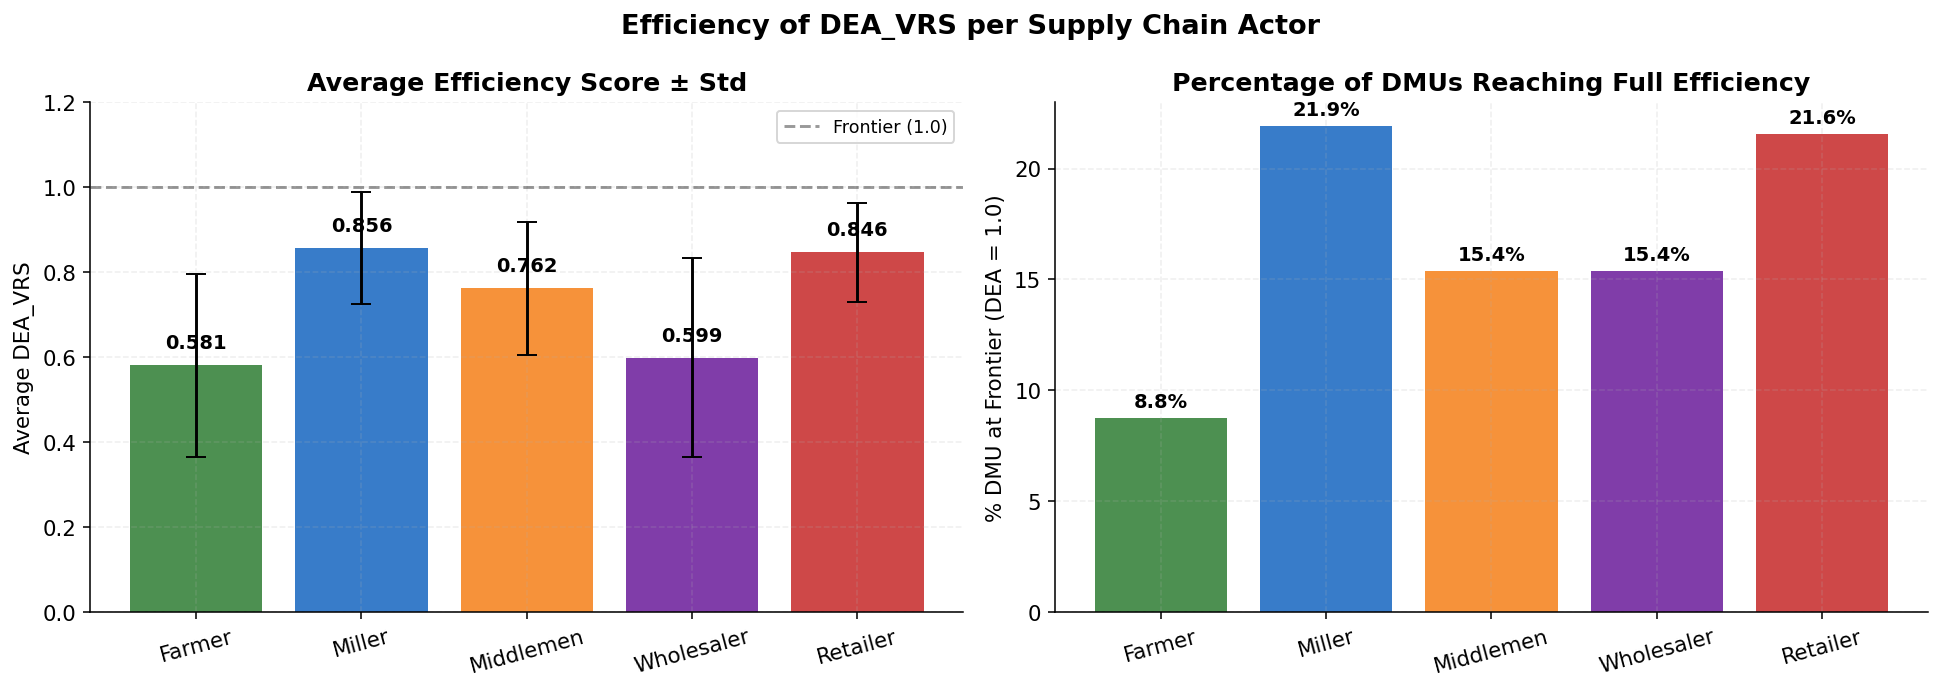

In [ ]:
actors_order = ['Farmer', 'Miller', 'Middlemen', 'Wholesaler', 'Retailer']
dfs = [df_farm, df_miller, df_middleman, df_wholesaler, df_retail]

dea_stats = pd.DataFrame({
    'Actor'      : actors_order,
    'mean'       : [d['DEA_VRS'].mean() for d in dfs],
    'std'        : [d['DEA_VRS'].std()  for d in dfs],
    'frontier_pct': [(d['DEA_VRS']>=0.999).mean()*100 for d in dfs],
    'n'          : [len(d) for d in dfs],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Efficiency of DEA_VRS per Supply Chain Actor', fontsize=14, fontweight='bold')

colors = [ACTOR_COLORS[a] for a in actors_order]
bars = axes[0].bar(actors_order, dea_stats['mean'],
                    color=colors, alpha=0.85,
                    yerr=dea_stats['std'], capsize=5)
axes[0].axhline(1.0, color='black', lw=1.5, ls='--', alpha=0.4, label='Frontier (1.0)')
axes[0].set_ylim(0, 1.2)
axes[0].set_ylabel('Average DEA_VRS')
axes[0].set_title('Average Efficiency Score ± Std')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=9)
for bar, row in zip(bars, dea_stats.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.04,
                 f'{row.mean:.3f}', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(actors_order, dea_stats['frontier_pct'],
                     color=colors, alpha=0.85)
axes[1].set_ylabel('% DMU at Frontier (DEA = 1.0)')
axes[1].set_title('Percentage of DMUs Reaching Full Efficiency')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, dea_stats['frontier_pct']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Millers top the list with an average DEA_VRS of 0.856 and 21.9% have reached the perfect frontier (score 1.0), indicating that rice mills are the most technically efficient nodes in the entire supply chain. Retailers (0.846) are in second place, surprisingly, as despite being technically efficient, they are the worst losers, proving that DEA efficiency does not equate to profitability. Farmers (0.580) and Wholesalers (0.599) are the two actors with the lowest scores, both still far from the frontier, indicating significant input waste that could be reduced without reducing output. This pattern confirms that the West Java rice supply chain is not homogeneous; each actor has different challenges that require different interventions.

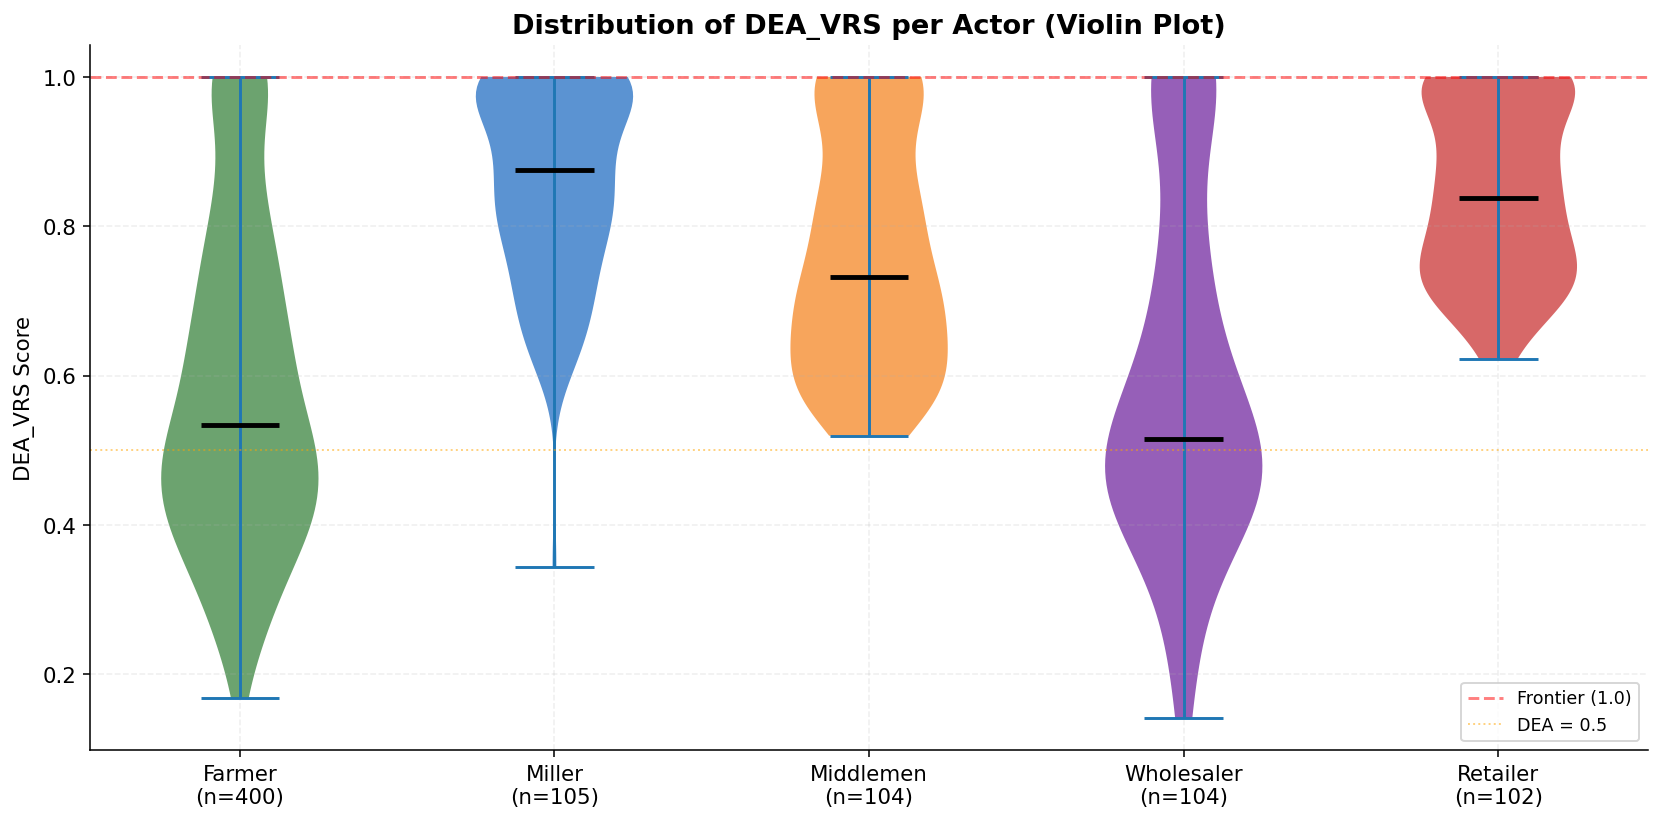

In [ ]:
all_dea = pd.concat([
    d[['Actor','DEA_VRS']] for d in dfs
], ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 6))
parts = ax.violinplot(
    [all_dea[all_dea['Actor']==a]['DEA_VRS'].values for a in actors_order],
    positions=range(len(actors_order)),
    showmedians=True, showextrema=True
)
for i, (pc, actor) in enumerate(zip(parts['bodies'], actors_order)):
    pc.set_facecolor(ACTOR_COLORS[actor])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2.5)

ax.set_xticks(range(len(actors_order)))
ax.set_xticklabels([f'{a}\n(n={len(d)})' for a,d in zip(actors_order,dfs)])
ax.axhline(1.0, color='red', lw=1.5, ls='--', alpha=0.5, label='Frontier (1.0)')
ax.axhline(0.5, color='orange', lw=1, ls=':', alpha=0.5, label='DEA = 0.5')
ax.set_ylabel('DEA_VRS Score')
ax.set_title('Distribution of DEA_VRS per Actor (Violin Plot)', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

The violin plot reveals very different distributions across actors. Farmers have the most dispersed distribution, with some being highly efficient (close to 1.0) and others being very poor (below 0.3), indicating a large capacity gap between farmers and requiring interventions to target the lower end. Millers and Retailers exhibit a more "top-heavy" distribution, with most DMUs clustered at high scores, bringing their averages close to 0.85, but with a lower tail that warrants attention. Wholesalers have the most even and low distribution, with many DMUs concentrated in the 0.4–0.8 range. There is no clear peak, indicating systemic capability inequities, not just a few poor outliers. Middlemen fall in the middle, with a weak bimodal distribution, with a small group being highly efficient and a large group stuck at moderate efficiency.

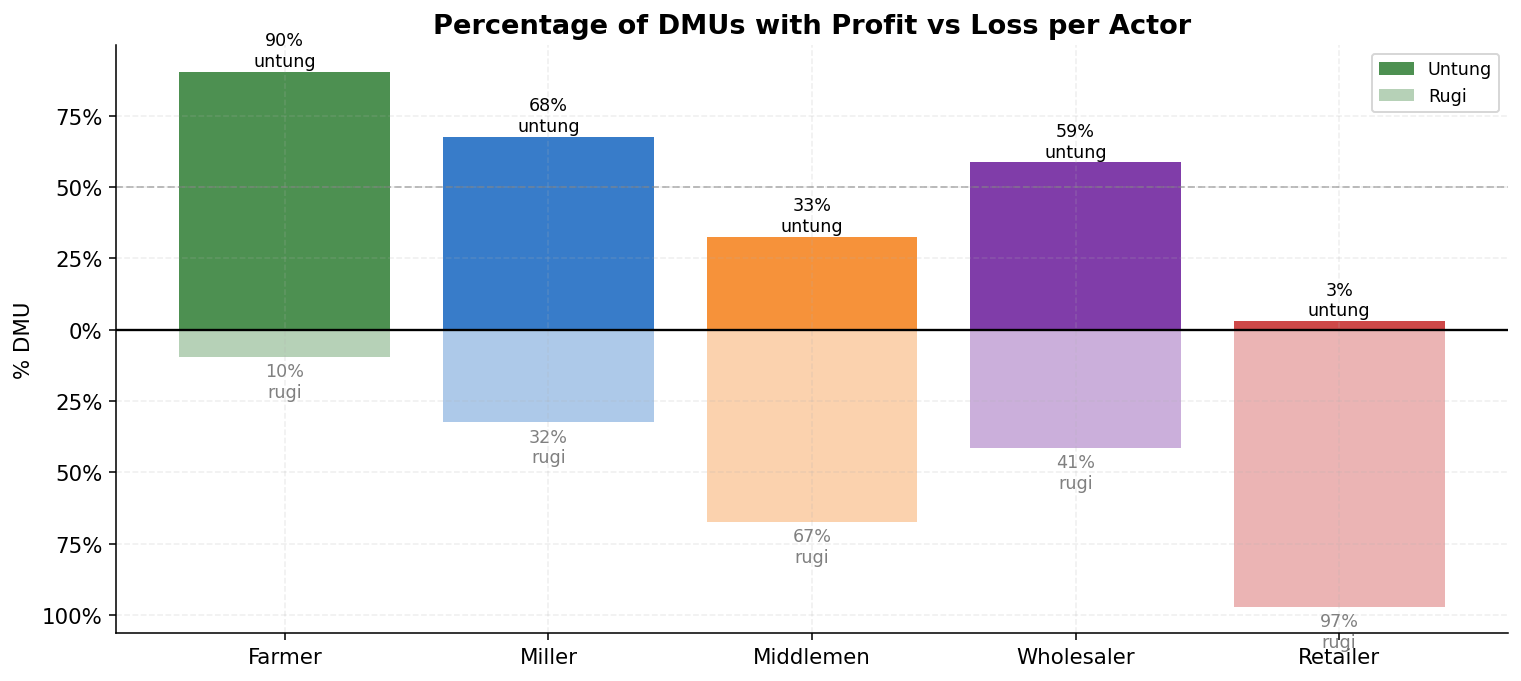

In [ ]:
profit_data = pd.DataFrame({
    'Actor'     : actors_order,
    'pct_profit': [(d['Profit']>0).mean()*100 for d in dfs],
    'pct_loss'  : [(d['Profit']<=0).mean()*100 for d in dfs],
})

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(actors_order))
bars_p = ax.bar(x, profit_data['pct_profit'],
                 color=[ACTOR_COLORS[a] for a in actors_order], alpha=0.85, label='Untung')
bars_l = ax.bar(x, -profit_data['pct_loss'],
                 color=[ACTOR_COLORS[a] for a in actors_order], alpha=0.35, label='Rugi')

ax.axhline(0, color='black', lw=1.2)
ax.axhline(50, color='gray', lw=1, ls='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(actors_order)
ax.set_ylabel('% DMU')
ax.set_title('Percentage of DMUs with Profit vs Loss per Actor', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(x):.0f}%'))

for bar, row in zip(bars_p, profit_data.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, row.pct_profit+2,
            f'{row.pct_profit:.0f}%\nuntung', ha='center', fontsize=9, color='black')
    ax.text(bar.get_x()+bar.get_width()/2, -row.pct_loss-2,
            f'{row.pct_loss:.0f}%\nrugi', ha='center', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

Farmers dominate profitability, with 90.5% of their operators profitable, making them the only player massively financially viable. Millers remain quite healthy, with 67.6% profitability, although their thin margins make them vulnerable to fluctuations in grain prices. Wholesalers are in the middle with 58.7% profitability, while the majority appear to be profitable, the highly uneven distribution (some are losing hundreds of billions) makes this figure misleading without a deeper look. Middlemen are only 32.7% profitable, meaning two out of three middlemen in West Java lose money every season a serious sign that the mid-level rice distribution business model is experiencing structural pressure. Retailers are the most extreme: only 2.9% are profitable, nearly all of whom lose money every day they open, not because of mismanagement but because of a cost-to-price structure that fundamentally precludes profit without external intervention.

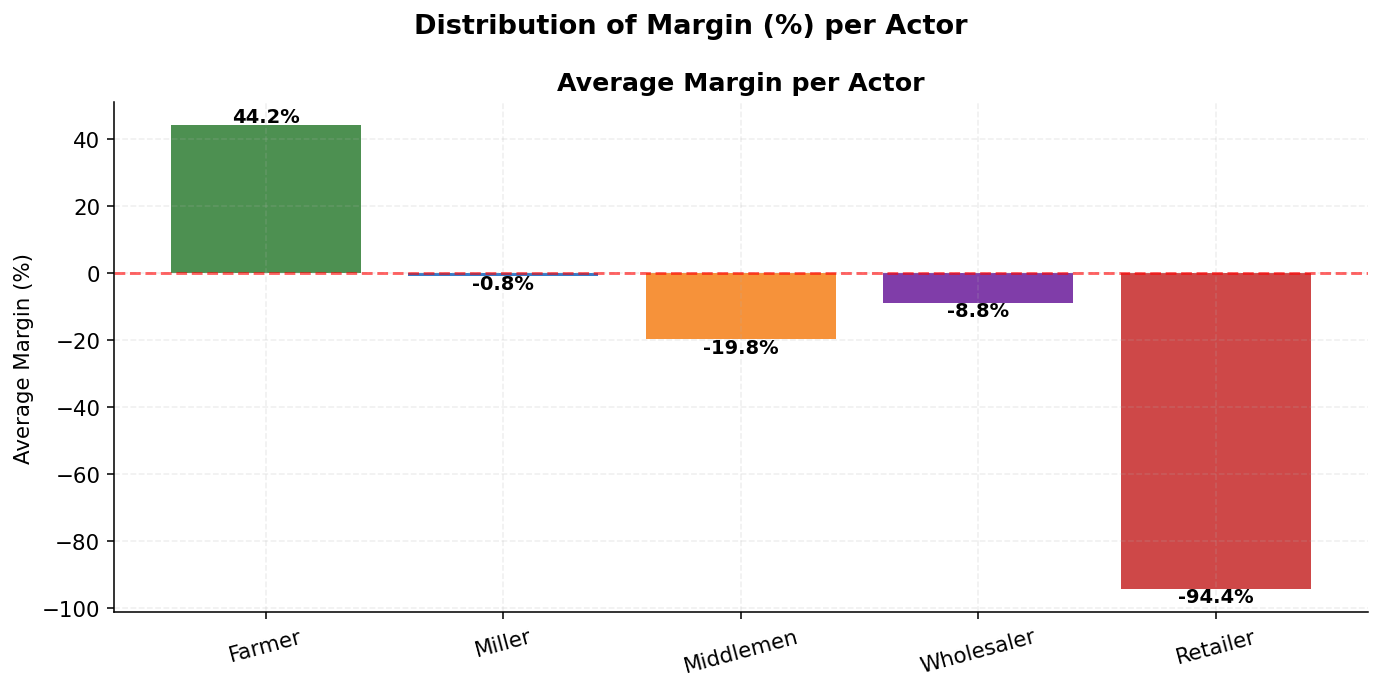

In [ ]:
fig, axes = plt.subplots(figsize=(10, 5))
fig.suptitle('Distribution of Margin (%) per Actor', fontsize=14, fontweight='bold')

# Bar: average margin per actor
avg_margins = [d['Margin (%)'].mean() for d in dfs]
bar_colors  = [ACTOR_COLORS[a] for a in actors_order]
bars = axes.bar(actors_order, avg_margins, color=bar_colors, alpha=0.85)
axes.axhline(0, color='red', lw=1.5, ls='--', alpha=0.6)
axes.set_ylabel('Average Margin (%)')
axes.set_title('Average Margin per Actor')
axes.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, avg_margins):
    ypos = bar.get_height() + 1 if val >= 0 else bar.get_height() - 4
    axes.text(bar.get_x()+bar.get_width()/2, ypos,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Some large millers with many machines can have very high margins, while small millers with a single machine can have very negative margins, averaging -0.8%, reflecting this delicate balance. Middlemen and wholesalers both have negative medians with long lower tailsone DMU has a margin as high as -176% (losses nearly double its revenue), suggesting certain, highly destructive operating conditions. Retailers are at the extreme end: almost the entire distribution is below zero, with a median of around -97%. There is very little variation between retailers (all losses are in a similar range) this is not an outlier, but rather the normal condition of rice retailers in West Java.

#### **Data Insight**

Overall, the West Java rice supply chain shows a worrying pattern: only two of the five actors are predominantly profitable: Farmers (90.5% profit, +44% margin) and Wholesalers (58.7% profit), while the other three are structurally loss-making. Millers are at a delicate balance with a -0.8% margin and 67.6% profit, but Middlemen are already losing an average of -19.8% with only 32.7% profit, and Retailers are the worst-off actors, with 97.1% loss and an average margin of -94.4%. In terms of DEA_VRS efficiency, Millers are the most efficient actor (0.856) followed by Retailers (0.846), which seems paradoxical since Retailers are almost entirely loss-making this illustrates that DEA technical efficiency is not synonymous with profitability: Retailers are efficient in utilizing their inputs, but their business scale and cost structure are fundamentally unviable. The wholesaler is the actor with the lowest DEA efficiency (0.599), making it the largest technical bottleneck in this supply chain.

### **Explore Value Chain**

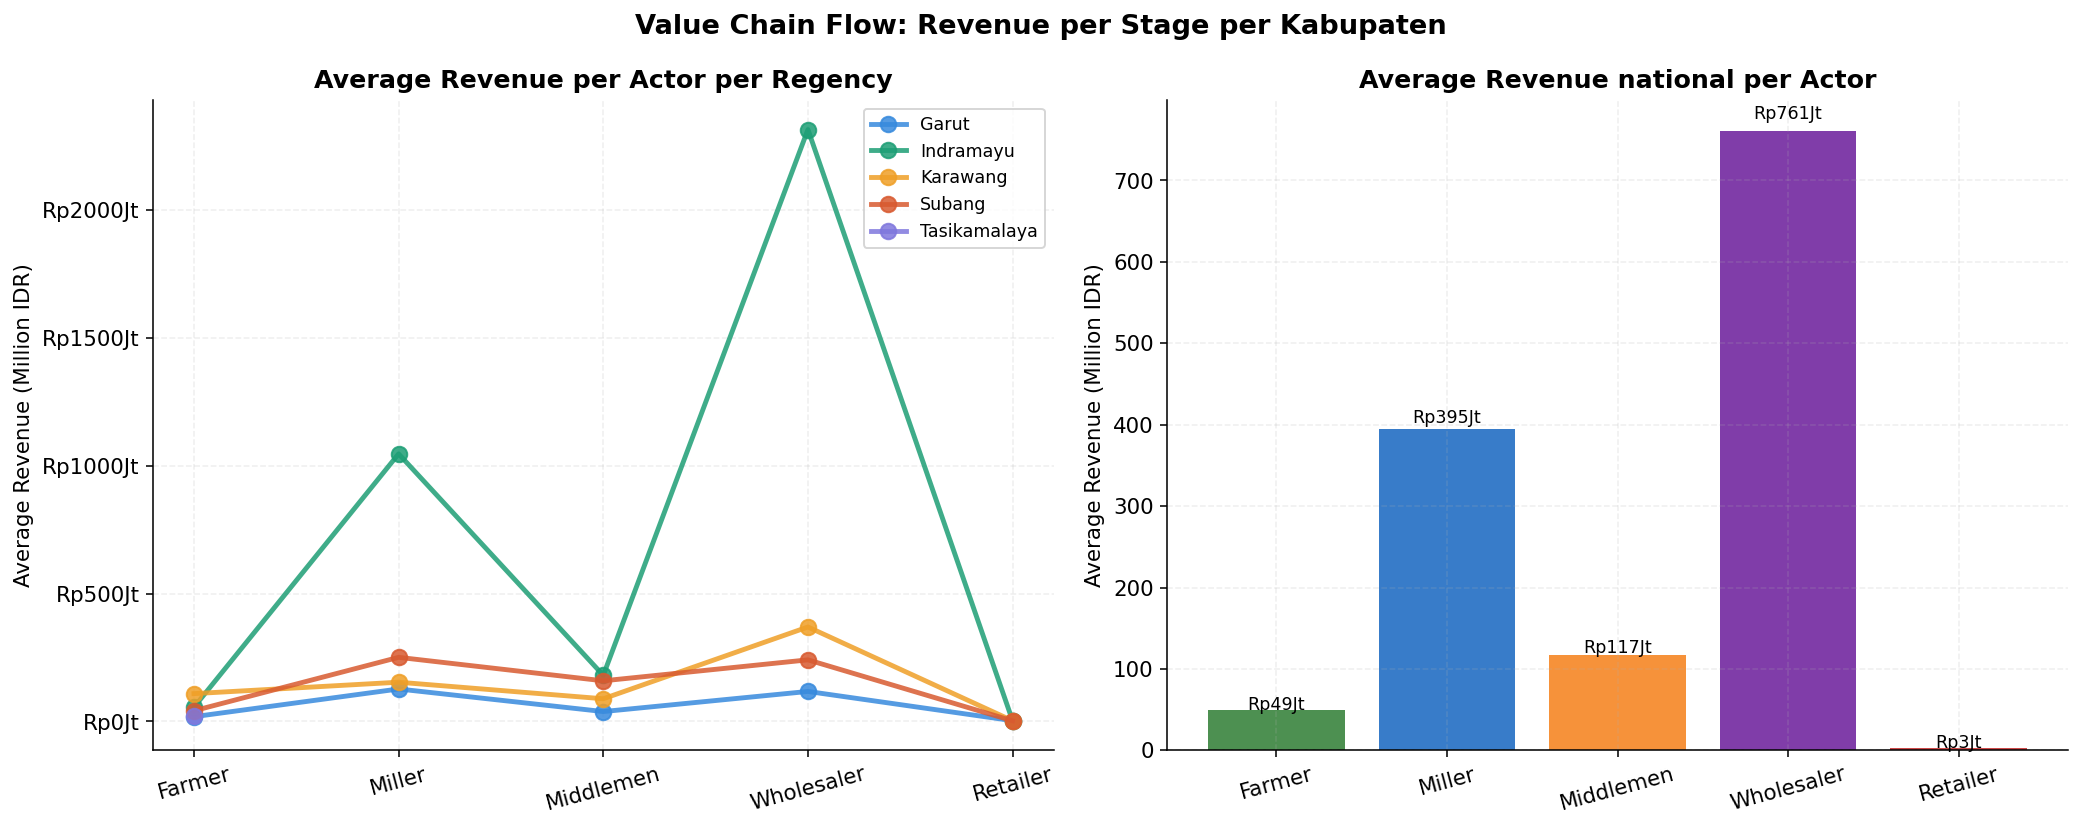

In [ ]:
vc_data = {}
for kab in KABUPATEN:
    f_rev = df_farm[df_farm['Kabupaten']==kab]['Production value (IDR)'].mean()
    # Miller: nilaiberashasilgiling
    m_rev = df_miller[df_miller['Kabupaten']==kab]['nilaiberashasilgiling'].mean() if kab in df_miller['Kabupaten'].values else np.nan
    mid_rev = df_middleman[df_middleman['Kabupaten']==kab]['Value of rice sold (IDR)'].mean() if kab in df_middleman['Kabupaten'].values else np.nan
    w_rev   = df_wholesaler[df_wholesaler['Kabupaten']==kab]['Value of rice sold (IDR)'].mean() if kab in df_wholesaler['Kabupaten'].values else np.nan
    r_rev   = df_retail[df_retail['Kabupaten']==kab]['Value of rice sold (IDR)'].mean() if kab in df_retail['Kabupaten'].values else np.nan
    vc_data[kab] = [f_rev, m_rev, mid_rev, w_rev, r_rev]

df_vc = pd.DataFrame(vc_data, index=actors_order).T

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Value Chain Flow: Revenue per Stage per Kabupaten', fontsize=14, fontweight='bold')

# Line chart per kabupaten
for kab in KABUPATEN:
    vals = df_vc.loc[kab].values / 1e6
    axes[0].plot(actors_order, vals, marker='o', lw=2.5, markersize=8,
                  color=KAB_COLORS[kab], label=kab, alpha=0.85)
axes[0].set_ylabel('Average Revenue (Million IDR)')
axes[0].set_title('Average Revenue per Actor per Regency')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp{x:.0f}Jt'))

# Stacked bar: rata-rata revenue semua kabupaten
avg_rev = [df_vc[a].mean()/1e6 for a in actors_order]
bar_clrs = [ACTOR_COLORS[a] for a in actors_order]
bars = axes[1].bar(actors_order, avg_rev, color=bar_clrs, alpha=0.85)
axes[1].set_ylabel('Average Revenue (Million IDR)')
axes[1].set_title('Average Revenue national per Actor')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, avg_rev):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                 f'Rp{val:.0f}Jt', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

The revenue flow along the supply chain exhibits a non-linear pattern and varies significantly across districts. At the Farmer level, revenue per DMU is relatively small (Rp 41.3 million national average), with Subang and Karawang tending to be more productive due to their larger land areas. The largest jump occurs at the Wholesaler level, where revenues can reach hundreds of millions to billions per DMU. However, this reflects large transaction volumes rather than real value creation their margins remain negative. Karawang and Subang consistently show higher revenues at almost all actor levels, while Garut and Tasikamalaya show lower ones likely because Karawang and Subang are West Java's rice production centers with better distribution infrastructure. Of particular note is the "gap" between Miller and Middlemen's revenues—rice prices rise significantly in the hands of middlemen without any clear value creation. This is a potential area of ​​efficiency that could be reduced with a digital platform that directly connects millers to wholesalers.

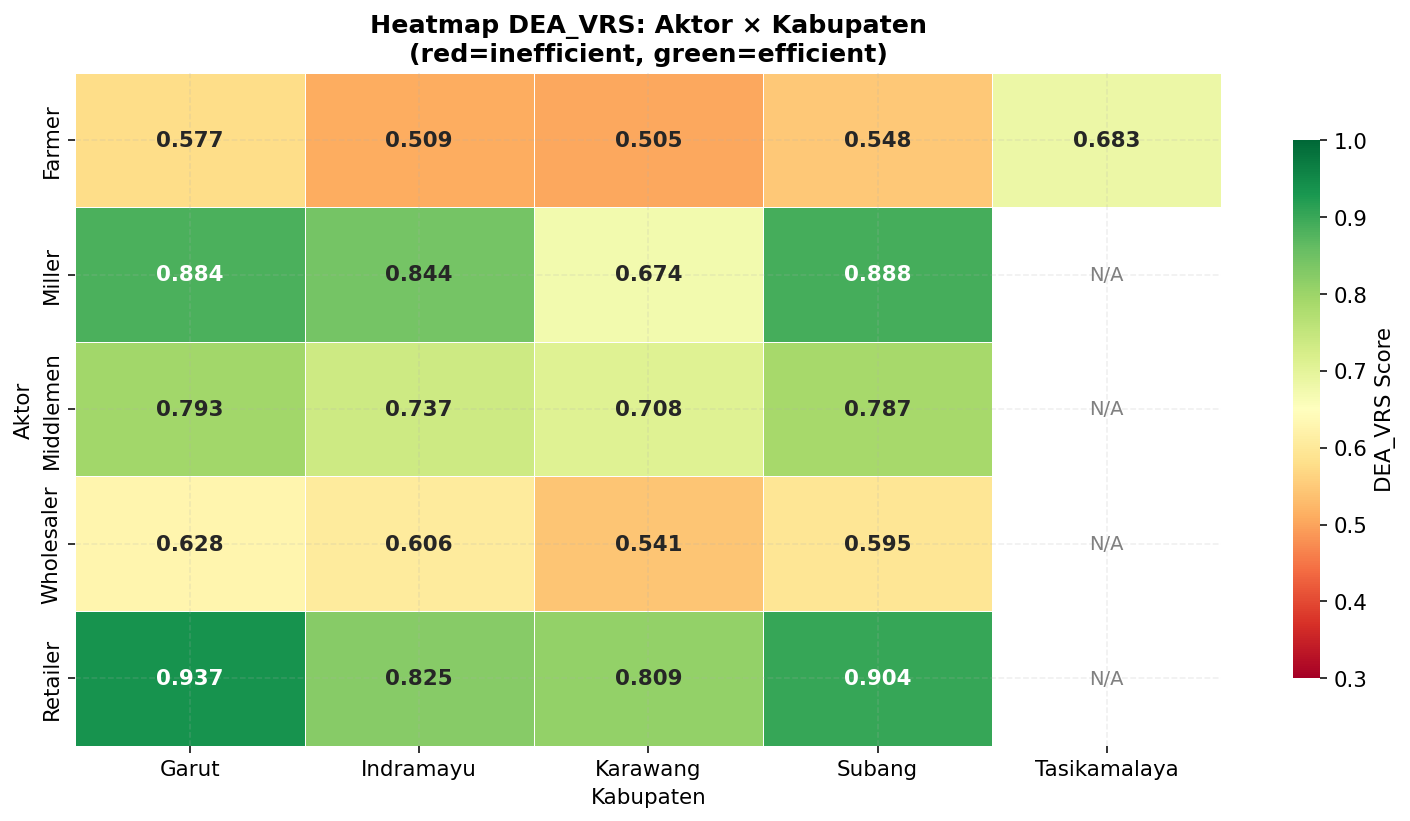

In [ ]:
dea_matrix = pd.DataFrame(index=actors_order, columns=KABUPATEN, dtype=float)
for actor, df in zip(actors_order, dfs):
    for kab in KABUPATEN:
        sub = df[df['Kabupaten']==kab]
        dea_matrix.loc[actor, kab] = sub['DEA_VRS'].mean() if len(sub)>0 else np.nan

fig, ax = plt.subplots(figsize=(11, 6))
mask = dea_matrix.isna()
sns.heatmap(dea_matrix.astype(float), annot=True, fmt='.3f',
             cmap='RdYlGn', vmin=0.3, vmax=1.0,
             linewidths=0.5, ax=ax, mask=mask,
             cbar_kws={'label': 'DEA_VRS Score', 'shrink': 0.8},
             annot_kws={'size': 11, 'weight': 'bold'})

# Nilai NaN
for i, actor in enumerate(actors_order):
    for j, kab in enumerate(KABUPATEN):
        if pd.isna(dea_matrix.loc[actor, kab]):
            ax.text(j+0.5, i+0.5, 'N/A', ha='center', va='center',
                    fontsize=10, color='gray')

ax.set_title('Heatmap DEA_VRS: Aktor × Kabupaten\n(red=inefficient, green=efficient)',
              fontsize=13, fontweight='bold')
ax.set_xlabel('Kabupaten')
ax.set_ylabel('Aktor')
plt.tight_layout()
plt.show()

This heatmap is the most informative bottleneck map in the entire analysis. The red (low efficiency) color is concentrated in the Wholesaler row in almost all districts, confirming Wholesaler as the most geographically consistent technical bottleneck. Karawang stands out as a problematic district across multiple actors Farmer Karawang DEA 0.504 (lowest), Middlemen Karawang is quite low, and Wholesaler Karawang is also weak indicating a structural problem in Karawang's agricultural ecosystem that extends beyond a single actor. Tasikamalaya shows an interesting pattern: its Farmers are the most efficient (0.683) but its Middlemen are relatively weak (yellow-orange areas), as if efficiency at the production level is not connected to distribution efficiency. The greenest (efficient) cells are concentrated in Miller in almost all districts these should be anchors or hubs in a supply chain digitalization strategy as they are the most stable and efficient nodes.

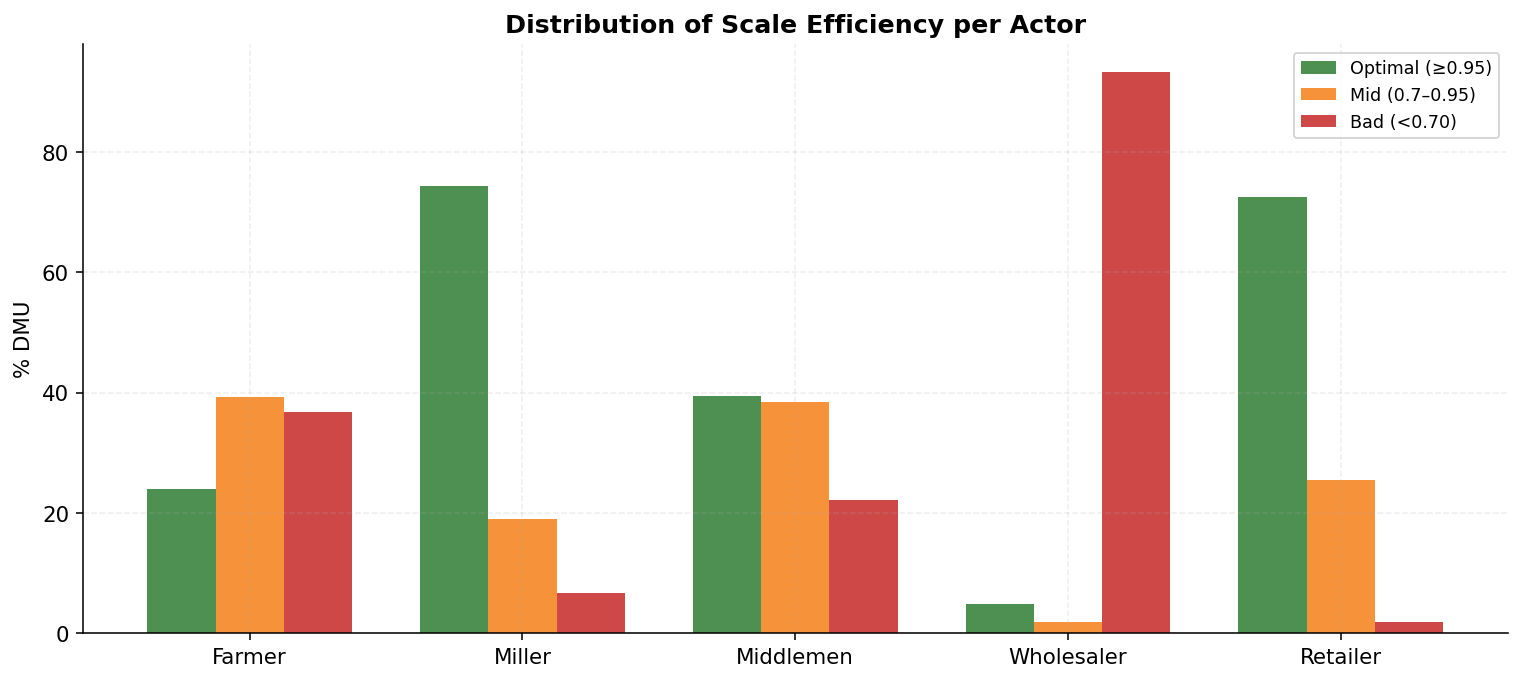

In [ ]:
scale_cats = pd.DataFrame({
    'Actor'   : actors_order,
    'Optimal' : [(d['Scale_Efficiency']>=0.95).mean()*100 for d in dfs],
    'Mid'  : [((d['Scale_Efficiency']>=0.7)&(d['Scale_Efficiency']<0.95)).mean()*100 for d in dfs],
    'Bad'   : [(d['Scale_Efficiency']<0.7).mean()*100 for d in dfs],
})

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(actors_order))
w = 0.25

ax.bar(x-w, scale_cats['Optimal'], w, label='Optimal (≥0.95)', color='#2E7D32', alpha=0.85)
ax.bar(x,   scale_cats['Mid'],  w, label='Mid (0.7–0.95)', color='#F57F17', alpha=0.85)
ax.bar(x+w, scale_cats['Bad'],   w, label='Bad (<0.70)', color='#C62828', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(actors_order)
ax.set_ylabel('% DMU')
ax.set_title('Distribution of Scale Efficiency per Actor', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Wholesalers are the actors with the worst Scale_Efficiency only 4.8% are scale-optimal (≥0.95), meaning 95.2% of the 104 wholesalers operate at the wrong scale, either too small or too large compared to the optimal point. This explains why Wholesalers have the lowest DEA even before cost allocation, their business scale is already unfavorable. Millers, on the other hand, are the best with 74.3% scale optimal, supported by data showing that millers with more machines consistently achieve better scale efficiency. Farmers are in the middle, with some already scale-optimal (sufficiently large land, proportional inputs) but many are scale, poor because the land is too small, resulting in high overhead per unit of output. Retailers, whose business scale is very homogeneous (CV only 19%), have 72.5% scale optimal they all operate at more or less the same scale, and for most, that scale is proportional the problem is not scale but cost structure, especially the dominance of Labor.

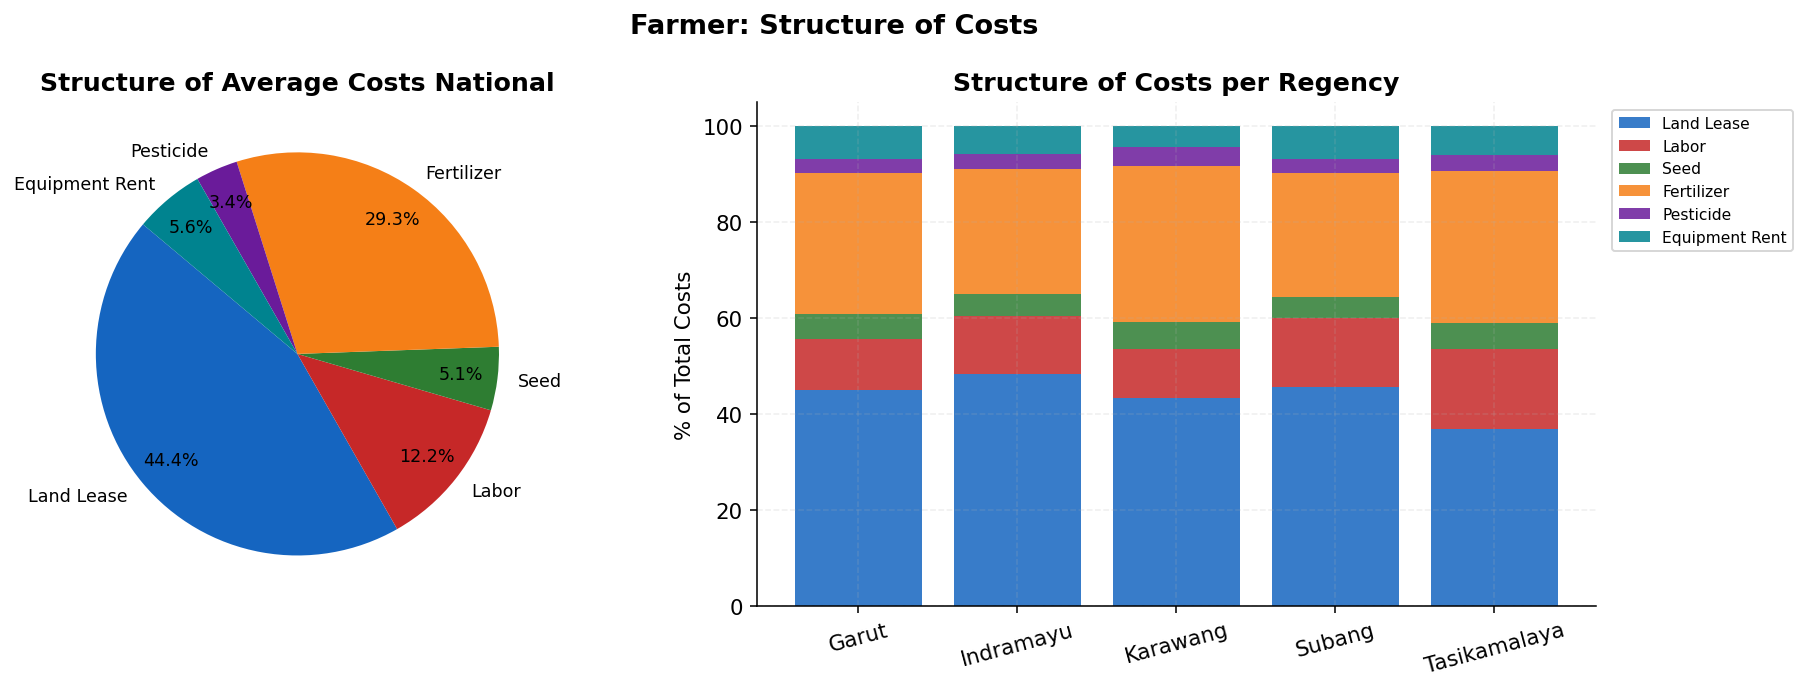

In [ ]:
cost_cols_farm = {
    'Land Lease': 'Land lease value (IDR)',
    'Labor': 'Labor cost (IDR)',
    'Seed': 'Seed purchase value (IDR)',
    'Fertilizer': 'Fertilizer purchase value (IDR)',
    'Pesticide': 'Pesticide purchase value (IDR)',
    'Equipment Rent': 'Equipment rent value (IDR)',
}
farm_cost_means = {k: df_farm[v].mean() for k,v in cost_cols_farm.items()}
cost_colors = ['#1565C0','#C62828','#2E7D32','#F57F17','#6A1B9A','#00838F']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Farmer: Structure of Costs', fontsize=14, fontweight='bold')

wedges, texts, pcts = axes[0].pie(
    farm_cost_means.values(), labels=farm_cost_means.keys(),
    autopct='%1.1f%%', colors=cost_colors,
    startangle=140, pctdistance=0.82
)
for t in texts+pcts: t.set_fontsize(9)
axes[0].set_title('Structure of Average Costs National')

# Per kabupaten
kab_cost = df_farm.groupby('Kabupaten')[
    list(cost_cols_farm.values())].mean().div(
    df_farm.groupby('Kabupaten')['Total Cost'].mean(), axis=0) * 100
kab_cost.columns = list(cost_cols_farm.keys())

bottom = np.zeros(len(kab_cost))
for col, clr in zip(cost_cols_farm.keys(), cost_colors):
    axes[1].bar(kab_cost.index, kab_cost[col], bottom=bottom,
                 color=clr, alpha=0.85, label=col)
    bottom += kab_cost[col].values

axes[1].set_ylabel('% of Total Costs')
axes[1].set_title('Structure of Costs per Regency')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

Fertilizer dominates farmer expenditures at 40.1% of total costs, nearly double the second-largest component, land rent (27.5%) this is the biggest leverage point because any efficiency in fertilizer spending directly impacts the bottom line. Labor (14.0%), seed (5.8%), equipment (6.3%), and pesticides (3.8%) are each relatively small but still significant when added together (29.9%). This cost structure pattern is fairly consistent across districts, although there is some variation Karawang and Subang tend to allocate more to land rent (land is more expensive in production centers), while Garut and Tasikamalaya allocate slightly more to fertilizer. The practical implication: a data-driven fertilizer dosage recommendation platform (soil sensors, weather, varieties) is the digital intervention with the highest ROI for West Java farmers because it directly targets the largest cost component that is heavily influenced by technical agronomic decisions, not just market conditions.

C:\Users\Tuf Gaming\AppData\Local\Temp\ipykernel_2680\3949503765.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_kab, labels=kab_in_farm, patch_artist=True,


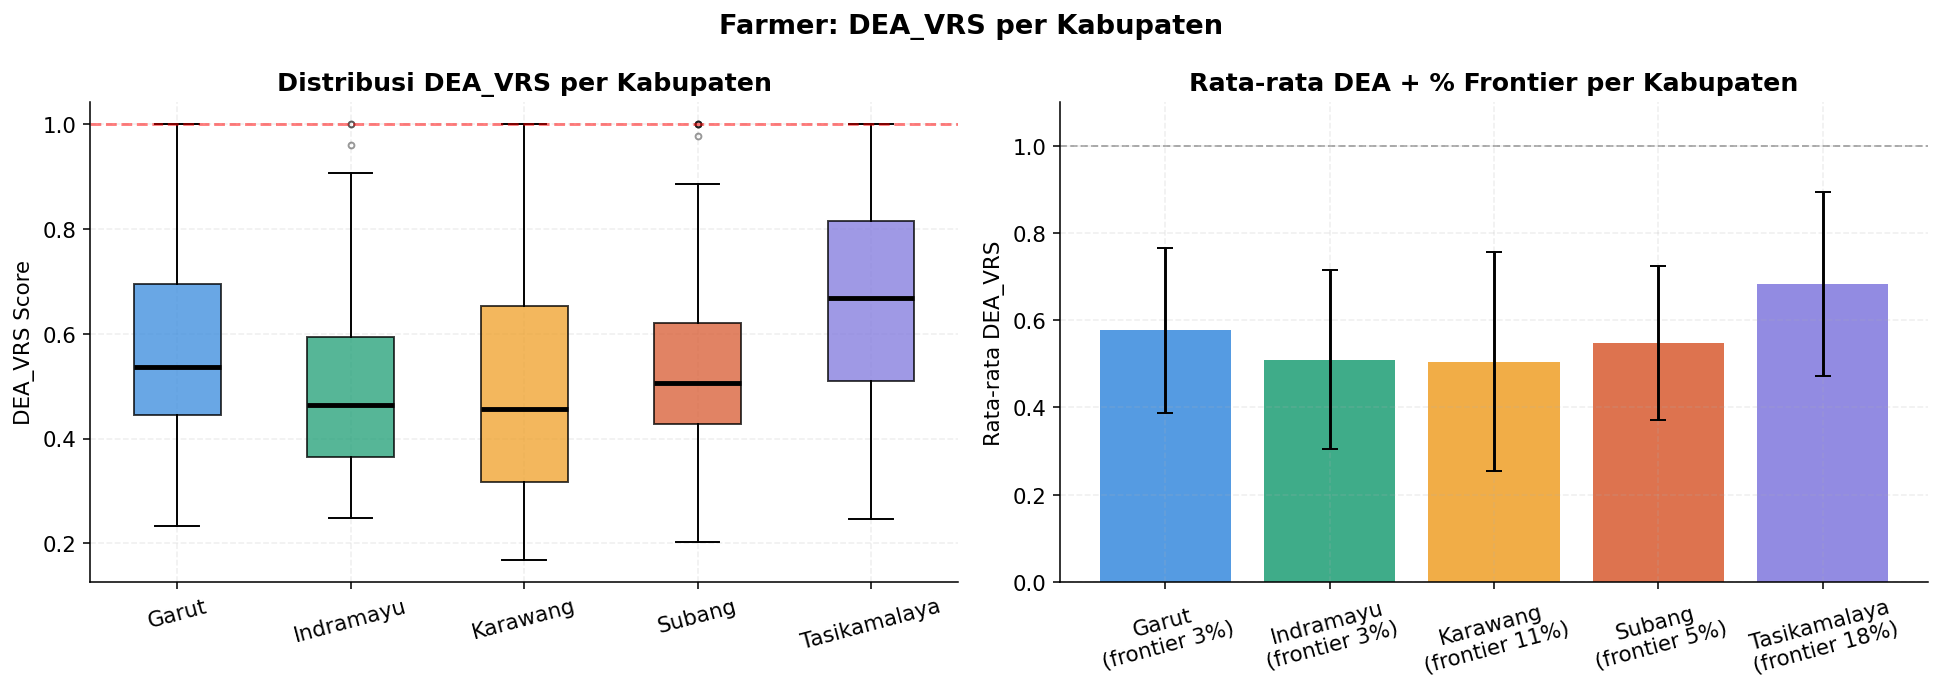

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Farmer: DEA_VRS per Kabupaten', fontsize=14, fontweight='bold')

kab_in_farm = [k for k in KABUPATEN if k in df_farm['Kabupaten'].values]
data_kab = [df_farm[df_farm['Kabupaten']==k]['DEA_VRS'].values for k in kab_in_farm]
bp = axes[0].boxplot(data_kab, labels=kab_in_farm, patch_artist=True,
                      medianprops=dict(color='black', lw=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, kab in zip(bp['boxes'], kab_in_farm):
    patch.set_facecolor(KAB_COLORS[kab]); patch.set_alpha(0.75)
axes[0].axhline(1.0, color='red', lw=1.5, ls='--', alpha=0.5)
axes[0].set_ylabel('DEA_VRS Score')
axes[0].set_title('Distribusi DEA_VRS per Kabupaten')
axes[0].tick_params(axis='x', rotation=15)

kab_dea = df_farm.groupby('Kabupaten')['DEA_VRS'].agg(['mean','std'])
kab_front = (df_farm.groupby('Kabupaten')['DEA_VRS'].apply(lambda x: (x>=0.999).mean()*100))

x2 = np.arange(len(kab_in_farm))
axes[1].bar(x2, [kab_dea.loc[k,'mean'] for k in kab_in_farm],
             color=[KAB_COLORS[k] for k in kab_in_farm], alpha=0.85,
             yerr=[kab_dea.loc[k,'std'] for k in kab_in_farm], capsize=4)
axes[1].set_xticks(x2)
axes[1].set_xticklabels([f'{k}\n(frontier {kab_front[k]:.0f}%)' for k in kab_in_farm], rotation=15)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Rata-rata DEA_VRS')
axes[1].set_title('Rata-rata DEA + % Frontier per Kabupaten')
axes[1].axhline(1.0, color='black', lw=1, ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

Tasikamalaya is far and away the most efficient district (DEA 0.683) compared to Garut (0.577), Subang (0.547), Indramayu (0.509), and Karawang (0.504) the gap between Tasikamalaya and Karawang is 0.179 points, large enough to make a noticeable difference in the amount of input wasted. Interestingly, Tasikamalaya and Indramayu have a more “concentrated” DEA distribution (smaller std), meaning that farmers there are more homogeneous in their abilities the good and bad are relatively evenly distributed. Meanwhile, Garut and Karawang have a more dispersed distribution some farmers are very efficient and some are very poor, indicating that some “best practices” are not yet evenly distributed. Karawang, the national “rice granary,” actually has the lowest DEA a paradox likely caused by overinvestment in inputs (excessive fertilizer, expensive land rents in production centers) without a proportional increase in output, something that can be remedied with data-driven precision farming.

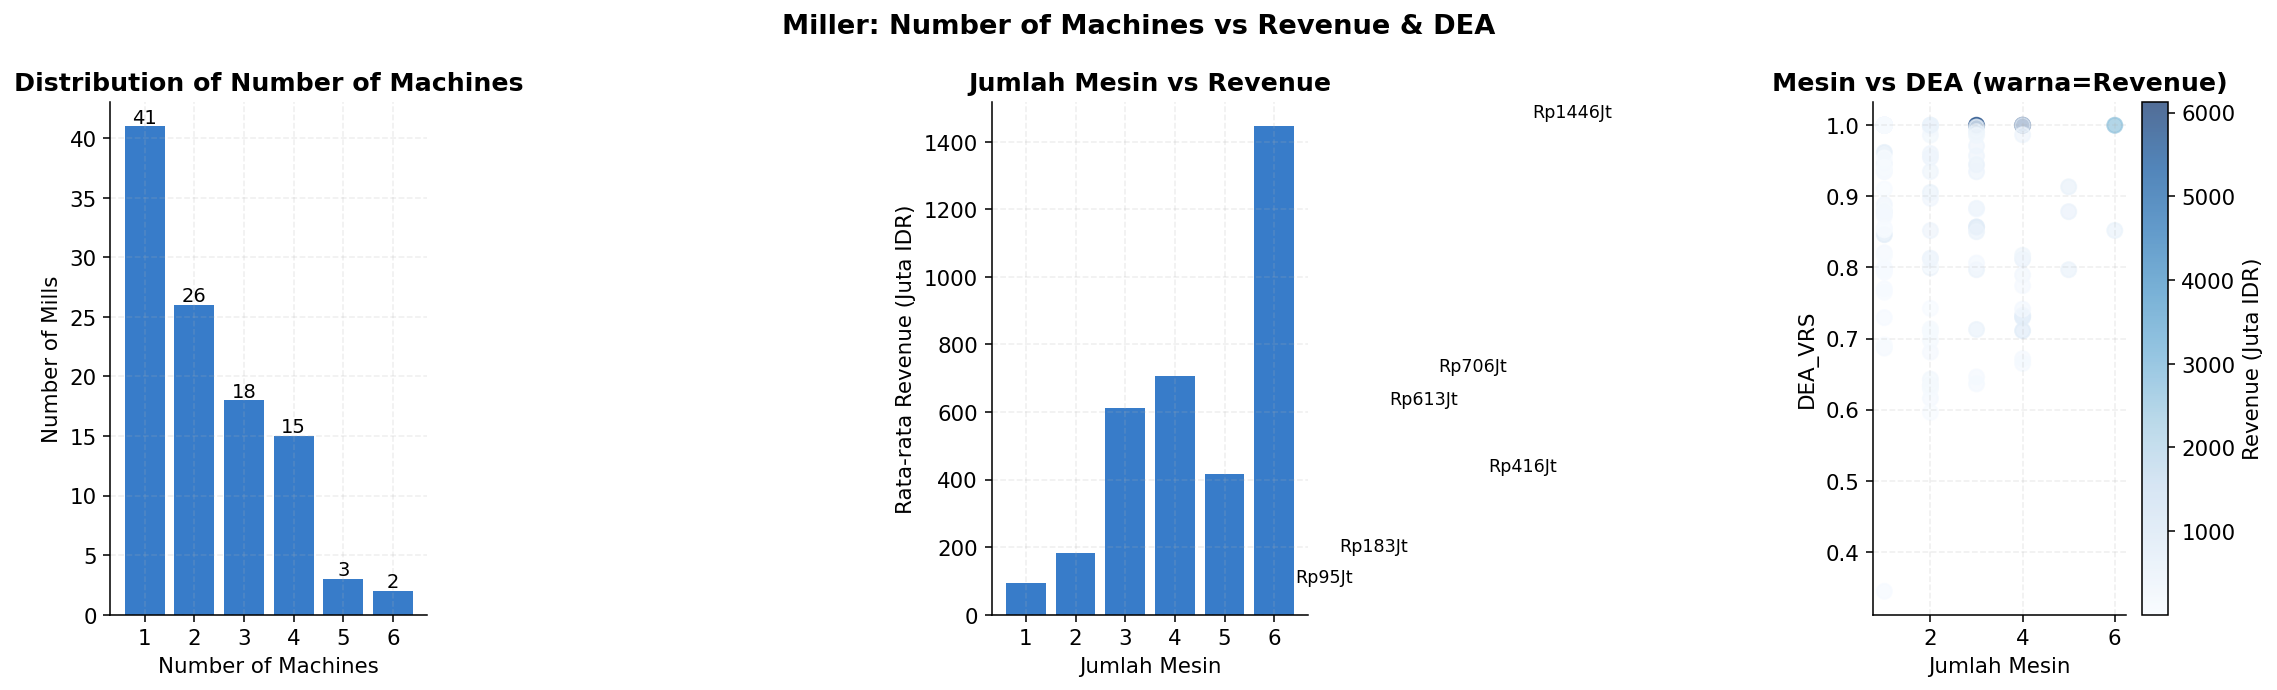

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Miller: Number of Machines vs Revenue & DEA', fontsize=14, fontweight='bold')

mesin_counts = df_miller['Number of machines (unit)'].value_counts().sort_index()
axes[0].bar(mesin_counts.index.astype(str), mesin_counts.values,
             color='#1565C0', alpha=0.85)
axes[0].set_xlabel('Number of Machines')
axes[0].set_ylabel('Number of Mills')
axes[0].set_title('Distribution of Number of Machines')
for i, (k,v) in enumerate(mesin_counts.items()):
    axes[0].text(i, v+0.3, str(v), ha='center', fontsize=10)

mill_grp = df_miller.groupby('Number of machines (unit)').agg(
    rev_mean=('Revenue', 'mean'),
    dea_mean=('DEA_VRS', 'mean'),
    n=('dmu', 'count')
).reset_index()

axes[1].bar(mill_grp['Number of machines (unit)'].astype(str),
             mill_grp['rev_mean']/1e6, color='#1565C0', alpha=0.85)
axes[1].set_xlabel('Jumlah Mesin')
axes[1].set_ylabel('Rata-rata Revenue (Juta IDR)')
axes[1].set_title('Jumlah Mesin vs Revenue')
for _, row in mill_grp.iterrows():
    axes[1].text(str(row['Number of machines (unit)']), row['rev_mean']/1e6*1.02,
                  f"Rp{row['rev_mean']/1e6:.0f}Jt", ha='center', fontsize=9)

sc2 = axes[2].scatter(df_miller['Number of machines (unit)'],
                       df_miller['DEA_VRS'],
                       c=df_miller['Revenue']/1e6, cmap='Blues',
                       alpha=0.7, s=60)
plt.colorbar(sc2, ax=axes[2], label='Revenue (Juta IDR)')
axes[2].set_xlabel('Jumlah Mesin')
axes[2].set_ylabel('DEA_VRS')
axes[2].set_title('Mesin vs DEA (warna=Revenue)')

plt.tight_layout()
plt.show()

Economies of scale di penggilingan padi sangat jelas terbukti: miller dengan 1 mesin rata-rata revenue Rp94.9 juta, sementara yang 6 mesin mencapai Rp1.45 miliar kenaikan 15.3 kali lipat hanya dengan menambah 5 mesin. Namun hubungan antara jumlah mesin dan DEA tidak linear miller 1 mesin justru memiliki DEA 0.891, lebih efisien dari yang 2 mesin (0.808) dan 4 mesin (0.811). Ini kemungkinan karena miller 1 mesin yang bertahan dan profitable adalah yang sudah benar-benar teroptimasi (yang tidak efisien sudah gulung tikar), sementara miller yang baru ekspansi ke 2-3 mesin sedang dalam fase transisi di mana fixed cost sudah naik tapi kapasitas belum terisi penuh. Miller 6 mesin memiliki DEA tertinggi (0.926) karena pada skala sangat besar, utilisasi mesin bisa dimaksimalkan dan biaya per unit turun drastis. Implication: ada "valley of death" di 2-4 mesin di mana miller sudah terlalu besar untuk beroperasi lean tapi belum cukup besar untuk economies of scale penuh.

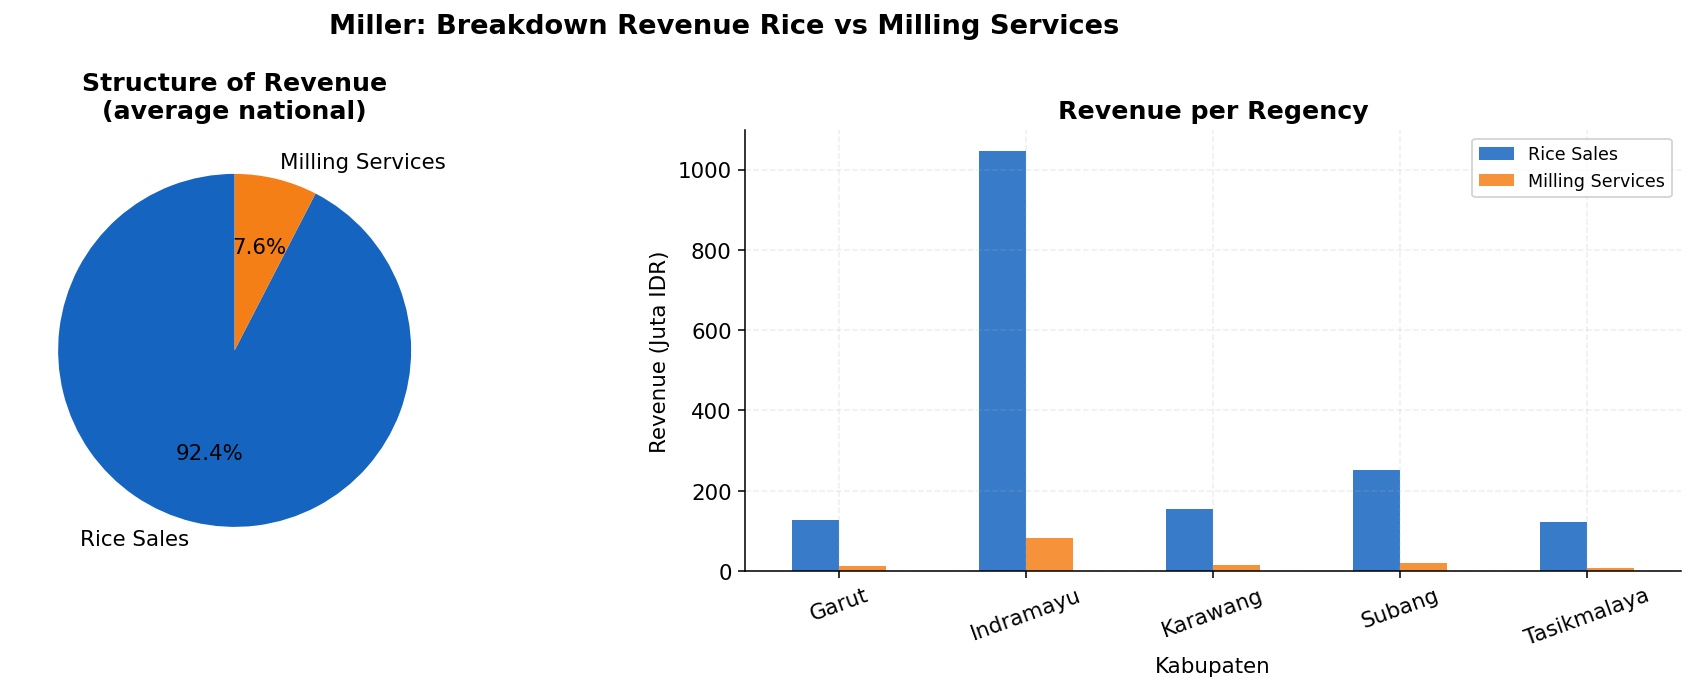

In [ ]:
df_miller['rev_beras']  = df_miller['nilaiberashasilgiling']
df_miller['rev_mesin']  = df_miller['Total revenue of milling machine (IDR)']
df_miller['rev_mix_pct']= df_miller['rev_mesin'] / df_miller['Revenue'].clip(lower=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Miller: Breakdown Revenue Rice vs Milling Services', fontsize=14, fontweight='bold')

axes[0].pie([df_miller['rev_beras'].mean(), df_miller['rev_mesin'].mean()],
             labels=['Rice Sales', 'Milling Services'],
             autopct='%1.1f%%', colors=['#1565C0','#F57F17'],
             startangle=90)
axes[0].set_title('Structure of Revenue\n(average national)')

kab_mill = df_miller.groupby('Kabupaten')[['rev_beras','rev_mesin']].mean()/1e6
kab_mill.plot(kind='bar', ax=axes[1], color=['#1565C0','#F57F17'], alpha=0.85, rot=20)
axes[1].set_ylabel('Revenue (Juta IDR)')
axes[1].set_title('Revenue per Regency')
axes[1].legend(['Rice Sales','Milling Services'], fontsize=9)


plt.tight_layout()
plt.show()

Milling revenue is heavily dominated by rice sales (92.4%) compared to machine milling services (7.6%), meaning miller profitability is almost entirely determined by the spread between the purchase price of unhusked rice and the selling price of rice a very thin margin and vulnerable to commodity price fluctuations. Diversification into milling services actually offers more stable revenue (service rates are more predictable than rice prices), but its contribution is currently very small. By district, Subang and Karawang dominate rice sales revenue due to their high-volume production centers, while Tasikamalaya relies more proportionally on milling services. The correlation between revenue mix (% ​​from milling services) and DEA_VRS is moderately positive, indicating that millers with more diversified revenue tend to be slightly more efficient likely due to higher machine utilization when not relying solely on a single source of income.

#### **Data Insight**

The value flow along the supply chain shows a disproportionate surge and an unequal distribution of added value. The average farmer's revenue is only IDR 41.3 million per DMU, ​​increasing significantly at the Wholesaler level, reaching hundreds of millions to billions of rupiah but this increase is not accompanied by an increase in margins because the cost of purchasing rice dominates the total cost. Most worrying is the "margin cliff" that occurs at the Retailer level: although the revenue is around IDR 2.92 million per DMU, ​​the total cost reaches IDR 5.52 million meaning each retailer transaction results in an average net loss of IDR 2.6 million. The margin waterfall from Farmer (+44%) → Miller (-0.8%) → Middlemen (-19.8%) → Wholesaler (-8.8%) → Retailer (-94.4%) illustrates a consistent degradation of financial health along the distribution chain, with Retailers bearing the brunt of the accumulative inefficiencies throughout the chain.

## **1. FARMER**

### **Short Analysis**

In [ ]:
df_farm.describe().T

,count,mean,std,min,25%,50%,75%,max
dmu,400.0,4.335750e+01,2.759826e+01,1.000000e+00,2.075000e+01,4.050000e+01,6.200000e+01,1.100000e+02
Land area (m2),400.0,4.529762e+03,5.386991e+03,1.000000e+02,1.200000e+03,2.220000e+03,6.000000e+03,3.000000e+04
Land lease value (IDR),400.0,8.914214e+06,1.683342e+07,1.000000e+05,2.000000e+06,4.012500e+06,1.200000e+07,2.550000e+08
Labor cost (IDR),400.0,2.461494e+06,3.485303e+06,5.500000e+04,5.000000e+05,9.800000e+05,3.225000e+06,3.200000e+07
Seed purchase value (IDR),400.0,1.021360e+06,1.231584e+06,2.300000e+04,2.760000e+05,5.000000e+05,1.380000e+06,6.900000e+06
Fertilizer purchase value (IDR),400.0,5.890721e+06,6.986652e+06,1.300000e+05,1.560000e+06,2.918500e+06,7.800000e+06,3.900000e+07
Pesticide purchase value (IDR),400.0,6.814506e+05,9.013900e+05,1.300000e+04,1.628900e+05,2.961800e+05,9.100000e+05,5.040000e+06
Equipment rent value (IDR),400.0,1.130256e+06,1.255069e+06,1.270000e+05,3.845500e+05,6.550000e+05,1.300000e+06,7.500009e+06
Production value (IDR),400.0,4.132181e+07,4.803755e+07,1.620000e+06,1.127500e+07,2.452500e+07,5.140000e+07,2.673000e+08
Total Cost,400.0,2.009950e+07,2.612433e+07,5.710000e+05,5.978200e+06,9.711400e+06,2.845000e+07,2.958200e+08


In [ ]:
print('PROFITABILITAS FARMER PER KABUPATEN:')
eda = df_farm.groupby('Kabupaten').agg(
    n               = ('dmu',        'count'),
    pct_untung      = ('Profit',      lambda x: f"{(x>0).mean()*100:.1f}%"),
    margin_avg      = ('Margin (%)',  lambda x: f"{x.mean():.1f}%"),
    dea_vrs_avg     = ('DEA_VRS',     lambda x: f"{x.mean():.3f}"),
    dea_frontier    = ('DEA_VRS',     lambda x: f"{(x>=0.999).sum()}"),
    scale_eff_avg   = ('Scale_Efficiency', lambda x: f"{x.mean():.3f}"),
).reset_index()
print(eda.to_string(index=False))

PROFITABILITAS FARMER PER KABUPATEN:
   Kabupaten   n pct_untung margin_avg dea_vrs_avg dea_frontier scale_eff_avg
       Garut  98      79.6%      41.2%       0.577            3         0.683
   Indramayu  62      91.9%      37.2%       0.509            2         0.881
    Karawang  53      90.6%      43.4%       0.505            6         0.903
      Subang  77      92.2%      41.9%       0.548            4         0.830
Tasikamalaya 110      98.2%      52.9%       0.683           20         0.694


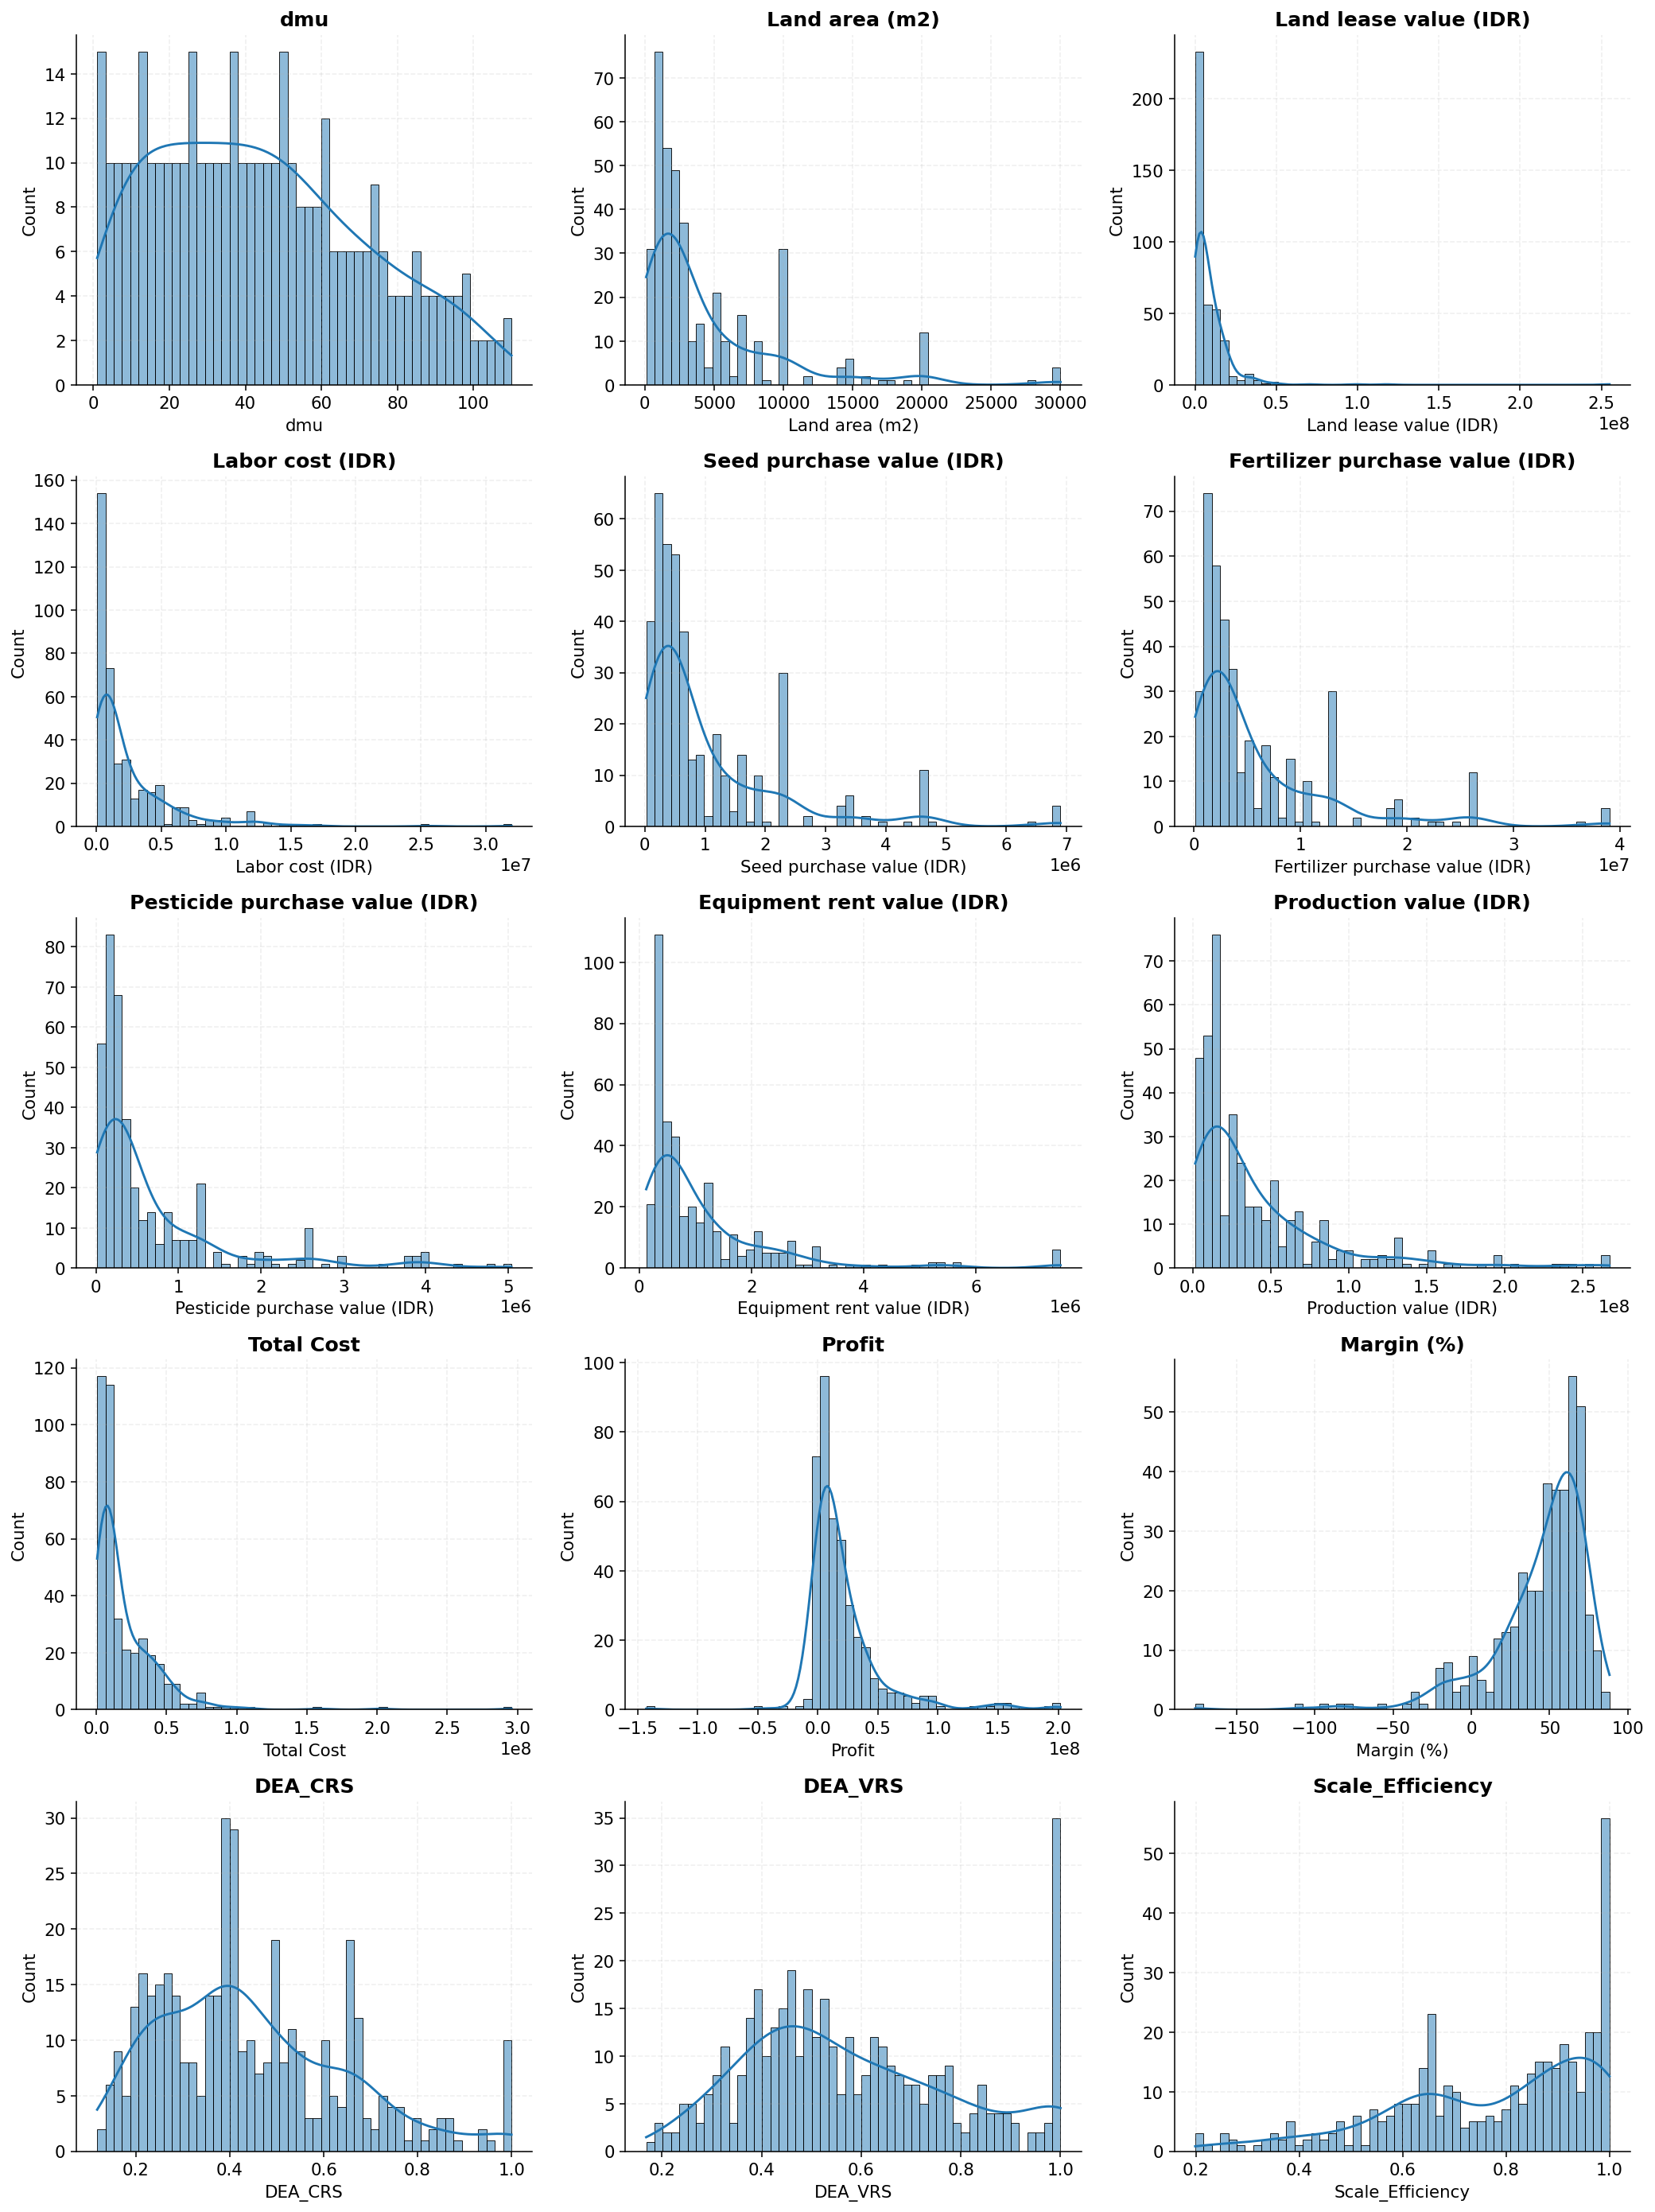

In [ ]:
# Check the distribution 
num_cols = df_farm.select_dtypes(include=['float64', 'int64']).columns
rows = (len(num_cols) + 2) // 3  
fig, axs = plt.subplots(rows, 3, figsize=(15, 4*rows))
axs = axs.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df_farm[col], bins=50, kde=True, ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

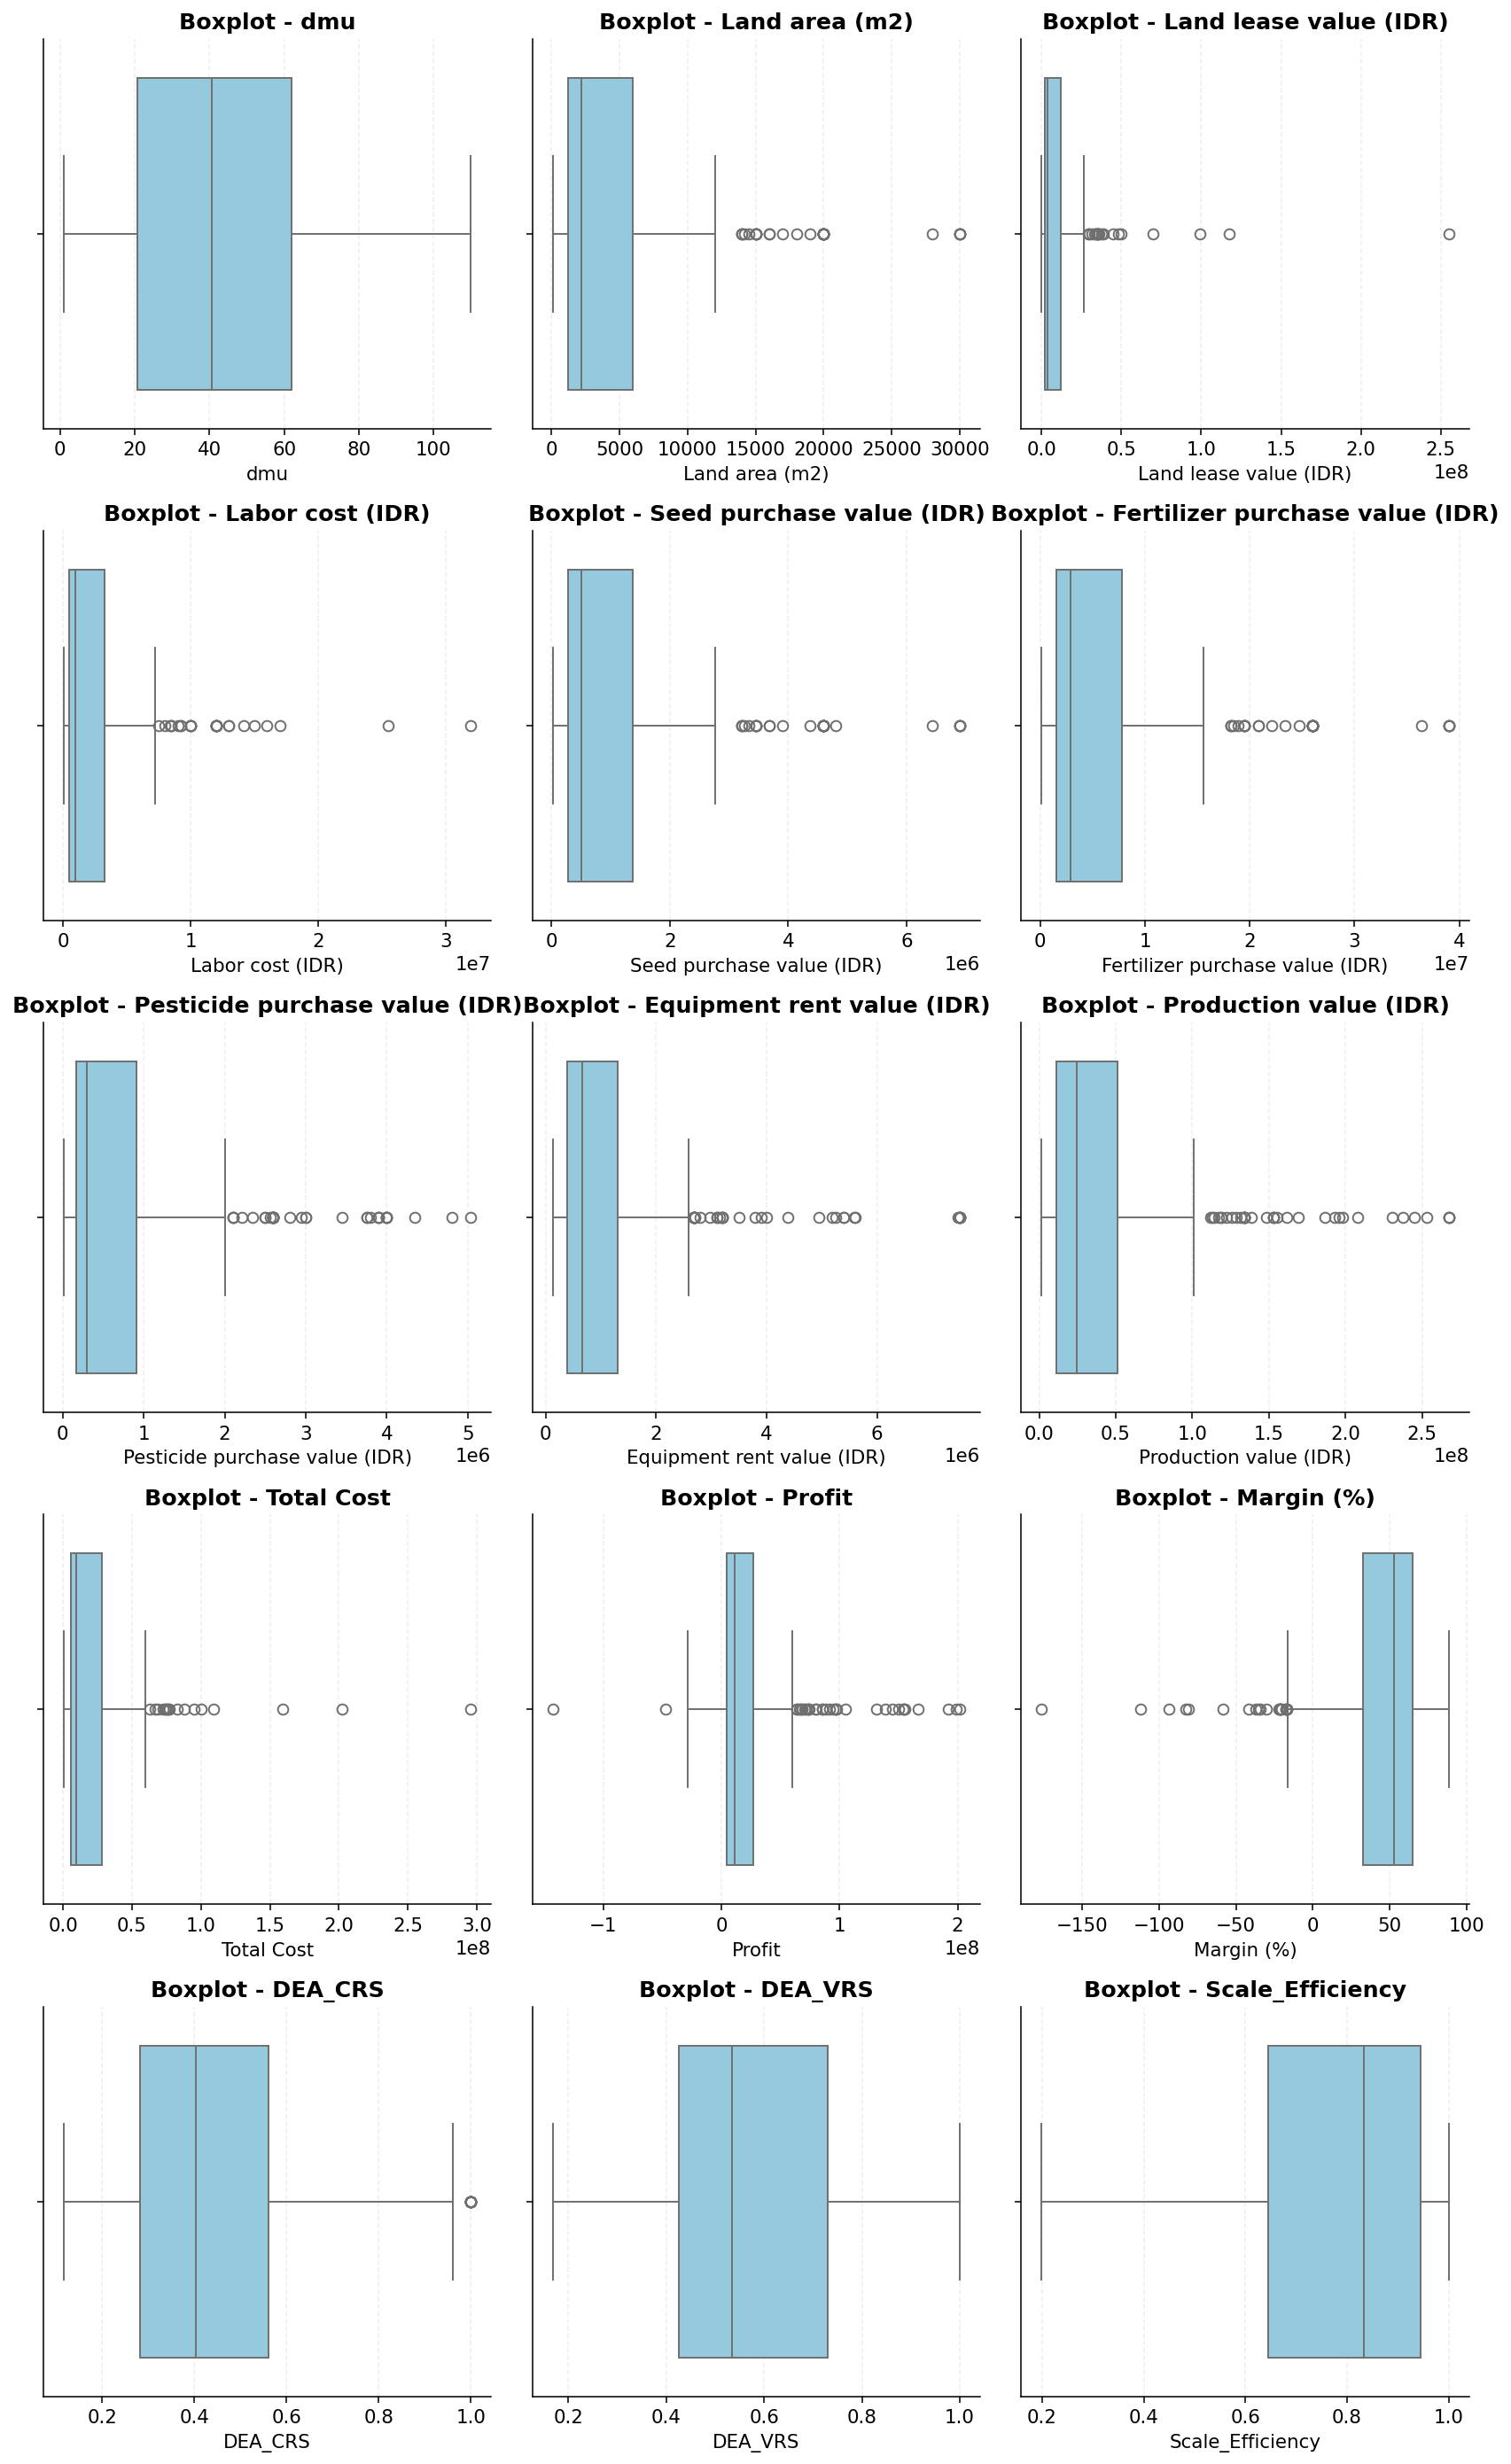

In [ ]:
# Check for outliers in numerical columns with boxplot
n_cols = 3 
n_rows = (len(num_cols) + n_cols - 1) // n_cols 
plt.figure(figsize=(12, 4 * n_rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_farm[col], color='skyblue')
    plt.title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

### **Farm Feature Engineering**

In [ ]:
FARMER_COST_COLS = [
    'Land lease value (IDR)',
    'Labor cost (IDR)',
    'Seed purchase value (IDR)',
    'Fertilizer purchase value (IDR)',
    'Pesticide purchase value (IDR)',
    'Equipment rent value (IDR)',
]
target_farm1 = df_farm['DEA_VRS']
target_farm2 = df_farm['Production value (IDR)']

In [ ]:
# Create percentage cost features for farmers
FARM_LABELS = ['sewa_lahan','tk','benih','pupuk','pestisida','sewa_alat']
for col, tag in zip(FARMER_COST_COLS, FARM_LABELS):
    df_farm[f'pct_{tag}'] = df_farm[col] / df_farm['Total Cost']

### **Farm Preprocessing**

In [ ]:
# return Log transformasi untuk mengurangi skewness
df_farm['log_scale'] = np.log1p(df_farm['Total Cost'])
df_farm['log_land']  = np.log1p(df_farm['Land area (m2)'])
df_farm['cost_per_m2'] = df_farm['Total Cost']                       / df_farm['Land area (m2)'].clip(lower=1)
df_farm['labor_per_m2'] = df_farm['Labor cost (IDR)']                 / df_farm['Land area (m2)'].clip(lower=1)
df_farm['fertilizer_per_m2'] = df_farm['Fertilizer purchase value (IDR)']  / df_farm['Land area (m2)'].clip(lower=1)
df_farm['rent_to_labor'] = df_farm['Land lease value (IDR)']           / df_farm['Labor cost (IDR)'].clip(lower=1)


In [ ]:
# One HOT ENCODE KABUPATEN
df_farm_enc = pd.get_dummies(df_farm, columns=['Kabupaten'], drop_first=False)
OHE_FARM = [c for c in df_farm_enc.columns if c.startswith('Kabupaten_')]

FARM_COLS = [f'pct_{t}' for t in FARM_LABELS]
FARM_LOG = ['log_scale','log_land','cost_per_m2','labor_per_m2',
             'fertilizer_per_m2','rent_to_labor']

In [ ]:
df_farm_enc.head(2)

,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR),Total Cost,...,log_land,cost_per_m2,labor_per_m2,fertilizer_per_m2,rent_to_labor,Kabupaten_Garut,Kabupaten_Indramayu,Kabupaten_Karawang,Kabupaten_Subang,Kabupaten_Tasikamalaya
0,1,2800,4900000,1400000,644000.0,3640000,364000.0,470000.0,16200000.0,11418000.0,...,7.937732,4077.857143,500.000000,1300.0,3.5,True,False,False,False,False
1,2,1400,4900000,500000,322000.0,1820000,182000.0,540000.0,8100000.0,8264000.0,...,7.244942,5902.857143,357.142857,1300.0,9.8,True,False,False,False,False


In [ ]:
# scalling
FARM_CLUSTER_FEATURES = ['log_scale', 'log_land'] + FARM_COLS

X_cluster_farm = df_farm[FARM_CLUSTER_FEATURES].fillna(0)
scaler_cl  = RobustScaler()
X_cl_farm_scaled = scaler_cl.fit_transform(X_cluster_farm)

### **1.1 CLUSTERING**

#### **Find Optimal Number of Cluster**

In [ ]:
inertia, sil_scores = [], []
K_RANGE = range(2, 8)
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_cl_farm_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cl_farm_scaled, lbl))
    print(f'  k={k}: inertia={km.inertia_:>10.0f}  silhouette={sil_scores[-1]:.4f}')

best_k = K_RANGE.start + sil_scores.index(max(sil_scores))
print(f'\nOptimal k={best_k} (highest silhouette: {max(sil_scores):.4f})')

  k=2: inertia=      2030  silhouette=0.6485
  k=3: inertia=      1634  silhouette=0.2656
  k=4: inertia=      1307  silhouette=0.3041
  k=5: inertia=      1047  silhouette=0.3268
  k=6: inertia=       920  silhouette=0.2935
  k=7: inertia=       813  silhouette=0.3185

Optimal k=2 (highest silhouette: 0.6485)


C:\Users\Tuf Gaming\AppData\Local\Temp\ipykernel_2680\1309867742.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


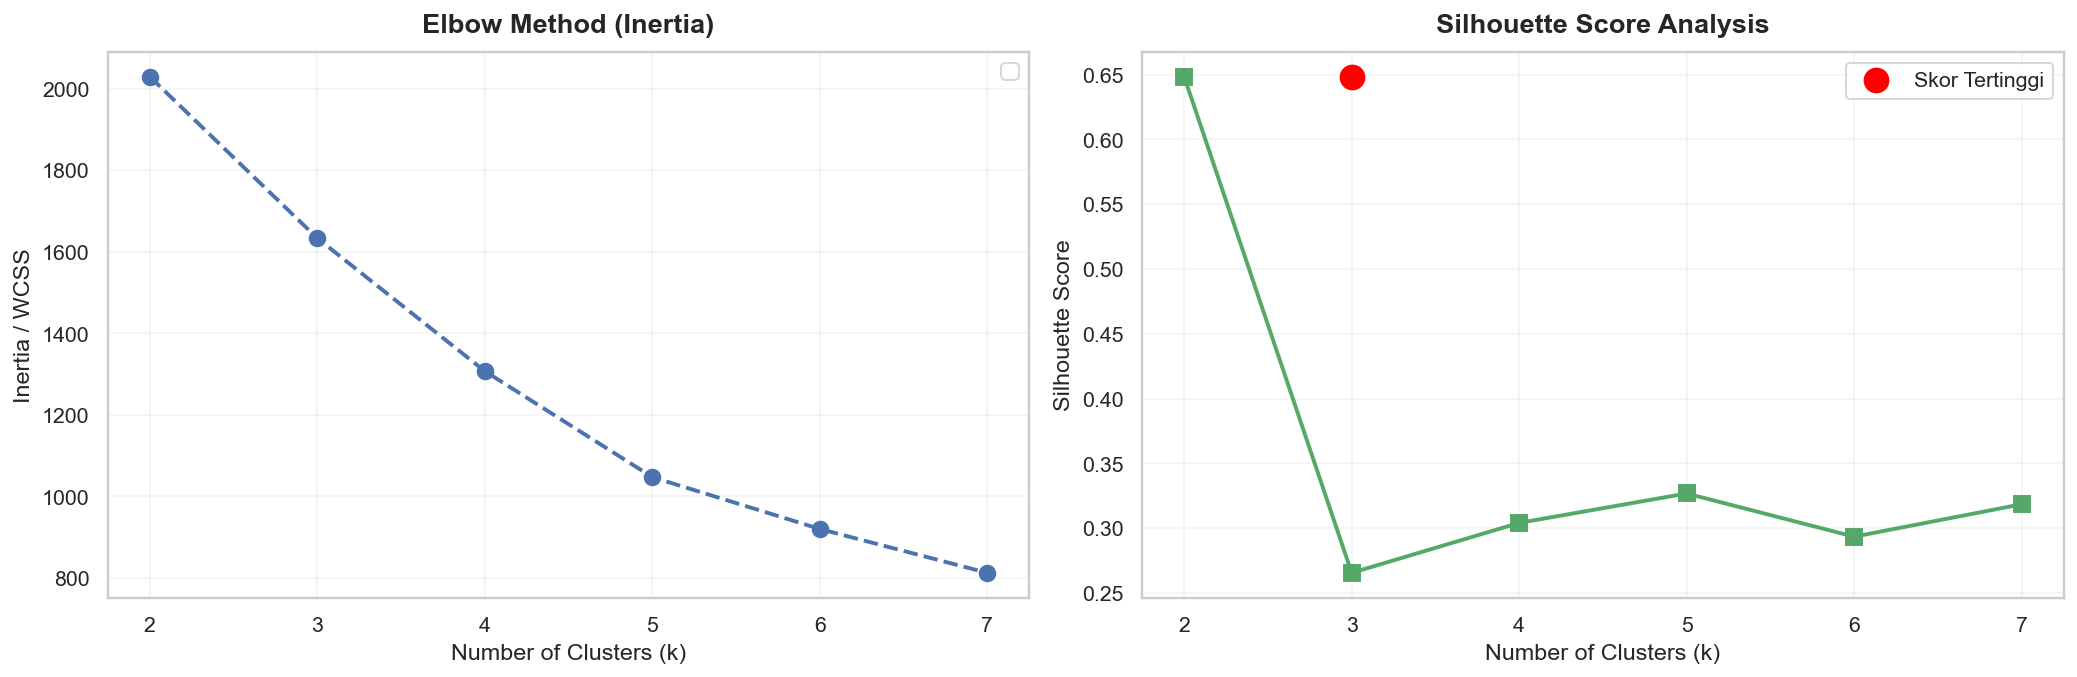

In [ ]:
sns.set_theme(style="whitegrid") 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(K_RANGE, inertia, marker='o', linestyle='--', color='b', linewidth=2, markersize=8)
ax[0].set_title('Elbow Method (Inertia)', fontsize=14, fontweight='bold', pad=10)
ax[0].set_xlabel('Number of Clusters (k)', fontsize=12)
ax[0].set_ylabel('Inertia / WCSS', fontsize=12)
ax[0].set_xticks(K_RANGE)
ax[0].legend()

ax[1].plot(K_RANGE, sil_scores, marker='s', linestyle='-', color='g', linewidth=2, markersize=8)
ax[1].scatter(3, max(sil_scores), color='red', s=150, zorder=5, label='Skor Tertinggi')
ax[1].set_title('Silhouette Score Analysis', fontsize=14, fontweight='bold', pad=10)
ax[1].set_xlabel('Number of Clusters (k)', fontsize=12)
ax[1].set_ylabel('Silhouette Score', fontsize=12)
ax[1].set_xticks(K_RANGE)
ax[1].legend()

plt.tight_layout()
plt.show()

#### **Cluster Model**

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_farm['cluster'] = kmeans.fit_predict(X_cl_farm_scaled)
df_farm_enc['cluster'] = df_farm['cluster']

cluster_profile = df_farm.groupby('cluster').agg(
    n_samples    = ('dmu', 'count'),
    avg_budget   = ('Total Cost', 'mean'),
    avg_land_m2  = ('Land area (m2)', 'mean'),
    avg_dea_vrs  = ('DEA_VRS', 'mean'),
    avg_margin   = ('Margin (%)', 'mean'),
    top_kab      = ('Kabupaten', lambda x: x.mode()[0] if not x.empty else 'N/A'),
).reset_index()

cluster_profile.columns = [
    'Cluster', 'Number of Farmers (n)', 'Avg Cost (IDR)', 
    'Land Area (m²)', 'Efficiency Score (DEA VRS)', 'Margin (%)', 'Dominant "Kabupaten"'
]

print('='*30 + ' PROFILE DATA CLUSTER ' + '='*30)
display(
    cluster_profile.style
    .format({
        'Avg Cost (IDR)': 'Rp{:,.2f}'.format,  
        'Efficiency Score (DEA VRS)': '{:.3f}'.format,
        'Margin (%)': '{:.1f}%'.format
    })
    .background_gradient(cmap='Blues', subset=['Number of Farmers (n)', 'Efficiency Score (DEA VRS)'])
    .hide(axis='index')
)

cluster_label_map = {i: f'Kelompok {i}' for i in range(best_k)}
df_farm['persona'] = df_farm['cluster'].map(cluster_label_map)
df_farm_enc['persona'] = df_farm['persona']

print('\n' + '='*25 + ' CLUSTER DISTRIBUTION PER "KABUPATEN" ' + '='*25)
crosstab_df = pd.crosstab(df_farm['Kabupaten'], df_farm['cluster'])
crosstab_df.columns = [f'Cluster {col}' for col in crosstab_df.columns]

display(
    crosstab_df.style
    .background_gradient(cmap='YlGnBu', axis=1) # Memberikan highlight warna per baris wilayah
)

============================== PROFILE DATA CLUSTER ==============================


Cluster,Number of Farmers (n),Avg Cost (IDR),Land Area (m²),Efficiency Score (DEA VRS),Margin (%),"Dominant ""Kabupaten"""
0,250,"Rp22,399,840.52",4277.488000,0.538,40.0%,Garut
1,35,"Rp4,197,265.07",460.000000,0.757,35.7%,Tasikamalaya
2,115,"Rp19,938,553.54",6316.808696,0.620,56.1%,Tasikamalaya



========================= CLUSTER DISTRIBUTION PER "KABUPATEN" =========================


,Cluster 0,Cluster 1,Cluster 2
Kabupaten,,,
Garut,63,4,31
Indramayu,44,8,10
Karawang,23,0,30
Subang,59,7,11
Tasikamalaya,61,16,33


### **1.2 MODEL 1 FARM (DEA Score)**

In [ ]:
FARM_FEAT_ML1 = FARM_COLS + FARM_LOG + OHE_FARM + ['cluster']

X_ml1_farm = df_farm_enc[FARM_FEAT_ML1]
y_ml1_farm = target_farm1
print(f'X shape : {X_ml1_farm.shape}')
print(f'Y (DEA_VRS): mean={y_ml1_farm.mean():.4f}, std={y_ml1_farm.std():.4f}')

X shape : (400, 18)
Y (DEA_VRS): mean=0.5806, std=0.2147


In [ ]:
# SPlitting
X_train1_farm, X_test1_farm, y_train1_farm, y_test1_farm = train_test_split(X_ml1_farm, y_ml1_farm, test_size=0.2,random_state=42, stratify=df_farm['cluster'])

#### **Training Model Farm 1**

In [ ]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 6],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
gs_farm_ml1 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=1
)
gs_farm_ml1.fit(X_train1_farm, y_train1_farm)
model1_farm= gs_farm_ml1.best_estimator_

print(f'Best CV MAPE: {-gs_farm_ml1.best_score_*100:.2f}%')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best CV MAPE: 21.89%


#### **Evaluate Model Farm 1**

In [ ]:
model1_farm.fit(X_train1_farm, y_train1_farm)
mape_test1 = mean_absolute_percentage_error(
    y_test1_farm, model1_farm.predict(X_test1_farm)
) * 100
print(f'MAPE di Test Set: {mape_test1:.2f}%')

MAPE di Test Set: 22.89%


In [ ]:
# use cross val to get more robust evaluation metrics
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_cv_pred = cross_val_predict(model1_farm, X_ml1_farm, y_ml1_farm, cv=kf)

mape_farm1 = mean_absolute_percentage_error(y_ml1_farm, y_cv_pred) * 100
mae_farm1  = mean_absolute_error(y_ml1_farm, y_cv_pred)
print('EVALUATION ML MODEL 1 (5-Fold CV):')
print(f'  MAPE : {mape_farm1:.2f}%')
print(f'  MAE  : {mae_farm1:.4f} DEA score points')

model1_farm.fit(X_ml1_farm, y_ml1_farm)

EVALUATION ML MODEL 1 (5-Fold CV):
  MAPE : 21.28%
  MAE  : 0.1103 DEA score points


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

#### **Feature Importance Farm Model 1**

In [ ]:
# SHAP Feature Importance
explainer1  = shap.TreeExplainer(model1_farm)
shap_vals1  = explainer1.shap_values(X_ml1_farm)
shap_imp1   = pd.Series(
    np.abs(shap_vals1).mean(axis=0),
    index=X_ml1_farm.columns
).sort_values(ascending=False)

print('SHAP FEATURE IMPORTANCE — ML MODEL 1:')
print(f'{"Rank":<5} {"Feature":<40} {"SHAP":>8}')
print('─'*56)
for i, (feat, val) in enumerate(shap_imp1.items(), 1):
    bar = '█' * int(val / shap_imp1.max() * 20)
    print(f'{i:<5} {feat:<40} {val:>8.4f}  {bar}')

# Top raw cost features untuk LP
TOP_LP = 4
LP_FEATURES = [f for f in shap_imp1.index if f in FARMER_COST_COLS][:TOP_LP]
print(f'\nTop {TOP_LP} fitur LP: {LP_FEATURES}')

SHAP FEATURE IMPORTANCE — ML MODEL 1:
Rank  Feature                                      SHAP
────────────────────────────────────────────────────────
1     log_scale                                  0.0675  ████████████████████
2     pct_sewa_alat                              0.0390  ███████████
3     cost_per_m2                                0.0299  ████████
4     pct_sewa_lahan                             0.0283  ████████
5     Kabupaten_Tasikamalaya                     0.0205  ██████
6     log_land                                   0.0174  █████
7     rent_to_labor                              0.0170  █████
8     pct_tk                                     0.0160  ████
9     labor_per_m2                               0.0116  ███
10    pct_pupuk                                  0.0096  ██
11    pct_benih                                  0.0091  ██
12    fertilizer_per_m2                          0.0083  ██
13    pct_pestisida                              0.0071  ██
14    Kabupaten_K

In [ ]:
shap_df1 = pd.DataFrame(shap_vals1, columns=X_ml1_farm.columns, index=df_farm.index)
top5     = shap_imp1.head(5).index.tolist()

print('CONTRIBUTION SHAP PER CLUSTER (top 5 features):')
for cl in sorted(df_farm['cluster'].unique()):
    mask = df_farm['cluster'] == cl
    avg  = df_farm.loc[mask, 'DEA_VRS'].mean()
    
    # Ambil nama cluster dari map, jika tidak ada (seperti indeks 2), gunakan nama default
    cl_name = cluster_label_map.get(cl, f"Cluster Tipe {cl}")
    
    print(f'\nCluster {cl} — {cl_name} (avg DEA={avg:.3f}):')
    
    # Menghitung rata-rata nilai SHAP untuk cluster aktif
    means = shap_df1.loc[mask, top5].mean().sort_values(ascending=False)
    for feat, val in means.items():
        arrow = '↑' if val > 0 else '↓'
        print(f'  {arrow} {feat:<40}: {val:+.4f}')

CONTRIBUTION SHAP PER CLUSTER (top 5 features):

Cluster 0 — Kelompok 0 (avg DEA=0.538):
  ↑ pct_sewa_alat                           : +0.0098
  ↓ Kabupaten_Tasikamalaya                  : -0.0003
  ↓ pct_sewa_lahan                          : -0.0096
  ↓ cost_per_m2                             : -0.0159
  ↓ log_scale                               : -0.0202

Cluster 1 — Kelompok 1 (avg DEA=0.757):
  ↑ log_scale                               : +0.1309
  ↑ pct_sewa_lahan                          : +0.0411
  ↑ Kabupaten_Tasikamalaya                  : +0.0057
  ↓ pct_sewa_alat                           : -0.0204
  ↓ cost_per_m2                             : -0.0235

Cluster 2 — Cluster Tipe 2 (avg DEA=0.620):
  ↑ cost_per_m2                             : +0.0255
  ↑ pct_sewa_lahan                          : +0.0123
  ↑ log_scale                               : +0.0122
  ↓ Kabupaten_Tasikamalaya                  : -0.0001
  ↓ pct_sewa_alat                           : -0.0143


### **1.3 LP OPTIMIZATION FARM**

**SET UP**

In [ ]:
CONFIGS = {
    'farmer': {
        'actor_name'    : 'Farmer',
        'df'            : df_farm,                       # gunakan df yang sudah di-encode untuk LP
        'fixed'         : ['Land area (m2)', 'Land lease value (IDR)'],
        'throughput_col': 'Land area (m2)',
        'group_type'    : 'cluster',           
        'optimizable'   : [
            'Labor cost (IDR)',
            'Seed purchase value (IDR)',
            'Fertilizer purchase value (IDR)',
            'Pesticide purchase value (IDR)',
            'Equipment rent value (IDR)',
        ],
        'output_col'    : 'Production value (IDR)',
        'shap_alpha'    : {                    # source: ML Model 2 SHAP
            'Fertilizer purchase value (IDR)': 0.90,  # SHAP 0.5028
            'Pesticide purchase value (IDR)' : 0.85,  # SHAP 0.2018
            'Seed purchase value (IDR)'      : 0.80,  # SHAP 0.1202
            'Labor cost (IDR)'               : 0.75,  # SHAP 0.0910
            'Equipment rent value (IDR)'     : 0.70,  # SHAP 0.0846
        },
        'export_file'   : 'farmer_lp_optimized.csv',
    },

    'miller': {
        'actor_name'    : 'Miller',
        'df'            : df_miller,                     # gunakan df yang sudah di-encode untuk LP
        'fixed'         : ['Value of milled grains (IDR)', 'Number of machines (unit)'],
        'throughput_col': 'Value of milled grains (IDR)',
        'group_type'    : 'machine_bins',      # bin by Number of machines: 1-2, 3-5, 6+
        'optimizable'   : [
            'Labor cost (IDR)',
            'Supporting equipment cost (IDR)',
        ],
        'output_col'    : 'Revenue',
        'shap_alpha'    : {
            'Labor cost (IDR)'               : 0.80,  # SHAP 0.0228
            'Supporting equipment cost (IDR)': 0.75,  # SHAP 0.0200
        },
        'export_file'   : 'miller_lp_optimized.csv',
    },

    'middlemen': {
        'actor_name'    : 'Middlemen',
        'df'            : df_middleman,                  # gunakan df yang sudah di-encode untuk LP
        'fixed'         : ['Total rice purchase (IDR)'],
        'throughput_col': 'Total rice purchase (IDR)',
        'group_type'    : 'cluster',           # uses 'cluster' column from ML
        'optimizable'   : [
            'Labor cost (IDR)',
            'Building rent cost (IDR)',
            'Supporting equipment cost (IDR)',
        ],
        'output_col'    : 'Value of rice sold (IDR)',
        'shap_alpha'    : {
            'Labor cost (IDR)'               : 0.80,  # SHAP 0.0226
            'Building rent cost (IDR)'       : 0.75,  # SHAP 0.0134
            'Supporting equipment cost (IDR)': 0.70,  # SHAP 0.0127
        },
        'export_file'   : 'middlemen_lp_optimized.csv',
    },

    'wholesaler': {
        'actor_name'    : 'Wholesaler',
        'df'            : df_wholesaler,                 # gunakan df yang sudah di-encode untuk LP
        'fixed'         : ['Value of rice purchase (IDR)'],
        'throughput_col': 'Value of rice purchase (IDR)',
        'group_type'    : 'single',            # no clustering — all in one pool
        'optimizable'   : [
            'Supporting equipment cost (IDR)',
            'Labor cost (IDR)',
            'Building rent cost (IDR)',
        ],
        'output_col'    : 'Value of rice sold (IDR)',
        'shap_alpha'    : {
            'Supporting equipment cost (IDR)': 0.90,  # SHAP 0.4696 — very high!
            'Labor cost (IDR)'               : 0.85,  # SHAP 0.1700
            'Building rent cost (IDR)'       : 0.80,  # SHAP 0.0958
        },
        'export_file'   : 'wholesaler_lp_optimized.csv',
    },

    'retailer': {
        'actor_name'    : 'Retailer',
        'df'            : df_retail,                   # gunakan df yang sudah di-encode untuk LP
        'fixed'         : ['Value of rice purchase (IDR)'],
        'throughput_col': 'Value of rice purchase (IDR)',
        'group_type'    : 'single',            # no clustering — all in one pool
        'optimizable'   : [
            'Supporting equipment cost (IDR)',
            'Labor cost (IDR)',
            'Building rent cost (IDR)',
        ],
        'output_col'    : 'Value of rice sold (IDR)',
        'shap_alpha'    : {
            'Supporting equipment cost (IDR)': 0.85,  # SHAP 0.0184
            'Labor cost (IDR)'               : 0.80,  # SHAP 0.0166
            'Building rent cost (IDR)'       : 0.75,  # SHAP 0.0110
        },
        'export_file'   : 'retailer_lp_optimized.csv',
    },
}

for k, c in CONFIGS.items():
    print(f"  {c['actor_name']:<12}: group_type={c['group_type']:<14} "
          f"| {len(c['optimizable'])} optimizable | fixed={c['fixed']}")

  Farmer      : group_type=cluster        | 5 optimizable | fixed=['Land area (m2)', 'Land lease value (IDR)']
  Miller      : group_type=machine_bins   | 2 optimizable | fixed=['Value of milled grains (IDR)', 'Number of machines (unit)']
  Middlemen   : group_type=cluster        | 3 optimizable | fixed=['Total rice purchase (IDR)']
  Wholesaler  : group_type=single         | 3 optimizable | fixed=['Value of rice purchase (IDR)']
  Retailer    : group_type=single         | 3 optimizable | fixed=['Value of rice purchase (IDR)']


In [ ]:
DATA = {}
for key, cfg in CONFIGS.items():
        df = cfg['df'] 
        DATA[key] = df
        n_ineff = (df['DEA_VRS'] < 0.80).sum()
        has_cl  = 'cluster' in df.columns
        print(f"✅ {cfg['actor_name']:<12}: {len(df):>4} rows | "
              f"DEA_VRS {df['DEA_VRS'].min():.2f}–{df['DEA_VRS'].max():.2f} | "
              f"inefficient: {n_ineff} | cluster col: {has_cl}")

✅ Farmer      :  400 rows | DEA_VRS 0.17–1.00 | inefficient: 330 | cluster col: True
✅ Miller      :  105 rows | DEA_VRS 0.34–1.00 | inefficient: 35 | cluster col: False
✅ Middlemen   :  104 rows | DEA_VRS 0.52–1.00 | inefficient: 60 | cluster col: False
✅ Wholesaler  :  104 rows | DEA_VRS 0.14–1.00 | inefficient: 82 | cluster col: False
✅ Retailer    :  102 rows | DEA_VRS 0.62–1.00 | inefficient: 40 | cluster col: False


In [ ]:
def prepare_groups(df, cfg):
    df = df.copy()
    gtype = cfg['group_type']

    if gtype == 'cluster':
        if 'cluster' not in df.columns:
            raise ValueError(f"'cluster' column missing in {cfg['actor_name']} data!")
        df['_group'] = df['cluster'].astype(str)

    elif gtype == 'machine_bins':
        df['_group'] = pd.cut(
            df['Number of machines (unit)'],
            bins=[0, 2, 5, float('inf')],
            labels=['Small (1-2)', 'Medium (3-5)', 'Large (6+)']
        ).astype(str)

    elif gtype == 'single':
        df['_group'] = 'all'

    return df

In [ ]:
def compute_peer_benchmarks(df, cfg, efficiency_threshold=0.80):
    tcol  = cfg['throughput_col']
    bench = {}

    for gid in df['_group'].unique():
        sub_all    = df[df['_group'] == gid]
        rev_median = sub_all[tcol].median()   # ← median revenue per group

        # Filter: efisien DAN revenue di atas median
        sub_peers  = sub_all[
            (sub_all['DEA_VRS'] >= efficiency_threshold) &
            (sub_all[tcol] >= rev_median)              # ← tambahan filter
        ]

        # Fallback 1: kalau peer terlalu sedikit, relax revenue filter
        if len(sub_peers) < 3:
            sub_peers = sub_all[sub_all['DEA_VRS'] >= efficiency_threshold]

        # Fallback 2: kalau masih terlalu sedikit, pakai semua DMU di group
        if len(sub_peers) < 3:
            sub_peers = sub_all

        gbench = {}
        for cost in cfg['optimizable']:
            ratio = sub_peers[cost] / sub_peers[tcol].clip(lower=1)
            gbench[cost] = {
                'floor_ratio': ratio.quantile(0.25),
                'ceil_ratio' : ratio.quantile(0.75),
                'n_peers'    : len(sub_peers),
            }
        bench[gid] = gbench

    return bench

In [ ]:
def run_lp_single(row, cfg, benchmarks):
    # Skip fully efficient
    if row['DEA_VRS'] >= 0.9999:
        res = {'lp_status': 'Efficient — skipped'}
        for c in cfg['optimizable']:
            res[f'lp_{c}'] = float(row[c])
        return res

    gid        = str(row['_group'])
    throughput = max(float(row[cfg['throughput_col']]), 1)
    bench      = benchmarks.get(gid, benchmarks[list(benchmarks.keys())[0]])
    alpha      = cfg['shap_alpha']

    prob    = LpProblem(f"LP_{int(row['dmu'])}", LpMinimize)
    lp_vars = {}

    for cost in cfg['optimizable']:
        current = float(row[cost])
        b       = bench[cost]

        lb = max(alpha[cost] * current, b['floor_ratio'] * throughput, 0.0)
        ub = min(current, b['ceil_ratio'] * throughput)

        if lb > ub:      
            lb = ub = current

        safe = (cost.replace(' ','_').replace('(','').replace(')','')
                    .replace('/','').replace('.',''))
        lp_vars[cost] = LpVariable(safe, lowBound=lb, upBound=ub)

    prob += lpSum(lp_vars[c] for c in cfg['optimizable'])
    prob.solve(PULP_CBC_CMD(msg=0))

    status = LpStatus[prob.status]
    res    = {'lp_status': status}

    if status == 'Optimal':
        for c in cfg['optimizable']:
            res[f'lp_{c}'] = max(float(value(lp_vars[c])), 0.0)
    else:                # fallback: SHAP floor
        for c in cfg['optimizable']:
            res[f'lp_{c}'] = alpha[c] * float(row[c])
        res['lp_status'] = 'Infeasible — SHAP floor'

    return res

In [ ]:
def run_lp_actor(df_raw, cfg):
    df = prepare_groups(df_raw, cfg)

    benchmarks = compute_peer_benchmarks(df, cfg)

    lp_rows = [run_lp_single(row, cfg, benchmarks) for _, row in df.iterrows()]
    df_res  = pd.DataFrame(lp_rows)

    for col in df_res.columns:
        df[col] = df_res[col].values

    opt_c  = cfg['optimizable']
    lp_c   = [f'lp_{c}' for c in opt_c]
    num_fixed = df[[c for c in cfg['fixed'] if df[c].dtype != object]].sum(axis=1) if cfg['fixed'] else 0

    df['current_opt_total'] = df[opt_c].sum(axis=1)
    df['lp_opt_total']      = df[lp_c].sum(axis=1)
    df['cost_saving']       = df['current_opt_total'] - df['lp_opt_total']
    df['pct_saving']        = df['cost_saving'] / df['current_opt_total'].clip(lower=1) * 100

    fixed_num = df[[c for c in cfg['fixed']
                    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]]
    df['opt_total_cost'] = fixed_num.sum(axis=1) + df['lp_opt_total']
    df['current_profit'] = df['Profit']
    df['opt_profit']     = df[cfg['output_col']] - df['opt_total_cost']
    df['profit_gain']    = df['opt_profit'] - df['current_profit']
    df['profit_gain_pct']= df['profit_gain'] / df['current_profit'].abs().clip(lower=1) * 100

    return df

In [ ]:
def print_results(df, cfg):
    name   = cfg['actor_name']
    opt_c  = cfg['optimizable']
    n_opt  = (df['lp_status'] == 'Optimal').sum()
    n_eff  = df['lp_status'].str.contains('skipped', na=False).sum()
    n_fb   = len(df) - n_opt - n_eff

    print(f"  {name.upper()} — {len(df)} DMUs  "
          f"(Optimal:{n_opt} | Efficient:{n_eff} | Fallback:{n_fb})")
    print(f"{'═'*65}")

    print(f"COST SAVINGS")
    print(f"     Avg saving      : Rp{df['cost_saving'].mean()/1e6:.2f}M  "
          f"({df['pct_saving'].mean():.1f}% reduction)")
    print(f"     Total saving    : Rp{df['cost_saving'].sum()/1e9:.2f}B")

    print(f"PROFIT IMPACT")
    print(f"     Before LP       : Rp{df['current_profit'].mean()/1e6:.2f}M avg")
    print(f"     After LP        : Rp{df['opt_profit'].mean()/1e6:.2f}M avg")
    print(f"     Avg profit gain : Rp{df['profit_gain'].mean()/1e6:.2f}M")
    print(f"     Improved        : {(df['profit_gain']>0).sum()} / {len(df)}")

    print(f"PER-INPUT REDUCTION")
    print(f"     {'Input':<36} {'Current':>10} {'After LP':>10} {'Cut':>7}")
    print(f"     {'-'*65}")
    for c in opt_c:
        cur = df[c].mean()
        opt = df[f'lp_{c}'].mean()
        pct = (1 - opt/max(cur,1)) * 100
        lbl = (c.replace(' (IDR)','').replace(' purchase value','')
                .replace(' value','').replace(' rent','').replace(' cost',''))
        print(f"     {lbl:<36} Rp{cur/1e6:>7.2f}M  Rp{opt/1e6:>7.2f}M  {pct:>5.1f}%↓")

    print(f"PER KABUPATEN")
    kab = (df.groupby('Kabupaten')
             .agg(n=('dmu','count'), vrs=('DEA_VRS','mean'),
                  gain=('profit_gain','mean'))
             .sort_values('gain', ascending=False))
    for k, r in kab.iterrows():
        print(f"     {k:<15} n={int(r['n'])} | DEA_VRS={r['vrs']:.3f} | "
              f"profit_gain=Rp{r['gain']/1e6:.2f}M")

#### **Optimization**

In [ ]:
cfg = CONFIGS['farmer']
df  = DATA['farmer']


RESULTS_FARMER = run_lp_actor(df, cfg)
print_results(RESULTS_FARMER, cfg)

  FARMER — 400 DMUs  (Optimal:365 | Efficient:35 | Fallback:0)
═════════════════════════════════════════════════════════════════
COST SAVINGS
     Avg saving      : Rp0.34M  (3.2% reduction)
     Total saving    : Rp0.14B
PROFIT IMPACT
     Before LP       : Rp21.22M avg
     After LP        : Rp21.56M avg
     Avg profit gain : Rp0.33M
     Improved        : 300 / 400
PER-INPUT REDUCTION
     Input                                   Current   After LP     Cut
     -----------------------------------------------------------------
     Labor                                Rp   2.46M  Rp   2.29M    6.9%↓
     Seed                                 Rp   1.02M  Rp   1.02M    0.0%↓
     Fertilizer                           Rp   5.89M  Rp   5.89M    0.0%↓
     Pesticide                            Rp   0.68M  Rp   0.67M    1.4%↓
     Equipment                            Rp   1.13M  Rp   0.97M   14.1%↓
PER KABUPATEN
     Karawang        n=53 | DEA_VRS=0.505 | profit_gain=Rp0.79M
     Indramayu   

### **1.4 MODEL 2 FARM (Revenue)**

In [ ]:
FARM_FEAT_ML2 = FARMER_COST_COLS  # raw cost features only

X_ml2_farm   = df_farm[FARM_FEAT_ML2]
y_ml2_farm  = np.log1p(target_farm2)  

print(f'X shape : {X_ml2_farm.shape}')
print(f'Y (log Revenue): mean={y_ml2_farm.mean():.4f}, std={y_ml2_farm.std():.4f}')

X shape : (400, 6)
Y (log Revenue): mean=16.9582, std=1.1435


In [ ]:
X_train2_farm, X_test2_farm, y_train2_farm, y_test2_farm = train_test_split(X_ml2_farm, y_ml2_farm, test_size=0.2, random_state=42, stratify=df_farm['cluster'])

#### **Training Model Farm 2**

In [ ]:
gs_farm_ml2 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=1
)
gs_farm_ml2.fit(X_ml2_farm, y_ml2_farm)
model2_farm = gs_farm_ml2.best_estimator_

print(f'Best CV MAPE: {-gs_farm_ml2.best_score_*100:.2f}%')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best CV MAPE: 1.89%


#### **Evaluate Model Farm 2**

In [ ]:
model2_farm.fit(X_train2_farm, y_train2_farm)
mape_test2 = mean_absolute_percentage_error(
    y_test2_farm, model2_farm.predict(X_test2_farm)
) * 100
print(f'MAPE Model 2 di Test Set: {mape_test2:.2f}%')


MAPE Model 2 di Test Set: 1.53%


In [ ]:
y_cv_pred2   = np.expm1(cross_val_predict(model2_farm, X_ml2_farm, y_ml2_farm, cv=kf))
y_orig2      = np.expm1(y_ml2_farm)
mape2        = mean_absolute_percentage_error(y_orig2, y_cv_pred2) * 100
mae2         = mean_absolute_error(y_orig2, y_cv_pred2)

print('EVALUASI ML MODEL 2 (5-Fold CV):')
print(f'  MAPE : {mape2:.2f}%')
print(f'  MAE  : Rp{mae2/1e6:.2f} juta')

# Fit final
model2_farm.fit(X_ml2_farm, y_ml2_farm)

EVALUASI ML MODEL 2 (5-Fold CV):
  MAPE : 29.02%
  MAE  : Rp11.45 juta


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

#### **Feature Importance Farm Model 2**

In [ ]:
explainer2 = shap.TreeExplainer(model2_farm)
shap_vals2 = explainer2.shap_values(X_ml2_farm)
shap_imp2  = pd.Series(
    np.abs(shap_vals2).mean(axis=0),
    index=X_ml2_farm.columns
).sort_values(ascending=False)

print('SHAP FEATURE IMPORTANCE — ML MODEL 2 (predict Revenue):')
for i, (feat, val) in enumerate(shap_imp2.items(), 1):
    bar = '█' * int(val / shap_imp2.max() * 20)
    print(f'  {i}. {feat:<45}: {val:.4f}  {bar}')

SHAP FEATURE IMPORTANCE — ML MODEL 2 (predict Revenue):
  1. Fertilizer purchase value (IDR)              : 0.5246  ████████████████████
  2. Pesticide purchase value (IDR)               : 0.1789  ██████
  3. Seed purchase value (IDR)                    : 0.1069  ████
  4. Labor cost (IDR)                             : 0.0990  ███
  5. Equipment rent value (IDR)                   : 0.0866  ███
  6. Land lease value (IDR)                       : 0.0647  ██


## **2. MILLER**

### **Short Analysis**

In [ ]:
df_miller.describe().T

,count,mean,std,min,25%,50%,75%,max
dmu,105.0,1.165714e+01,7.137157e+00,1.000000e+00,6.000000e+00,1.100000e+01,1.700000e+01,2.900000e+01
Number of machines (unit),105.0,2.228571e+00,1.287941e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Value of milled grains (IDR),105.0,2.544889e+08,6.437415e+08,3.000000e+06,2.500000e+07,1.200000e+08,2.750000e+08,5.000000e+09
Amount of milled rice (Kg),105.0,3.185379e+04,8.349503e+04,3.000000e+02,3.000000e+03,1.400000e+04,3.500000e+04,6.000000e+05
Labor cost (IDR),105.0,9.541283e+06,1.222761e+07,1.200000e+06,3.000000e+06,5.392557e+06,8.987595e+06,6.500000e+07
Supporting equipment cost (IDR),105.0,1.599538e+06,1.421076e+06,1.500000e+05,5.000000e+05,1.599538e+06,2.000000e+06,6.000000e+06
nilaiberashasilgiling,105.0,3.028773e+08,7.817516e+08,2.902899e+06,2.902899e+07,1.260000e+08,3.363492e+08,5.689682e+09
Total revenue of milling machine (IDR),105.0,2.484413e+07,6.336994e+07,3.120000e+05,2.600000e+06,1.040000e+07,2.860000e+07,4.680000e+08
Revenue,105.0,3.277214e+08,8.447340e+08,3.214899e+06,3.230000e+07,1.390000e+08,3.649492e+08,6.126482e+09
Total Cost,105.0,2.656297e+08,6.478953e+08,5.300000e+06,3.269008e+07,1.263702e+08,2.810000e+08,5.019575e+09


In [ ]:
print('PROFITABILITAS MILLER PER KABUPATEN:')
eda = df_miller.groupby('Kabupaten').agg(
    n               = ('dmu',        'count'),
    pct_untung      = ('Profit',      lambda x: f"{(x>0).mean()*100:.1f}%"),
    margin_avg      = ('Margin (%)',  lambda x: f"{x.mean():.1f}%"),
    dea_vrs_avg     = ('DEA_VRS',     lambda x: f"{x.mean():.3f}"),
    dea_frontier    = ('DEA_VRS',     lambda x: f"{(x>=0.999).sum()}"),
    scale_eff_avg   = ('Scale_Efficiency', lambda x: f"{x.mean():.3f}"),
).reset_index()
print(eda.to_string(index=False))

PROFITABILITAS MILLER PER KABUPATEN:
  Kabupaten  n pct_untung margin_avg dea_vrs_avg dea_frontier scale_eff_avg
      Garut 24      58.3%     -12.1%       0.884            8         0.890
  Indramayu 17      88.2%       9.9%       0.844            4         0.994
   Karawang 14      28.6%     -22.1%       0.674            0         0.972
     Subang 21      81.0%      18.6%       0.888            1         0.980
Tasikmalaya 29      72.4%      -1.3%       0.904           10         0.892


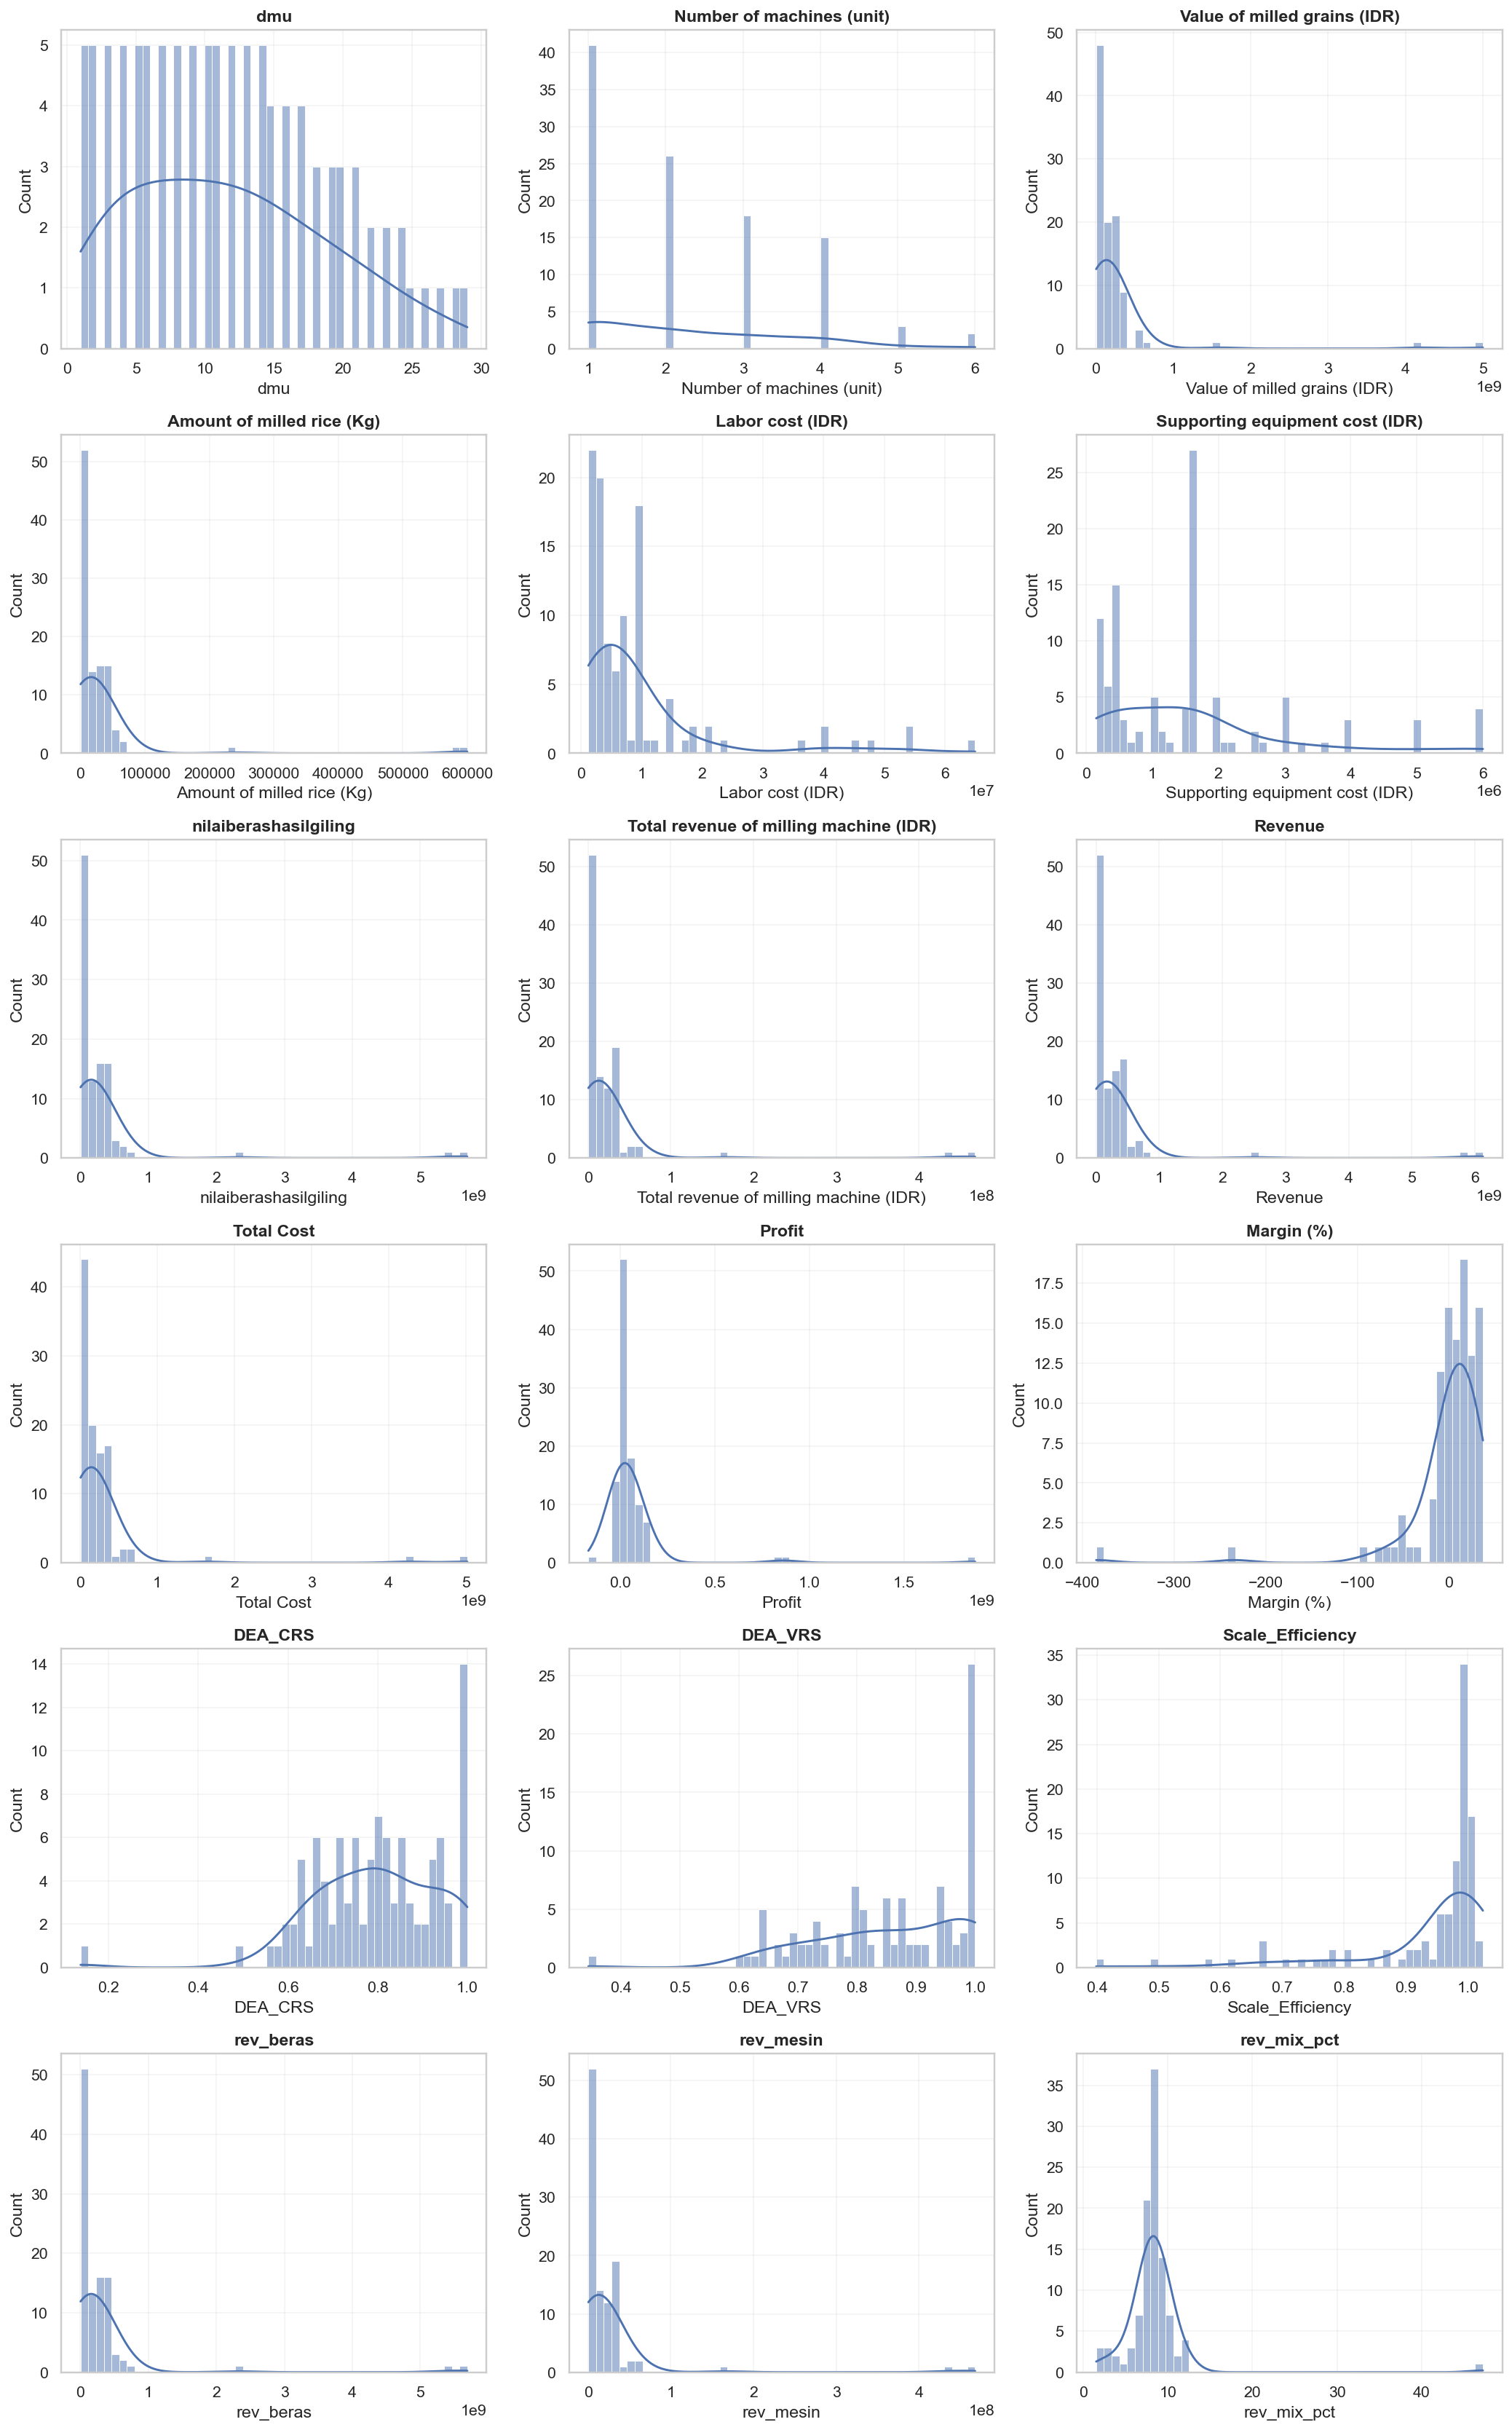

In [ ]:
# Check the distribution 
num_cols = df_miller.select_dtypes(include=['float64', 'int64']).columns
rows = (len(num_cols) + 2) // 3  
fig, axs = plt.subplots(rows, 3, figsize=(15, 4*rows))
axs = axs.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df_miller[col], bins=50, kde=True, ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

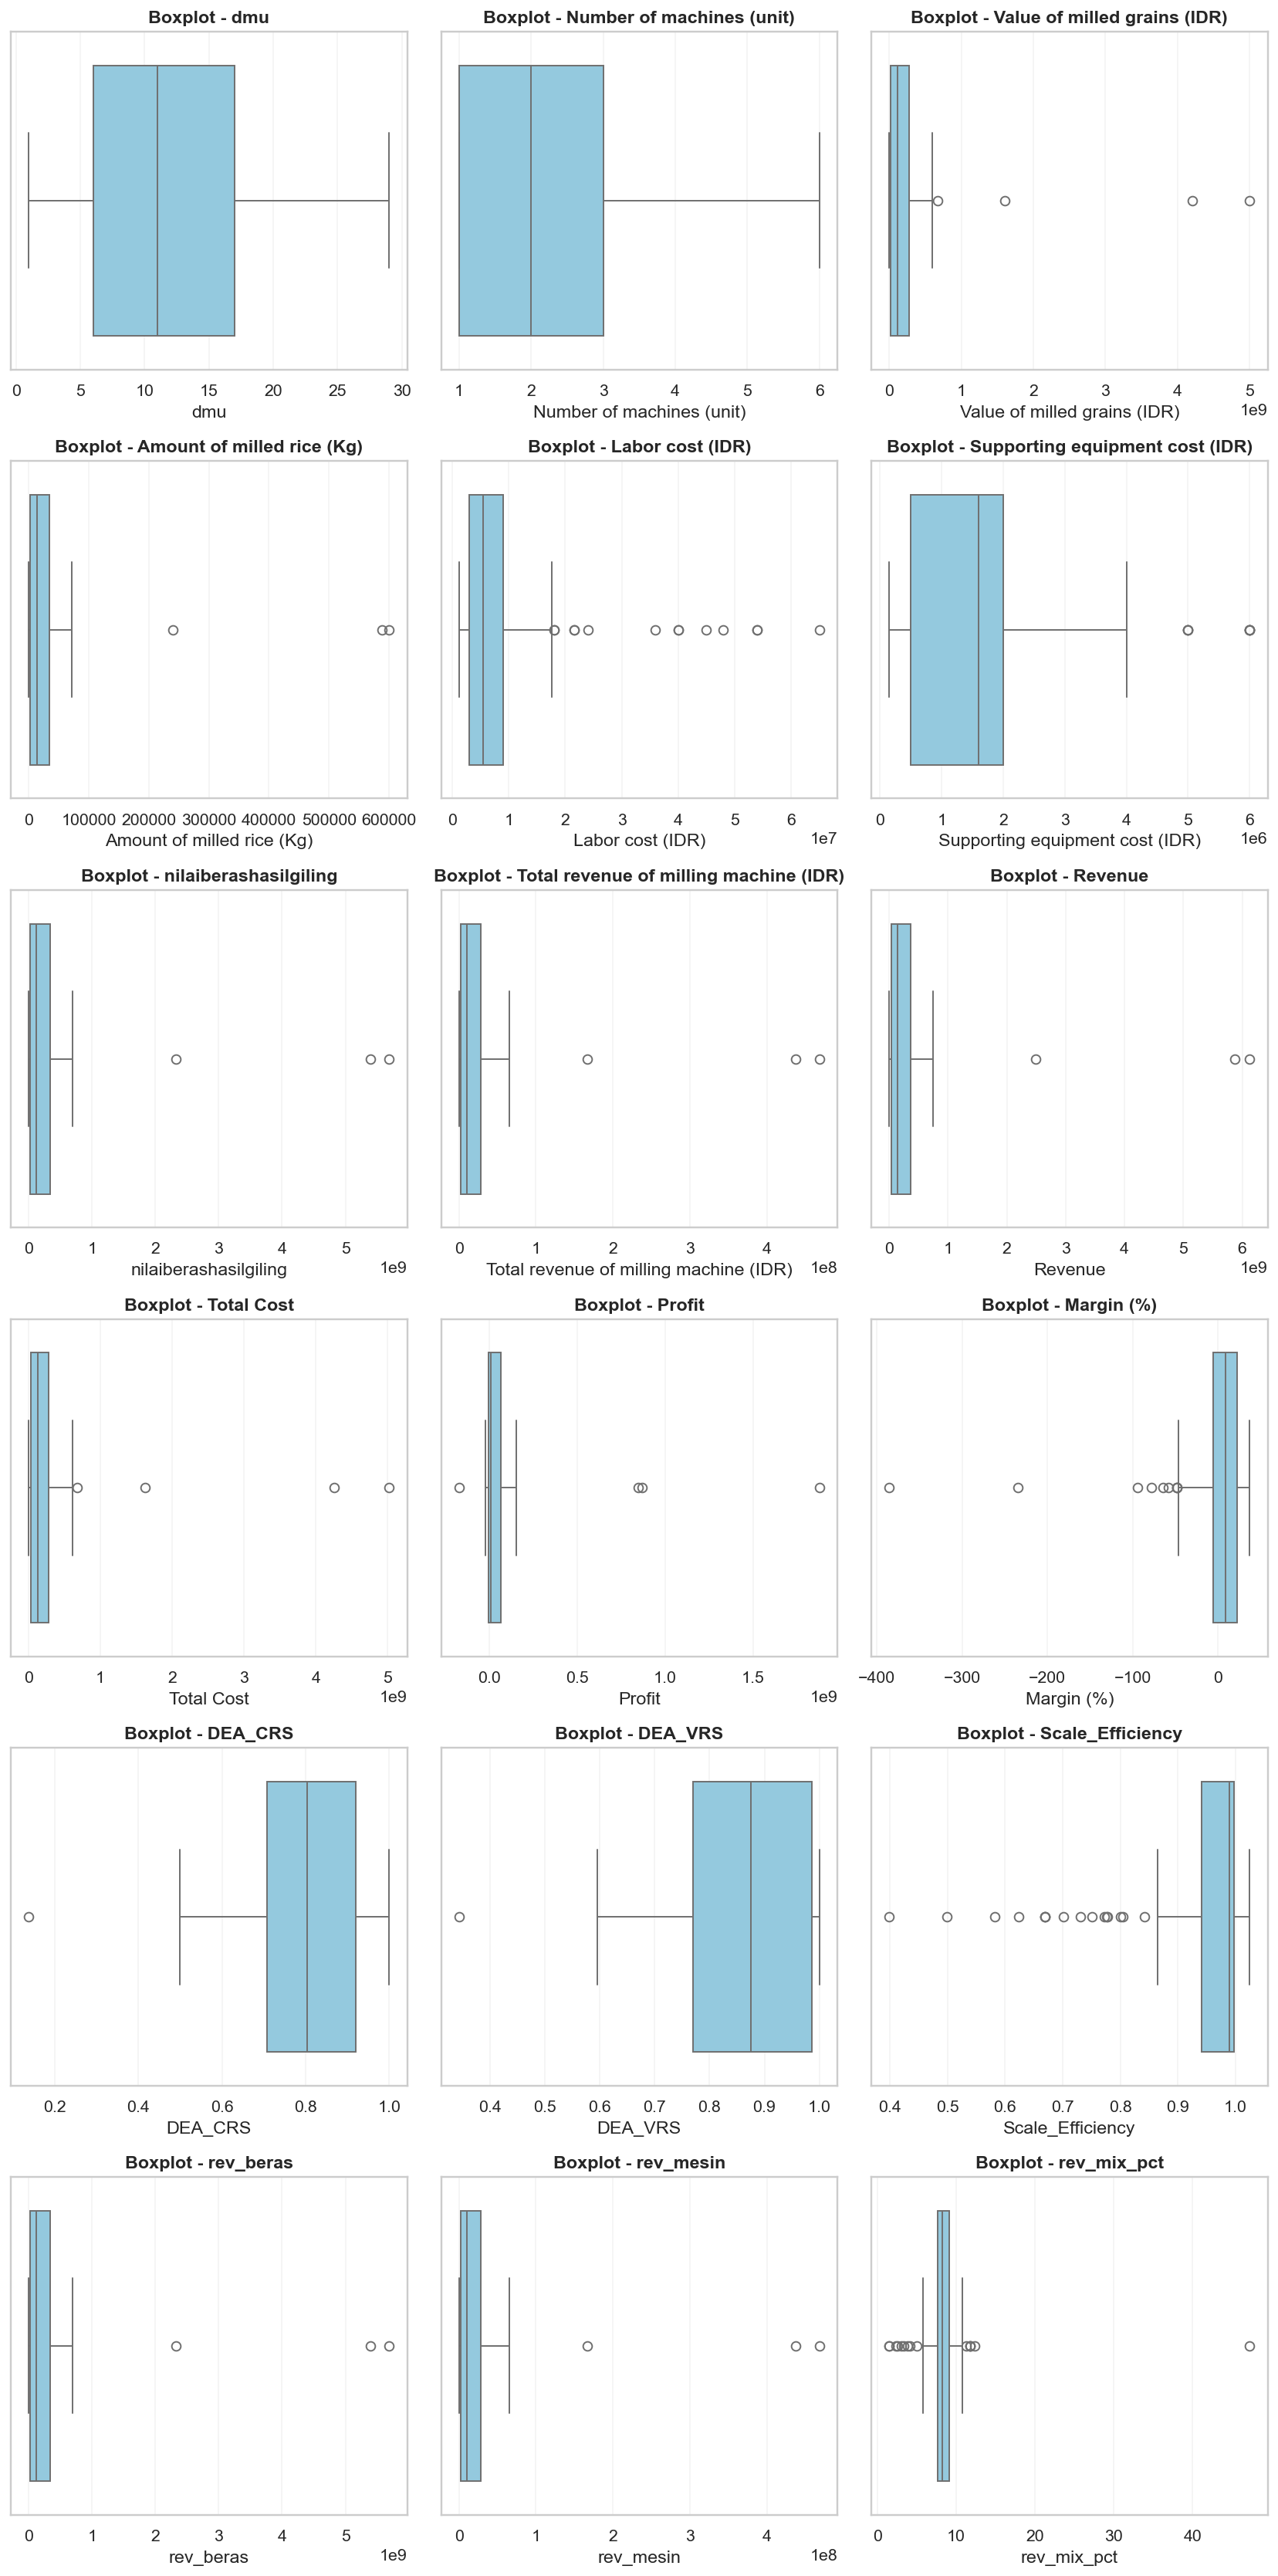

In [ ]:
# Check for outliers in numerical columns with boxplot
n_cols = 3 
n_rows = (len(num_cols) + n_cols - 1) // n_cols 
plt.figure(figsize=(12, 4 * n_rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_miller[col], color='skyblue')
    plt.title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

### **Miller Feature Engineering**

In [ ]:
MILLER_COST_COLS = [
    'Value of milled grains (IDR)',
    'Labor cost (IDR)',
    'Supporting equipment cost (IDR)',
]
target_miller1 = df_miller['DEA_VRS']
target_miller2 = df_miller['Revenue']

In [ ]:
MILLER_LABELS = ['beli_gabah','tk','peralatan']
for col, tag in zip(MILLER_COST_COLS, MILLER_LABELS):
    df_miller[f'pct_{tag}'] = df_miller[col] / df_miller['Total Cost']

### **Miller Preprocessing**

In [ ]:
df_miller['log_scale'] = np.log1p(df_miller['Total Cost'])
df_miller['log_grains'] = np.log1p(df_miller['Value of milled grains (IDR)'])
df_miller['kg_per_machine'] = df_miller['Amount of milled rice (Kg)'] / df_miller['Number of machines (unit)'].clip(lower=1)

In [ ]:
# OHE Kabupaten
df_miller_enc = pd.get_dummies(df_miller, columns=['Kabupaten'], drop_first=False)
OHE_MILLER = [c for c in df_miller_enc.columns if c.startswith('Kabupaten_')]

MILLER_COLS = [f'pct_{t}' for t in MILLER_LABELS]
MILLER_LOG = ['log_scale','log_grains','kg_per_machine']

In [ ]:
df_miller_enc.head(2)

,dmu,Number of machines (unit),Value of milled grains (IDR),Amount of milled rice (Kg),Labor cost (IDR),Supporting equipment cost (IDR),nilaiberashasilgiling,Total revenue of milling machine (IDR),Revenue,Total Cost,...,pct_tk,pct_peralatan,log_scale,log_grains,kg_per_machine,Kabupaten_Garut,Kabupaten_Indramayu,Kabupaten_Karawang,Kabupaten_Subang,Kabupaten_Tasikmalaya
0,1,4,331000000.0,40000,8.987595e+06,1.599538e+06,3.870532e+08,37440000,4.244932e+08,3.415871e+08,...,0.026311,0.004683,19.649113,19.617629,10000.0,True,False,False,False,False
1,2,5,315000000.0,42000,7.190076e+06,1.599538e+06,4.200000e+08,35000000,4.550000e+08,3.237896e+08,...,0.022206,0.004940,19.595605,19.568083,8400.0,True,False,False,False,False


### **2.1 MODEL 1 MILLER (DEA Score)**

In [ ]:
MILLER_FEAT_ML1 = MILLER_COLS + MILLER_LOG + OHE_MILLER 

X_ml1_miller = df_miller_enc[MILLER_FEAT_ML1]
y_ml1_miller = target_miller1  

print(f'X shape : {X_ml1_miller.shape}')
print(f'Y (DEA_VRS): mean={y_ml1_miller.mean():.4f}, std={y_ml1_miller.std():.4f}')

X shape : (105, 11)
Y (DEA_VRS): mean=0.8559, std=0.1318


In [ ]:
# splitting
X_train1_miller, X_test1_miller, y_train1_miller, y_test1_miller = train_test_split(X_ml1_miller, y_ml1_miller, test_size=0.2,random_state=42, stratify=df_miller['Number of machines (unit)']>1)

#### **Training Model Miller 1**

In [ ]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 6],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
gs_miller_ml1 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=1
)
gs_miller_ml1.fit(X_train1_miller, y_train1_miller)
model1_miller= gs_miller_ml1.best_estimator_

print(f'Best params : {gs_miller_ml1.best_params_}')
print(f'Best CV MAPE: {-gs_miller_ml1.best_score_*100:.2f}%')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Best CV MAPE: 9.14%


#### **Evaluate Model Miller 1**

In [ ]:
model1_miller.fit(X_train1_miller, y_train1_miller)
mape_test1 = mean_absolute_percentage_error(
    y_test1_miller, model1_miller.predict(X_test1_miller)
) * 100
print(f'MAPE di Test Set: {mape_test1:.2f}%')

MAPE di Test Set: 7.77%


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_cv_pred = cross_val_predict(model1_miller, X_ml1_miller, y_ml1_miller, cv=kf)

mape1 = mean_absolute_percentage_error(y_ml1_miller, y_cv_pred) * 100
mae1  = mean_absolute_error(y_ml1_miller, y_cv_pred)

print('EVALUASI ML MODEL 1 (5-Fold CV):')
print(f'  MAPE : {mape1:.2f}%')
print(f'  MAE  : {mae1:.4f} DEA score points')

model1_miller.fit(X_ml1_miller, y_ml1_miller)

EVALUASI ML MODEL 1 (5-Fold CV):
  MAPE : 9.36%
  MAE  : 0.0706 DEA score points


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

#### **Feature Importance Miller Model 1**

In [ ]:
# SHAP Feature Importance
explainer1  = shap.TreeExplainer(model1_miller)
shap_vals1  = explainer1.shap_values(X_ml1_miller)
shap_imp1   = pd.Series(
    np.abs(shap_vals1).mean(axis=0),
    index=X_ml1_miller.columns
).sort_values(ascending=False)

print('SHAP FEATURE IMPORTANCE — ML MODEL 1:')
print(f'{"Rank":<5} {"Fitur":<40} {"SHAP":>8}')
print('─'*56)
for i, (feat, val) in enumerate(shap_imp1.items(), 1):
    bar = '█' * int(val / shap_imp1.max() * 20)
    print(f'{i:<5} {feat:<40} {val:>8.4f}  {bar}')

# Top raw cost features untuk LP
TOP_LP = 4
LP_FEATURES = [f for f in shap_imp1.index if f in MILLER_COST_COLS][:TOP_LP]
print(f'\nTop {TOP_LP} fitur LP: {LP_FEATURES}')

SHAP FEATURE IMPORTANCE — ML MODEL 1:
Rank  Fitur                                        SHAP
────────────────────────────────────────────────────────
1     Kabupaten_Karawang                         0.0331  ████████████████████
2     log_scale                                  0.0245  ██████████████
3     pct_beli_gabah                             0.0208  ████████████
4     kg_per_machine                             0.0204  ████████████
5     pct_peralatan                              0.0163  █████████
6     pct_tk                                     0.0144  ████████
7     log_grains                                 0.0125  ███████
8     Kabupaten_Garut                            0.0031  █
9     Kabupaten_Tasikmalaya                      0.0015  
10    Kabupaten_Subang                           0.0014  
11    Kabupaten_Indramayu                        0.0009  

Top 4 fitur LP: []


### **2.2 LP Optimization Miller**

In [ ]:
cfg = CONFIGS['miller']
df  = DATA['miller']

RESULTS_MILLER = run_lp_actor(df, cfg)
print_results(RESULTS_MILLER, cfg)

  MILLER — 105 DMUs  (Optimal:82 | Efficient:23 | Fallback:0)
═════════════════════════════════════════════════════════════════
COST SAVINGS
     Avg saving      : Rp0.38M  (5.4% reduction)
     Total saving    : Rp0.04B
PROFIT IMPACT
     Before LP       : Rp62.09M avg
     After LP        : Rp62.47M avg
     Avg profit gain : Rp0.38M
     Improved        : 53 / 105
PER-INPUT REDUCTION
     Input                                   Current   After LP     Cut
     -----------------------------------------------------------------
     Labor                                Rp   9.54M  Rp   9.34M    2.1%↓
     Supporting equipment                 Rp   1.60M  Rp   1.42M   11.1%↓
PER KABUPATEN
     Subang          n=21 | DEA_VRS=0.888 | profit_gain=Rp0.66M
     Garut           n=24 | DEA_VRS=0.884 | profit_gain=Rp0.55M
     Tasikmalaya     n=29 | DEA_VRS=0.904 | profit_gain=Rp0.23M
     Karawang        n=14 | DEA_VRS=0.674 | profit_gain=Rp0.21M
     Indramayu       n=17 | DEA_VRS=0.844 | profi

### **2.3 MODEL 2 MILLER (Revenue)**

In [ ]:
MILLER_FEAT_ML2 = MILLER_COST_COLS  # raw costs → langsung jadi X, tidak ada leakage

X_ml2_miller   = df_miller[MILLER_FEAT_ML2]
y_ml2_miller   = np.log1p(target_miller2)  # log transform karena revenue sangat skewed

print(f'X shape : {X_ml2_miller.shape}')
print(f'Y (log Revenue): mean={y_ml2_miller.mean():.4f}, std={y_ml2_miller.std():.4f}')

X shape : (105, 3)
Y (log Revenue): mean=18.5185, std=1.5080


In [ ]:
X_train2_miller, X_test2_miller, y_train2_miller, y_test2_miller = train_test_split(X_ml2_miller, y_ml2_miller, test_size=0.2, random_state=42, stratify=df_miller['Number of machines (unit)']>1)

#### **Training Model Miller 2**

In [ ]:
gs_miller_ml2 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=1
)
gs_miller_ml2.fit(X_train2_miller, y_train2_miller)
model2_miller = gs_miller_ml2.best_estimator_

print(f'Best params : {gs_miller_ml2.best_params_}')
print(f'Best CV MAPE: {-gs_miller_ml2.best_score_*100:.2f}%')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV MAPE: 1.16%


#### **Evaluate Model Miller 2**

In [ ]:
model2_miller.fit(X_train1_miller, y_train1_miller)
mape_test1 = mean_absolute_percentage_error(
    y_test1_miller, model2_miller.predict(X_test1_miller)
) * 100
print(f'MAPE Model 2 di Test Set: {mape_test1:.2f}%')


MAPE Model 2 di Test Set: 8.18%


In [ ]:
y_cv_pred2   = np.expm1(cross_val_predict(model2_miller, X_ml2_miller, y_ml2_miller, cv=kf))
y_orig2      = np.expm1(y_ml2_miller)
mape2        = mean_absolute_percentage_error(y_orig2, y_cv_pred2) * 100
mae2         = mean_absolute_error(y_orig2, y_cv_pred2)

print('EVALUASI ML MODEL 2 (5-Fold CV):')
print(f'  MAPE : {mape2:.2f}%')
print(f'  MAE  : Rp{mae2/1e6:.2f} juta')

# Fit final
model2_miller.fit(X_ml2_miller, y_ml2_miller)

EVALUASI ML MODEL 2 (5-Fold CV):
  MAPE : 23.05%
  MAE  : Rp88.24 juta


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

#### **Feature Importance Miller Model 2**

In [ ]:
explainer2 = shap.TreeExplainer(model2_miller)
shap_vals2 = explainer2.shap_values(X_ml2_miller)
shap_imp2  = pd.Series(
    np.abs(shap_vals2).mean(axis=0),
    index=X_ml2_miller.columns
).sort_values(ascending=False)

print('SHAP FEATURE IMPORTANCE — ML MODEL 2 (predict Revenue):')
for i, (feat, val) in enumerate(shap_imp2.items(), 1):
    bar = '█' * int(val / shap_imp2.max() * 20)
    print(f'  {i}. {feat:<45}: {val:.4f}  {bar}')

SHAP FEATURE IMPORTANCE — ML MODEL 2 (predict Revenue):
  1. Value of milled grains (IDR)                 : 1.2285  ████████████████████
  2. Labor cost (IDR)                             : 0.0228  
  3. Supporting equipment cost (IDR)              : 0.0200  


## **3. MIDDLEMEN**

### **Short Analysis**

In [ ]:
df_middleman.describe().T

,count,mean,std,min,25%,50%,75%,max
dmu,104.0,1.160577e+01,7.152185e+00,1.000000e+00,6.000000e+00,1.100000e+01,1.625000e+01,2.900000e+01
Total rice purchase (kg),104.0,1.089519e+04,1.472174e+04,7.000000e+02,2.650000e+03,1.000000e+04,1.000000e+04,1.200000e+05
Total rice purchase (IDR),104.0,8.148405e+07,1.082866e+08,6.225000e+06,2.536250e+07,7.000000e+07,8.300000e+07,9.600000e+08
Building rent cost (IDR),104.0,2.889423e+06,2.157440e+06,3.000000e+05,1.500000e+06,3.200000e+06,3.200000e+06,2.000000e+07
Labor cost (IDR),104.0,5.272504e+06,3.643604e+06,5.000000e+05,2.014139e+06,5.000000e+06,7.200000e+06,1.510604e+07
Supporting equipment cost (IDR),104.0,1.511643e+06,1.838285e+06,5.000000e+04,5.000000e+05,1.000000e+06,1.500000e+06,1.000000e+07
Value of rice sold (IDR),104.0,9.537510e+07,1.300394e+08,5.896000e+06,2.278500e+07,8.800000e+07,8.800000e+07,1.056000e+09
Total precipitation (%),104.0,1.452885e+01,1.522642e+01,0.000000e+00,3.750000e+00,1.000000e+01,2.075000e+01,5.000000e+01
Precipitation quality (%),104.0,1.510577e+01,1.578676e+01,0.000000e+00,1.500000e+00,1.000000e+01,2.500000e+01,5.000000e+01
Total Cost,104.0,9.115762e+07,1.102282e+08,8.100000e+06,3.405000e+07,7.940000e+07,9.922272e+07,9.731000e+08


In [ ]:
print('PROFITABILITAS WHOLESALER PER KABUPATEN:')
eda = df_middleman.groupby('Kabupaten').agg(
    n               = ('dmu',        'count'),
    pct_untung      = ('Profit',      lambda x: f"{(x>0).mean()*100:.1f}%"),
    margin_avg      = ('Margin (%)',  lambda x: f"{x.mean():.1f}%"),
    dea_vrs_avg     = ('DEA_VRS',     lambda x: f"{x.mean():.3f}"),
    dea_frontier    = ('DEA_VRS',     lambda x: f"{(x>=0.999).sum()}"),
    scale_eff_avg   = ('Scale_Efficiency', lambda x: f"{x.mean():.3f}"),
).reset_index()
print(eda.to_string(index=False))

PROFITABILITAS WHOLESALER PER KABUPATEN:
  Kabupaten  n pct_untung margin_avg dea_vrs_avg dea_frontier scale_eff_avg
      Garut 24       8.3%     -44.4%       0.793            6         0.720
  Indramayu 16      43.8%       2.4%       0.737            3         1.004
   Karawang 14      50.0%     -10.0%       0.708            1         0.888
     Subang 21      57.1%       4.7%       0.787            2         0.948
Tasikmalaya 29      20.7%     -33.9%       0.758            4         0.773


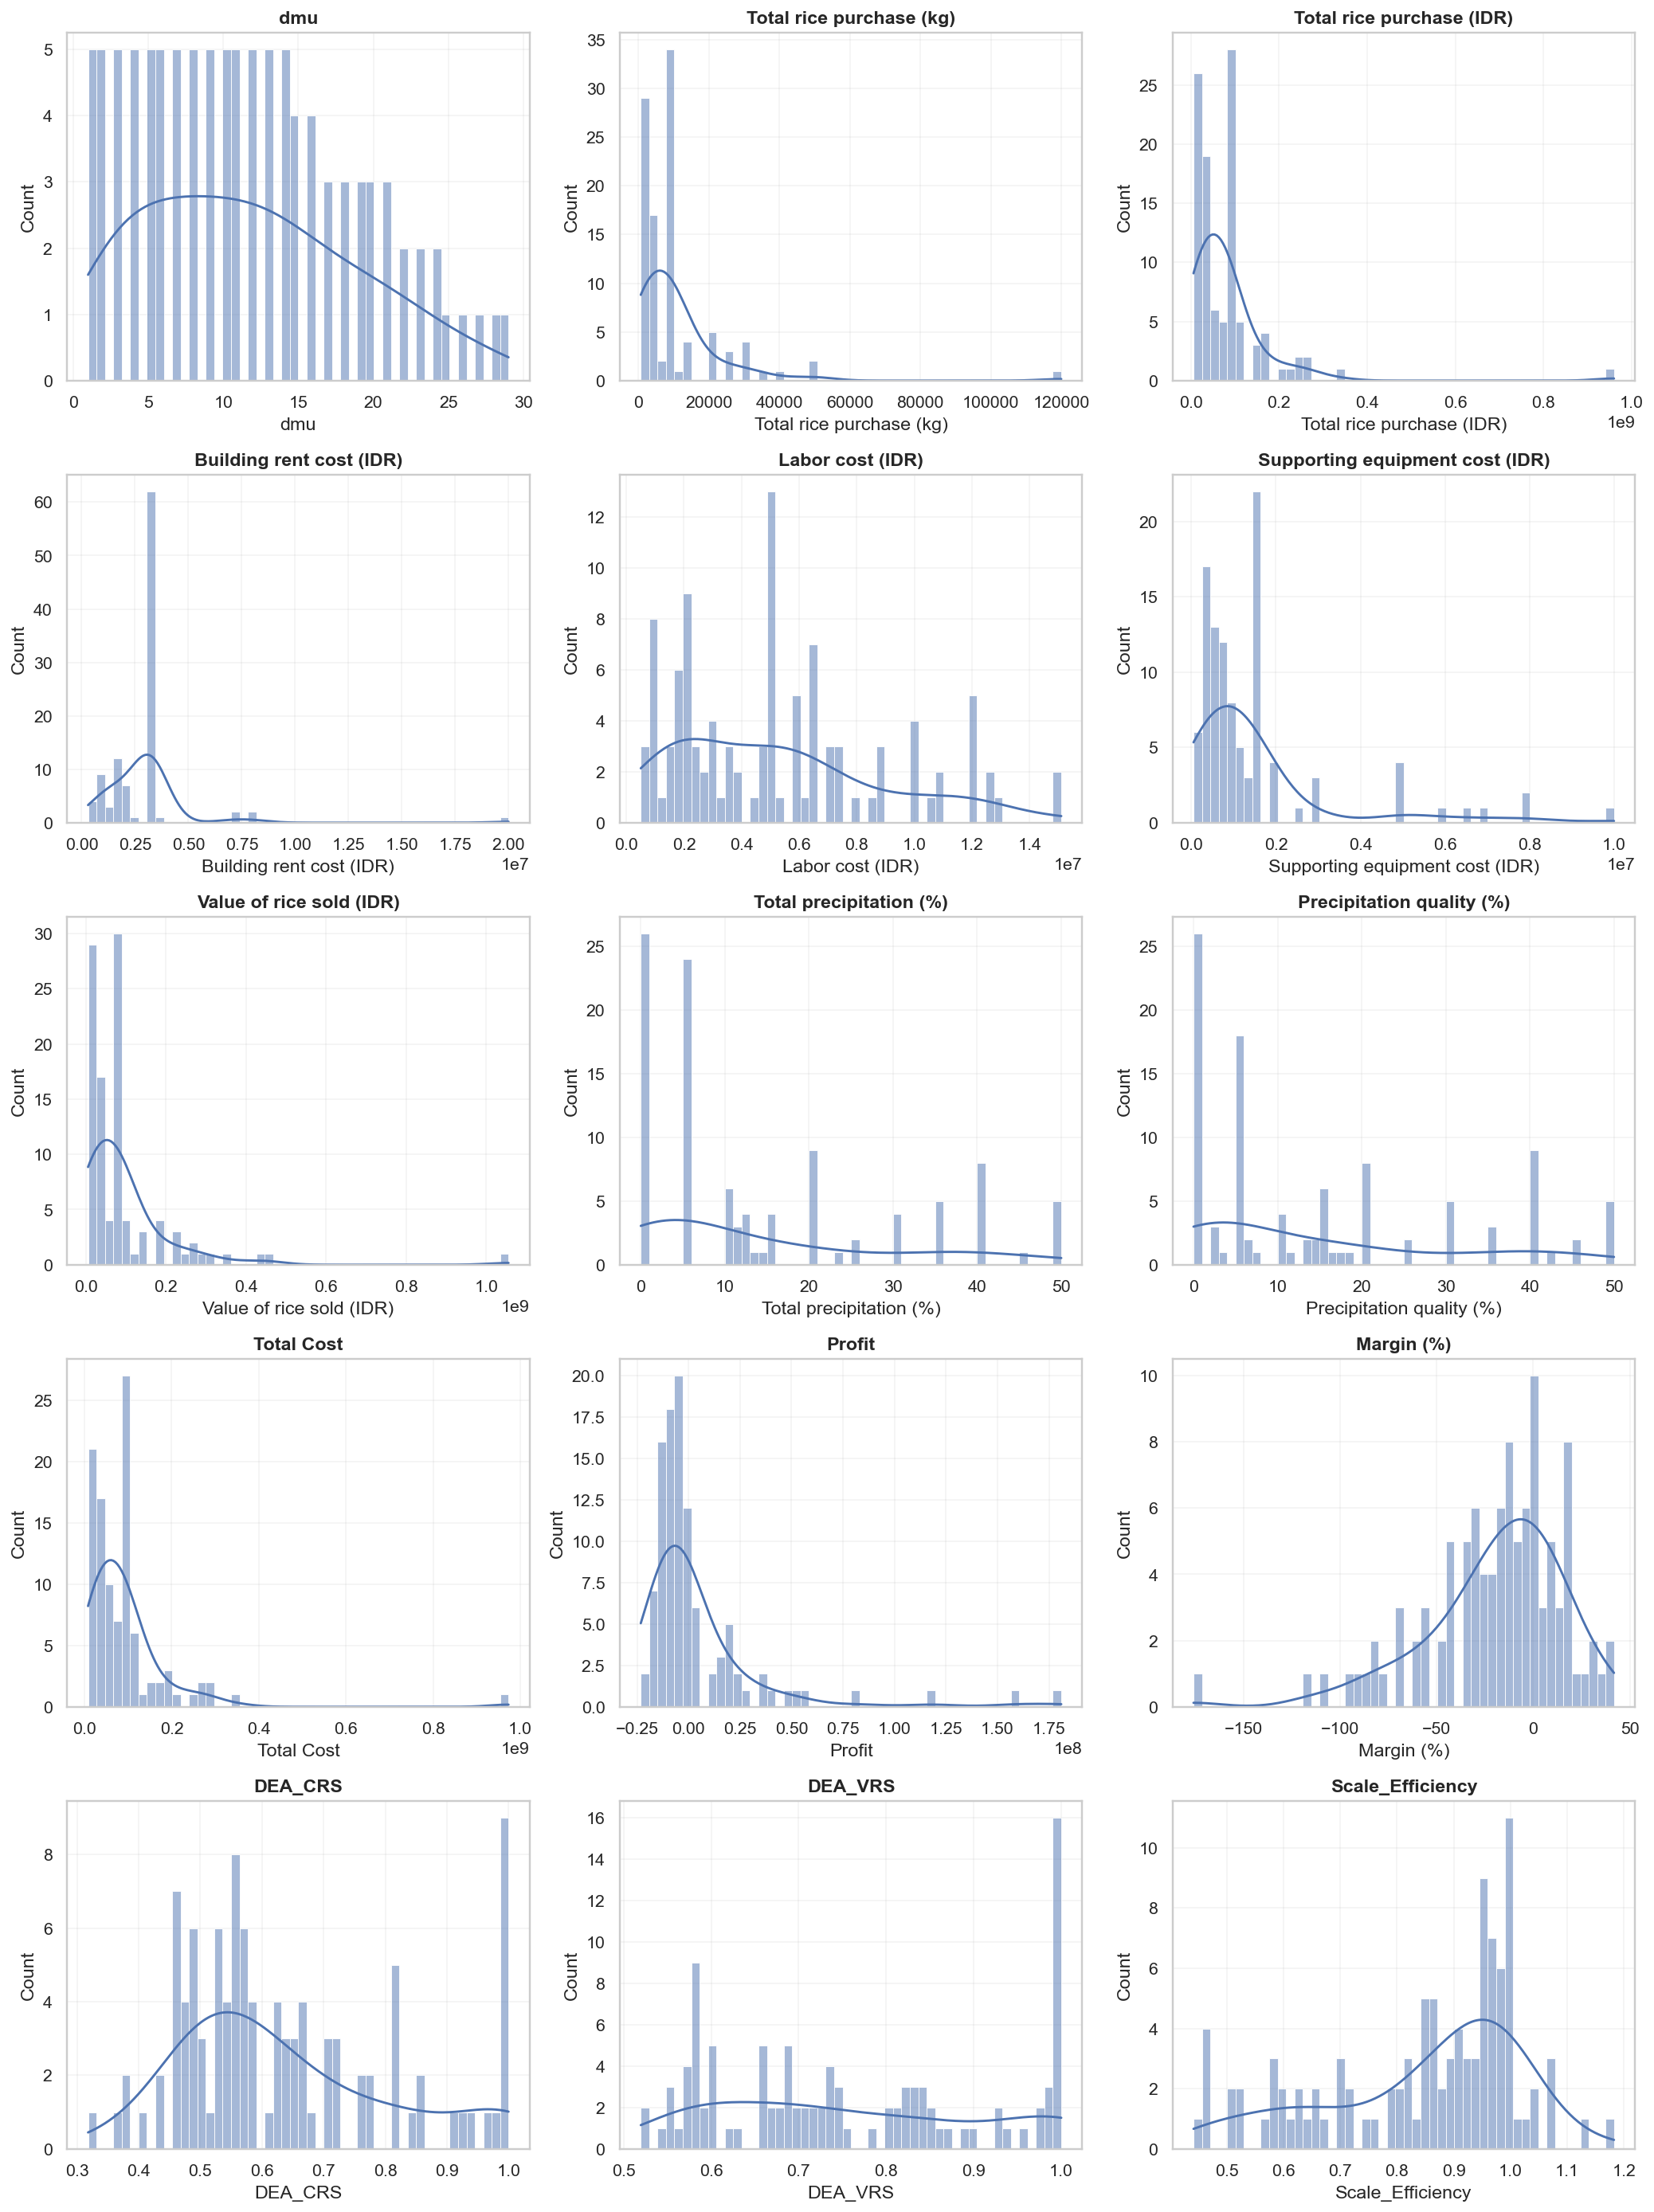

In [ ]:
# Check the distribution 
num_cols = df_middleman.select_dtypes(include=['float64', 'int64']).columns
rows = (len(num_cols) + 2) // 3  
fig, axs = plt.subplots(rows, 3, figsize=(15, 4*rows))
axs = axs.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df_middleman[col], bins=50, kde=True, ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

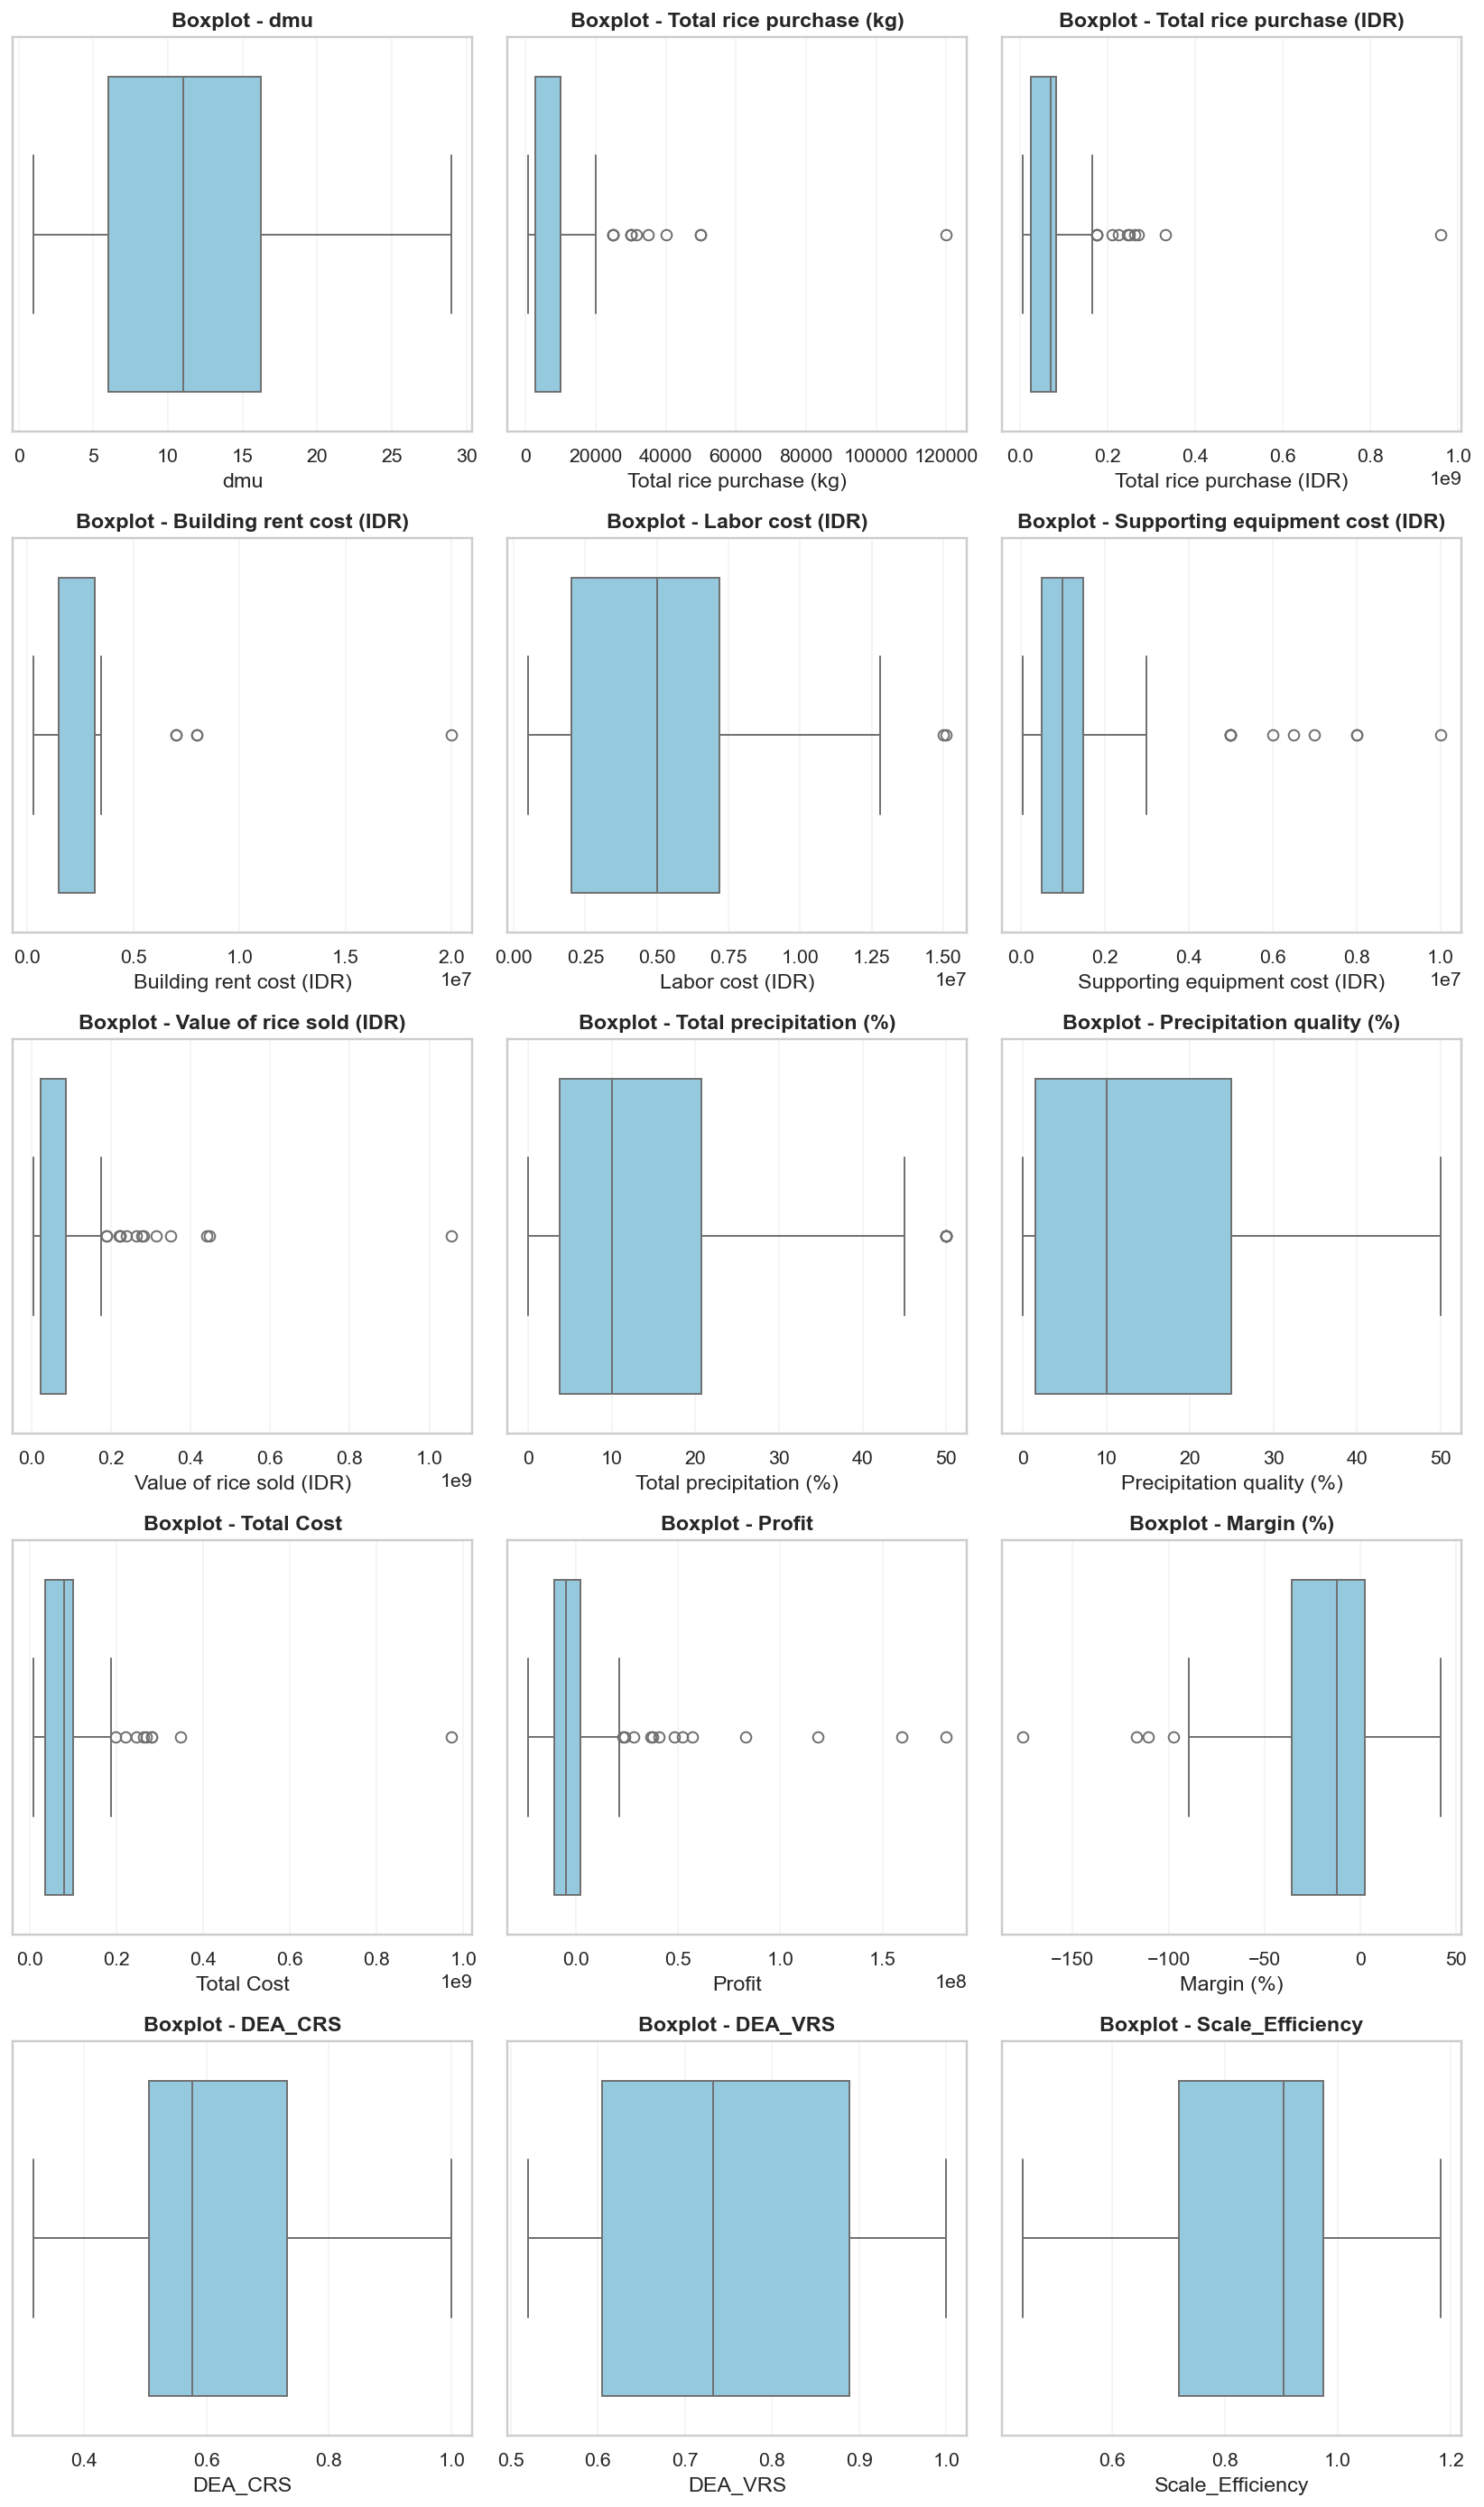

In [ ]:
# Check for outliers in numerical columns with boxplot
n_cols = 3 
n_rows = (len(num_cols) + n_cols - 1) // n_cols 
plt.figure(figsize=(12, 4 * n_rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_middleman[col], color='skyblue')
    plt.title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

### **Middlemen Feature Engineering**

In [ ]:
MIDDLEMEN_COST_COLS = [
    'Building rent cost (IDR)',
    'Labor cost (IDR)',
    'Total rice purchase (IDR)',
    'Supporting equipment cost (IDR)'
]
target_middlemen1 = df_middleman['DEA_VRS']
target_middlemen2 = df_middleman['Value of rice sold (IDR)']
target_middlemen3 = df_middleman['Total precipitation (%)']

In [ ]:
MIDDLE_LABELS = ['sewa_gedung','tk','beli_beras','peralatan']
for col, tag in zip(MIDDLEMEN_COST_COLS, MIDDLE_LABELS):
    df_middleman[f'pct_{tag}'] = df_middleman[col] / df_middleman['Total Cost']

### **Middlemen Preprocessing**

In [ ]:

# return Log transformasi untuk mengurangi skewness
df_middleman['log_scale']          = np.log1p(df_middleman['Total Cost'])
df_middleman['log_rice_kg']         = np.log1p(df_middleman['Total rice purchase (kg)'])
df_middleman['price_per_kg']       = df_middleman['Total rice purchase (IDR)'] / df_middleman['Total rice purchase (kg)'].clip(lower=1)

In [ ]:
# OHE Kabupaten 
df_middleman_enc  = pd.get_dummies(df_middleman, columns=['Kabupaten'], drop_first=False)
OHE_MIDDLE = [c for c in df_middleman_enc.columns if c.startswith('Kabupaten_')]

MIDDLE_COLS = [f'pct_{t}' for t in MIDDLE_LABELS]
MIDDLE_LOG = ['log_scale','log_rice_kg','price_per_kg']

In [ ]:
# scalling
MIDDLEMAN_CLUSTER_FEATURES = ['log_scale', 'log_rice_kg'] + MIDDLE_COLS

X_cluster_middleman = df_middleman[MIDDLEMAN_CLUSTER_FEATURES].fillna(0)
scaler_cl_middleman = RobustScaler()
X_cl_middleman_scaled = scaler_cl_middleman.fit_transform(X_cluster_middleman)

### **3.1 CUSTERING**

#### **Find Optimal Number of Cluster**

In [ ]:
inertia, sil_scores = [], []
K_RANGE = range(2, 8)
for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_cl_middleman_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cl_middleman_scaled, lbl))
    print(f'  k={k}: inertia={km.inertia_:>10.0f}  silhouette={sil_scores[-1]:.4f}')

best_k = K_RANGE.start + sil_scores.index(max(sil_scores))
print(f'\nOptimal k={best_k} (highest silhouette : {max(sil_scores):.4f})')

  k=2: inertia=       263  silhouette=0.4673
  k=3: inertia=       195  silhouette=0.3195
  k=4: inertia=       159  silhouette=0.3042
  k=5: inertia=       134  silhouette=0.3402
  k=6: inertia=       118  silhouette=0.3287
  k=7: inertia=       103  silhouette=0.2914

Optimal k=2 (highest silhouette : 0.4673)


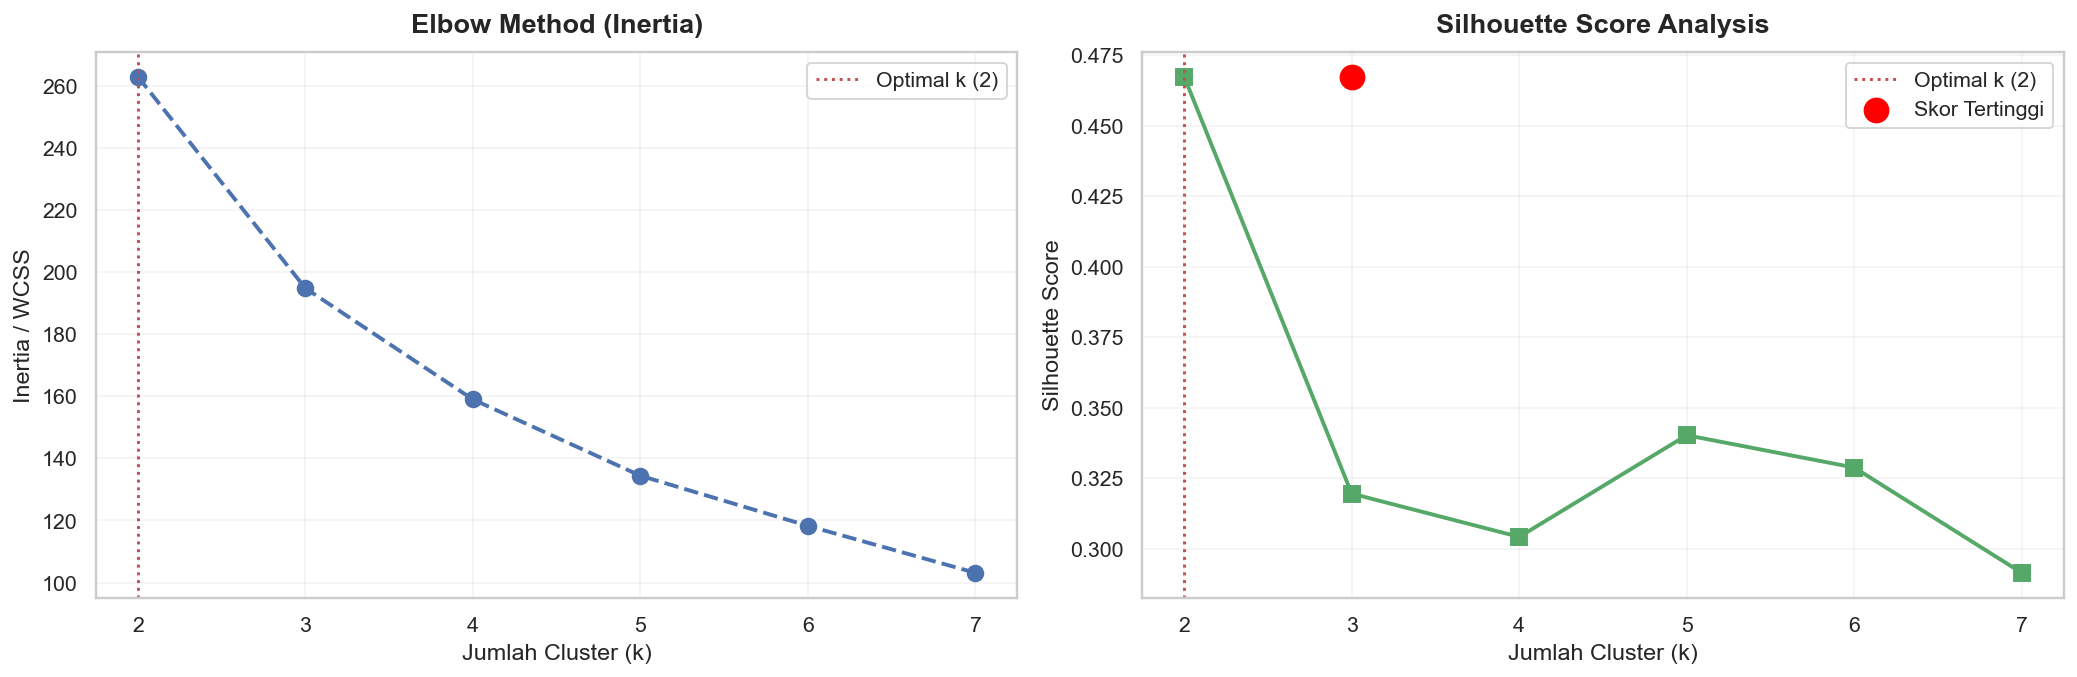

In [ ]:
sns.set_theme(style="whitegrid") 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(K_RANGE, inertia, marker='o', linestyle='--', color='b', linewidth=2, markersize=8)
ax[0].axvline(x=best_k, color='r', linestyle=':', label=f'Optimal k ({best_k})')
ax[0].set_title('Elbow Method (Inertia)', fontsize=14, fontweight='bold', pad=10)
ax[0].set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax[0].set_ylabel('Inertia / WCSS', fontsize=12)
ax[0].set_xticks(K_RANGE)
ax[0].legend()
ax[1].plot(K_RANGE, sil_scores, marker='s', linestyle='-', color='g', linewidth=2, markersize=8)
ax[1].axvline(x=best_k, color='r', linestyle=':', label=f'Optimal k ({best_k})')
ax[1].scatter(3, max(sil_scores), color='red', s=150, zorder=5, label='Skor Tertinggi')
ax[1].set_title('Silhouette Score Analysis', fontsize=14, fontweight='bold', pad=10)
ax[1].set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax[1].set_ylabel('Silhouette Score', fontsize=12)
ax[1].set_xticks(K_RANGE)
ax[1].legend()

plt.tight_layout()
plt.show()

#### **Cluster Model**

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_middleman['cluster'] = kmeans.fit_predict(X_cl_middleman_scaled)
df_middleman_enc['cluster'] = df_middleman['cluster']

cluster_profile = df_middleman.groupby('cluster').agg(
    n_samples    = ('dmu', 'count'),
    avg_budget   = ('Total Cost', 'mean'),
    avg_land_m2  = ('Total rice purchase (kg)', 'mean'),
    avg_dea_vrs  = ('DEA_VRS', 'mean'),
    avg_margin   = ('Margin (%)', 'mean'),
    top_kab      = ('Kabupaten', lambda x: x.mode()[0] if not x.empty else 'N/A'),
).reset_index()

cluster_profile.columns = [
    'Cluster', 'Number of Agents (n)', 'Average Cost (IDR)', 
    'Total Rice Purchase (kg)', 'Efficiency Score (DEA VRS)', 'Margin (%)', 'Dominant "Kabupaten"'
]

print('='*30 + ' PROFILE DATA CLUSTER ' + '='*30)
display(
    cluster_profile.style
    .format({
        'Average Cost (IDR)': 'Rp{:,.2f}'.format,  
        'Total Rice Purchase (kg)': '{:,.1f} kg'.format,
        'Efficiency Score (DEA VRS)': '{:.3f}'.format,
        'Margin (%)': '{:.1f}%'.format
    })
    .background_gradient(cmap='Blues', subset=['Number of Agents (n)', 'Efficiency Score (DEA VRS)'])
    .hide(axis='index')
)

cluster_label_map = {i: f'Kelompok {i}' for i in range(best_k)}
df_middleman['persona'] = df_middleman['cluster'].map(cluster_label_map)
df_middleman_enc['persona'] = df_middleman['persona']

print('\n' + '='*25 + ' DISTRIBUTION CLUSTER PER KABUPATEN ' + '='*25)
crosstab_df = pd.crosstab(df_middleman['Kabupaten'], df_middleman['cluster'])
crosstab_df.columns = [f'Cluster {col}' for col in crosstab_df.columns]

display(
    crosstab_df.style
    .background_gradient(cmap='YlGnBu', axis=1) # Memberikan highlight warna per baris wilayah
)

============================== PROFILE DATA CLUSTER ==============================


Cluster,Number of Agents (n),Average Cost (IDR),Total Rice Purchase (kg),Efficiency Score (DEA VRS),Margin (%),"Dominant ""Kabupaten"""
0,78,"Rp113,462,751.26","13,923.1 kg",0.754,-6.3%,Subang
1,26,"Rp24,242,236.02","1,811.5 kg",0.786,-60.0%,Tasikmalaya



========================= DISTRIBUTION CLUSTER PER KABUPATEN =========================


,Cluster 0,Cluster 1
Kabupaten,,
Garut,13,11
Indramayu,16,0
Karawang,11,3
Subang,21,0
Tasikmalaya,17,12


### **3.2 MODEL 1 MIDDLEMEN (DEA Score)**

In [ ]:
MIDDLE_FEAT_ML1 = MIDDLE_COLS + MIDDLE_LOG + OHE_MIDDLE + ['cluster']

X_ml1_middleman = df_middleman_enc[MIDDLE_FEAT_ML1]
y_ml1_middleman = target_middlemen1  

print(f'X shape : {X_ml1_middleman.shape}')
print(f'Y (DEA_VRS): mean={y_ml1_middleman.mean():.4f}, std={y_ml1_middleman.std():.4f}')

X shape : (104, 13)
Y (DEA_VRS): mean=0.7619, std=0.1561


In [ ]:
# splitting
X_train1_middleman, X_test1_middleman, y_train1_middleman, y_test1_middleman = train_test_split(X_ml1_middleman, y_ml1_middleman, test_size=0.2,random_state=42, stratify = df_middleman['Kabupaten'])

#### **Training Model Middlemen 1**

In [ ]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 6],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
gs_middle_ml1 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=1
)
gs_middle_ml1.fit(X_train1_middleman, y_train1_middleman)
model1_middleman = gs_middle_ml1.best_estimator_

print(f'Best params : {gs_middle_ml1.best_params_}')
print(f'Best CV MAPE: {-gs_middle_ml1.best_score_*100:.2f}%')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best CV MAPE: 9.03%


#### **Evaluate Model Middlemen 1**

In [ ]:
# Evaluasi di test
model1_middleman.fit(X_train1_middleman, y_train1_middleman)
mape_test1 = mean_absolute_percentage_error(
    y_test1_middleman, model1_middleman.predict(X_test1_middleman)
) * 100
print(f'MAPE di Test Set: {mape_test1:.2f}%')

MAPE di Test Set: 5.75%


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_cv_pred = cross_val_predict(model1_middleman, X_ml1_middleman, y_ml1_middleman, cv=kf)

mape1 = mean_absolute_percentage_error(y_ml1_middleman, y_cv_pred) * 100
mae1  = mean_absolute_error(y_ml1_middleman, y_cv_pred)

print('EVALUASI ML MODEL 1 (5-Fold CV):')
print(f'  MAPE : {mape1:.2f}%')
print(f'  MAE  : {mae1:.4f} DEA score points')

model1_middleman.fit(X_ml1_middleman, y_ml1_middleman)

EVALUASI ML MODEL 1 (5-Fold CV):
  MAPE : 8.57%
  MAE  : 0.0653 DEA score points


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

#### **Feature Importance Middlemen Model 1**

In [ ]:
# SHAP Feature Importance
explainer1  = shap.TreeExplainer(model1_middleman)
shap_vals1  = explainer1.shap_values(X_ml1_middleman)
shap_imp1   = pd.Series(
    np.abs(shap_vals1).mean(axis=0),
    index=X_ml1_middleman.columns
).sort_values(ascending=False)

print('SHAP FEATURE IMPORTANCE — ML MODEL 1:')
print(f'{"Rank":<5} {"Fitur":<40} {"SHAP":>8}')
print('─'*56)
for i, (feat, val) in enumerate(shap_imp1.items(), 1):
    bar = '█' * int(val / shap_imp1.max() * 20)
    print(f'{i:<5} {feat:<40} {val:>8.4f}  {bar}')

# Top raw cost features untuk LP
TOP_LP = 4
LP_FEATURES = [f for f in shap_imp1.index if f in MIDDLEMEN_COST_COLS][:TOP_LP]
print(f'\nTop {TOP_LP} fitur LP: {LP_FEATURES}')

SHAP FEATURE IMPORTANCE — ML MODEL 1:
Rank  Fitur                                        SHAP
────────────────────────────────────────────────────────
1     log_scale                                  0.0596  ████████████████████
2     pct_sewa_gedung                            0.0414  █████████████
3     pct_peralatan                              0.0404  █████████████
4     price_per_kg                               0.0318  ██████████
5     pct_beli_beras                             0.0169  █████
6     log_rice_kg                                0.0133  ████
7     pct_tk                                     0.0110  ███
8     Kabupaten_Tasikmalaya                      0.0046  █
9     Kabupaten_Subang                           0.0015  
10    Kabupaten_Karawang                         0.0010  
11    Kabupaten_Garut                            0.0004  
12    Kabupaten_Indramayu                        0.0002  
13    cluster                                    0.0000  

Top 4 fitur LP: []


In [ ]:
shap_df1 = pd.DataFrame(shap_vals1, columns=X_ml1_middleman.columns, index=df_middleman.index)
top5     = shap_imp1.head(5).index.tolist()

print('Contribution SHAP PER CLUSTER (top 5 fitur):')
for cl in sorted(df_middleman['cluster'].unique()):
    mask = df_middleman['cluster'] == cl
    avg  = df_middleman.loc[mask, 'DEA_VRS'].mean()
    
    # Ambil nama cluster dari map, jika tidak ada (seperti indeks 2), gunakan nama default
    cl_name = cluster_label_map.get(cl, f"Cluster Tipe {cl}")
    
    print(f'\nCluster {cl} — {cl_name} (avg DEA={avg:.3f}):')
    
    # Menghitung rata-rata nilai SHAP untuk cluster aktif
    means = shap_df1.loc[mask, top5].mean().sort_values(ascending=False)
    for feat, val in means.items():
        arrow = '↑' if val > 0 else '↓'
        print(f'  {arrow} {feat:<40}: {val:+.4f}')

Contribution SHAP PER CLUSTER (top 5 fitur):

Cluster 0 — Kelompok 0 (avg DEA=0.754):
  ↑ pct_sewa_gedung                         : +0.0083
  ↑ pct_peralatan                           : +0.0067
  ↑ pct_beli_beras                          : +0.0067
  ↑ price_per_kg                            : +0.0057
  ↓ log_scale                               : -0.0303

Cluster 1 — Kelompok 1 (avg DEA=0.786):
  ↑ log_scale                               : +0.0864
  ↓ pct_beli_beras                          : -0.0096
  ↓ pct_peralatan                           : -0.0130
  ↓ price_per_kg                            : -0.0188
  ↓ pct_sewa_gedung                         : -0.0313


### **3.3 LP OPTIMIZATION MIDDLEMEN**

In [ ]:
cfg = CONFIGS['middlemen']
df  = DATA['middlemen']

RESULTS_MIDDLEMEN = run_lp_actor(df, cfg)
print_results(RESULTS_MIDDLEMEN, cfg)

  MIDDLEMEN — 104 DMUs  (Optimal:88 | Efficient:16 | Fallback:0)
═════════════════════════════════════════════════════════════════
COST SAVINGS
     Avg saving      : Rp0.53M  (5.8% reduction)
     Total saving    : Rp0.05B
PROFIT IMPACT
     Before LP       : Rp4.22M avg
     After LP        : Rp4.74M avg
     Avg profit gain : Rp0.53M
     Improved        : 58 / 104
PER-INPUT REDUCTION
     Input                                   Current   After LP     Cut
     -----------------------------------------------------------------
     Labor                                Rp   5.27M  Rp   4.97M    5.7%↓
     Building                             Rp   2.89M  Rp   2.73M    5.7%↓
     Supporting equipment                 Rp   1.51M  Rp   1.45M    4.2%↓
PER KABUPATEN
     Subang          n=21 | DEA_VRS=0.787 | profit_gain=Rp0.83M
     Karawang        n=14 | DEA_VRS=0.708 | profit_gain=Rp0.58M
     Tasikmalaya     n=29 | DEA_VRS=0.758 | profit_gain=Rp0.56M
     Garut           n=24 | DEA_VRS=0.

### **3.4 MODEL 2 MIDDLEMEN (Revenue)**

In [ ]:
MIDDLE_FEAT_ML2 = MIDDLEMEN_COST_COLS  

X_ml2_middleman  = df_middleman[MIDDLE_FEAT_ML2]
y_ml2_middleman   = np.log1p(target_middlemen2)  

print(f'X shape : {X_ml2_middleman.shape}')
print(f'Y (log Revenue): mean={y_ml2_middleman.mean():.4f}, std={y_ml2_middleman.std():.4f}')

X shape : (104, 4)
Y (log Revenue): mean=17.7937, std=1.1105


In [ ]:
X_train2_middleman, X_test2_middleman, y_train2_middleman, y_test2_middleman = train_test_split(X_ml2_middleman, y_ml2_middleman, test_size=0.2, random_state=42, stratify=df_middleman['Kabupaten'])

#### **Training Model Middlemen 2**

In [ ]:
gs_middle_ml2 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=1
)
gs_middle_ml2.fit(X_train2_middleman, y_train2_middleman)
model2_middleman = gs_middle_ml2.best_estimator_

print(f'Best params : {gs_middle_ml2.best_params_}')
print(f'Best CV MAPE: {-gs_middle_ml2.best_score_*100:.2f}%')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}
Best CV MAPE: 0.81%


#### **Evaluate Model Middlemen 2**

In [ ]:
model2_middleman.fit(X_train2_middleman, y_train2_middleman)
mape_test2 = mean_absolute_percentage_error(
    y_test2_middleman, model2_middleman.predict(X_test2_middleman)
) * 100
print(f'MAPE Model 2 di Test Set: {mape_test2:.2f}%')


MAPE Model 2 di Test Set: 0.55%


In [ ]:
y_cv_pred2   = np.expm1(cross_val_predict(model2_middleman, X_ml2_middleman, y_ml2_middleman, cv=kf))
y_orig2      = np.expm1(y_ml2_middleman)
mape2        = mean_absolute_percentage_error(y_orig2, y_cv_pred2) * 100
mae2         = mean_absolute_error(y_orig2, y_cv_pred2)

print('EVALUASI ML MODEL 2 (5-Fold CV):')
print(f'  MAPE : {mape2:.2f}%')
print(f'  MAE  : Rp{mae2/1e6:.2f} juta')
model2_middleman.fit(X_ml2_middleman, y_ml2_middleman)

EVALUASI ML MODEL 2 (5-Fold CV):
  MAPE : 14.32%
  MAE  : Rp17.02 juta


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

#### **Feature Importance Middlemen MOdel 2**

In [ ]:
explainer2 = shap.TreeExplainer(model2_middleman)
shap_vals2 = explainer2.shap_values(X_ml2_middleman)
shap_imp2  = pd.Series(
    np.abs(shap_vals2).mean(axis=0),
    index=X_ml2_middleman.columns
).sort_values(ascending=False)

print('SHAP FEATURE IMPORTANCE — ML MODEL 2 (predict Revenue):')
for i, (feat, val) in enumerate(shap_imp2.items(), 1):
    bar = '█' * int(val / shap_imp2.max() * 20)
    print(f'  {i}. {feat:<45}: {val:.4f}  {bar}')

SHAP FEATURE IMPORTANCE — ML MODEL 2 (predict Revenue):
  1. Total rice purchase (IDR)                    : 0.9070  ████████████████████
  2. Labor cost (IDR)                             : 0.0226  
  3. Building rent cost (IDR)                     : 0.0134  
  4. Supporting equipment cost (IDR)              : 0.0127  


## **4. WHOLESALER**

### **Short Analysis**

In [ ]:
df_wholesaler.describe().T

,count,mean,std,min,25%,50%,75%,max
dmu,104.0,1.156731e+01,7.067998e+00,1.000000e+00,6.000000e+00,1.100000e+01,1.625000e+01,2.800000e+01
Value of rice purchase (IDR),104.0,3.927594e+08,1.085303e+09,9.000000e+06,8.850000e+07,1.140000e+08,1.977500e+08,8.000000e+09
Building rent cost (IDR),104.0,5.866827e+06,5.874408e+06,1.500000e+06,4.000000e+06,4.000000e+06,5.000000e+06,3.600000e+07
Labor cost (IDR),104.0,8.799615e+06,7.000109e+06,2.000000e+05,4.725000e+06,8.000000e+06,1.012500e+07,4.056000e+07
Supporting equipment cost (IDR),104.0,7.926923e+06,1.942555e+07,2.000000e+05,1.500000e+06,3.000000e+06,6.175000e+06,1.750000e+08
Precipitation quality (%),104.0,1.529808e+01,1.581500e+01,0.000000e+00,5.000000e+00,1.000000e+01,2.000000e+01,5.000000e+01
Value of rice sold (IDR),104.0,6.474138e+08,1.513288e+09,9.000000e+06,9.975000e+07,1.800000e+08,4.850000e+08,1.050000e+10
Total Cost,104.0,4.153528e+08,1.103946e+09,2.020000e+07,1.018750e+08,1.428000e+08,2.332000e+08,8.212000e+09
Profit,104.0,2.320610e+08,6.718136e+08,-5.505000e+08,-9.012500e+06,2.000000e+07,1.371500e+08,5.161000e+09
Margin (%),104.0,-8.779118e+00,1.244740e+02,-8.555000e+02,-8.743687e+00,6.101010e+00,4.169444e+01,9.752457e+01


In [ ]:
print('PROFITABILITAS WHOLESALER PER KABUPATEN:')
eda = df_wholesaler.groupby('Kabupaten').agg(
    n               = ('dmu',        'count'),
    pct_untung      = ('Profit',      lambda x: f"{(x>0).mean()*100:.1f}%"),
    margin_avg      = ('Margin (%)',  lambda x: f"{x.mean():.1f}%"),
    dea_vrs_avg     = ('DEA_VRS',     lambda x: f"{x.mean():.3f}"),
    dea_frontier    = ('DEA_VRS',     lambda x: f"{(x>=0.999).sum()}"),
    scale_eff_avg   = ('Scale_Efficiency', lambda x: f"{x.mean():.3f}"),
).reset_index()
print(eda.to_string(index=False))

PROFITABILITAS WHOLESALER PER KABUPATEN:
  Kabupaten  n pct_untung margin_avg dea_vrs_avg dea_frontier scale_eff_avg
      Garut 25      28.0%     -72.6%       0.628            6         0.134
  Indramayu 16     100.0%      30.9%       0.606            4         0.483
   Karawang 14      42.9%     -11.7%       0.541            1         0.337
     Subang 21      85.7%       6.9%       0.595            4         0.296
Tasikmalaya 28      50.0%      15.2%       0.600            1         0.244


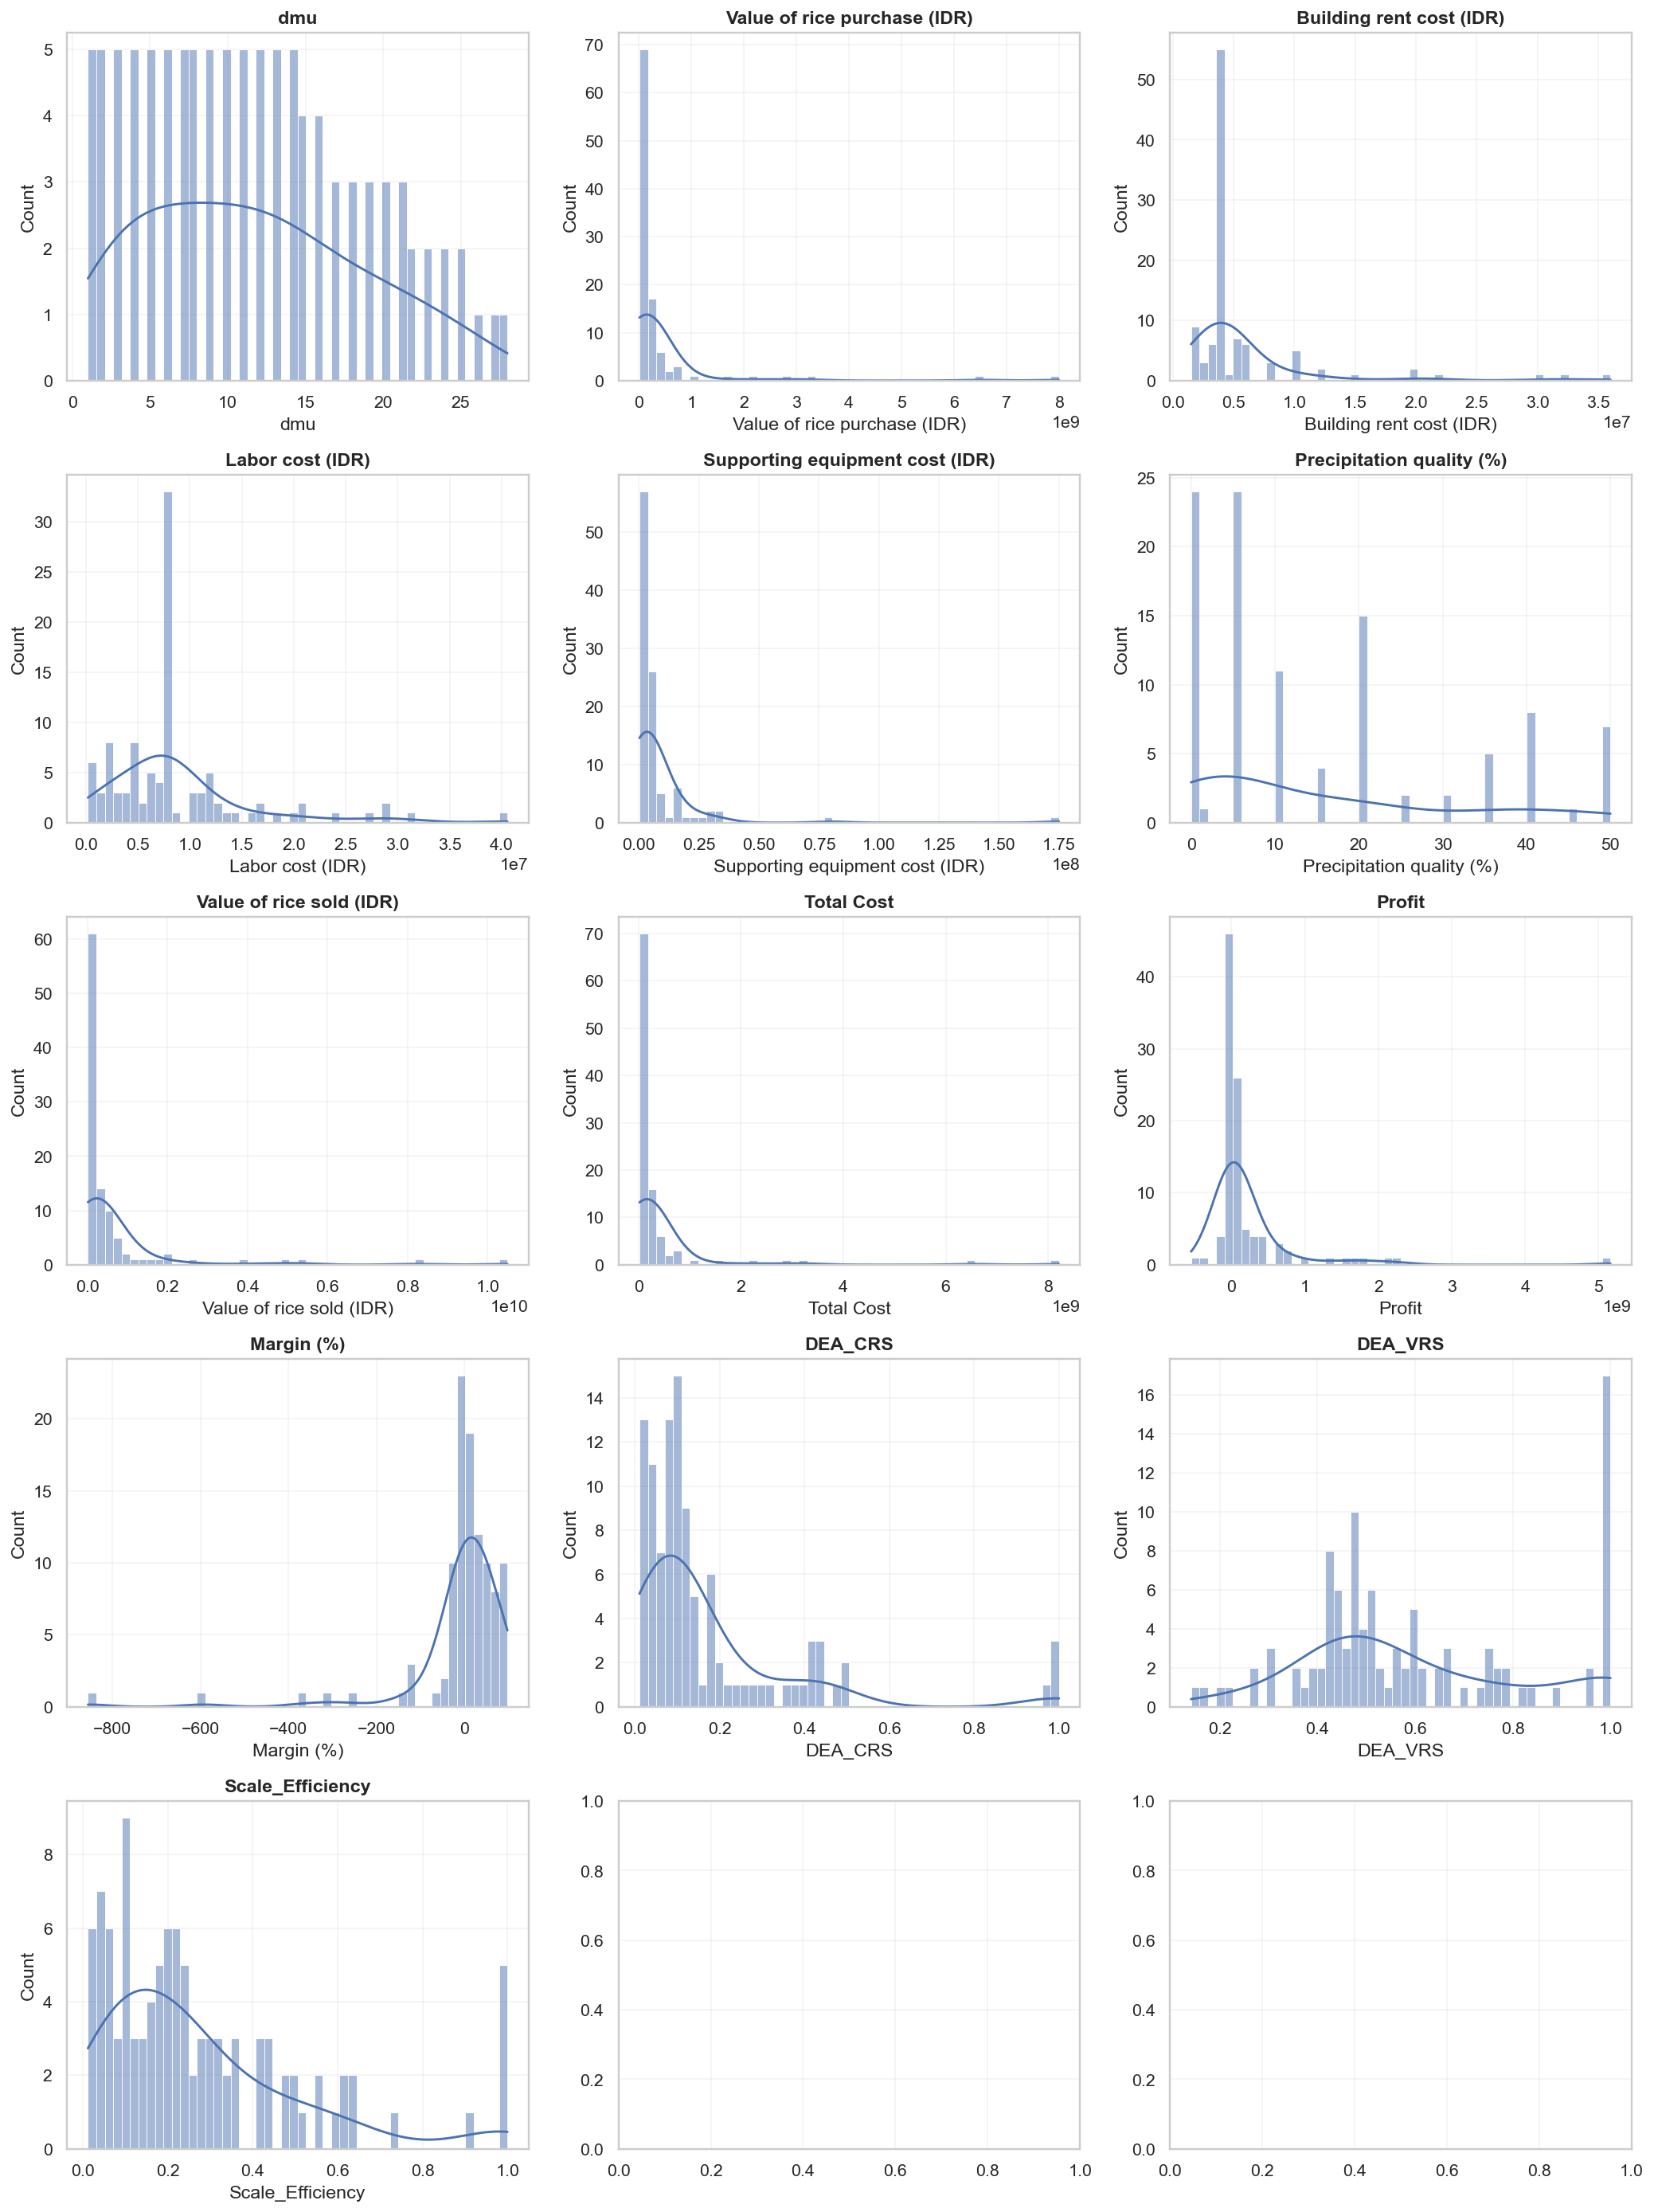

In [ ]:
# Check the distribution 
num_cols = df_wholesaler.select_dtypes(include=['float64', 'int64']).columns
rows = (len(num_cols) + 2) // 3  
fig, axs = plt.subplots(rows, 3, figsize=(15, 4*rows))
axs = axs.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df_wholesaler[col], bins=50, kde=True, ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

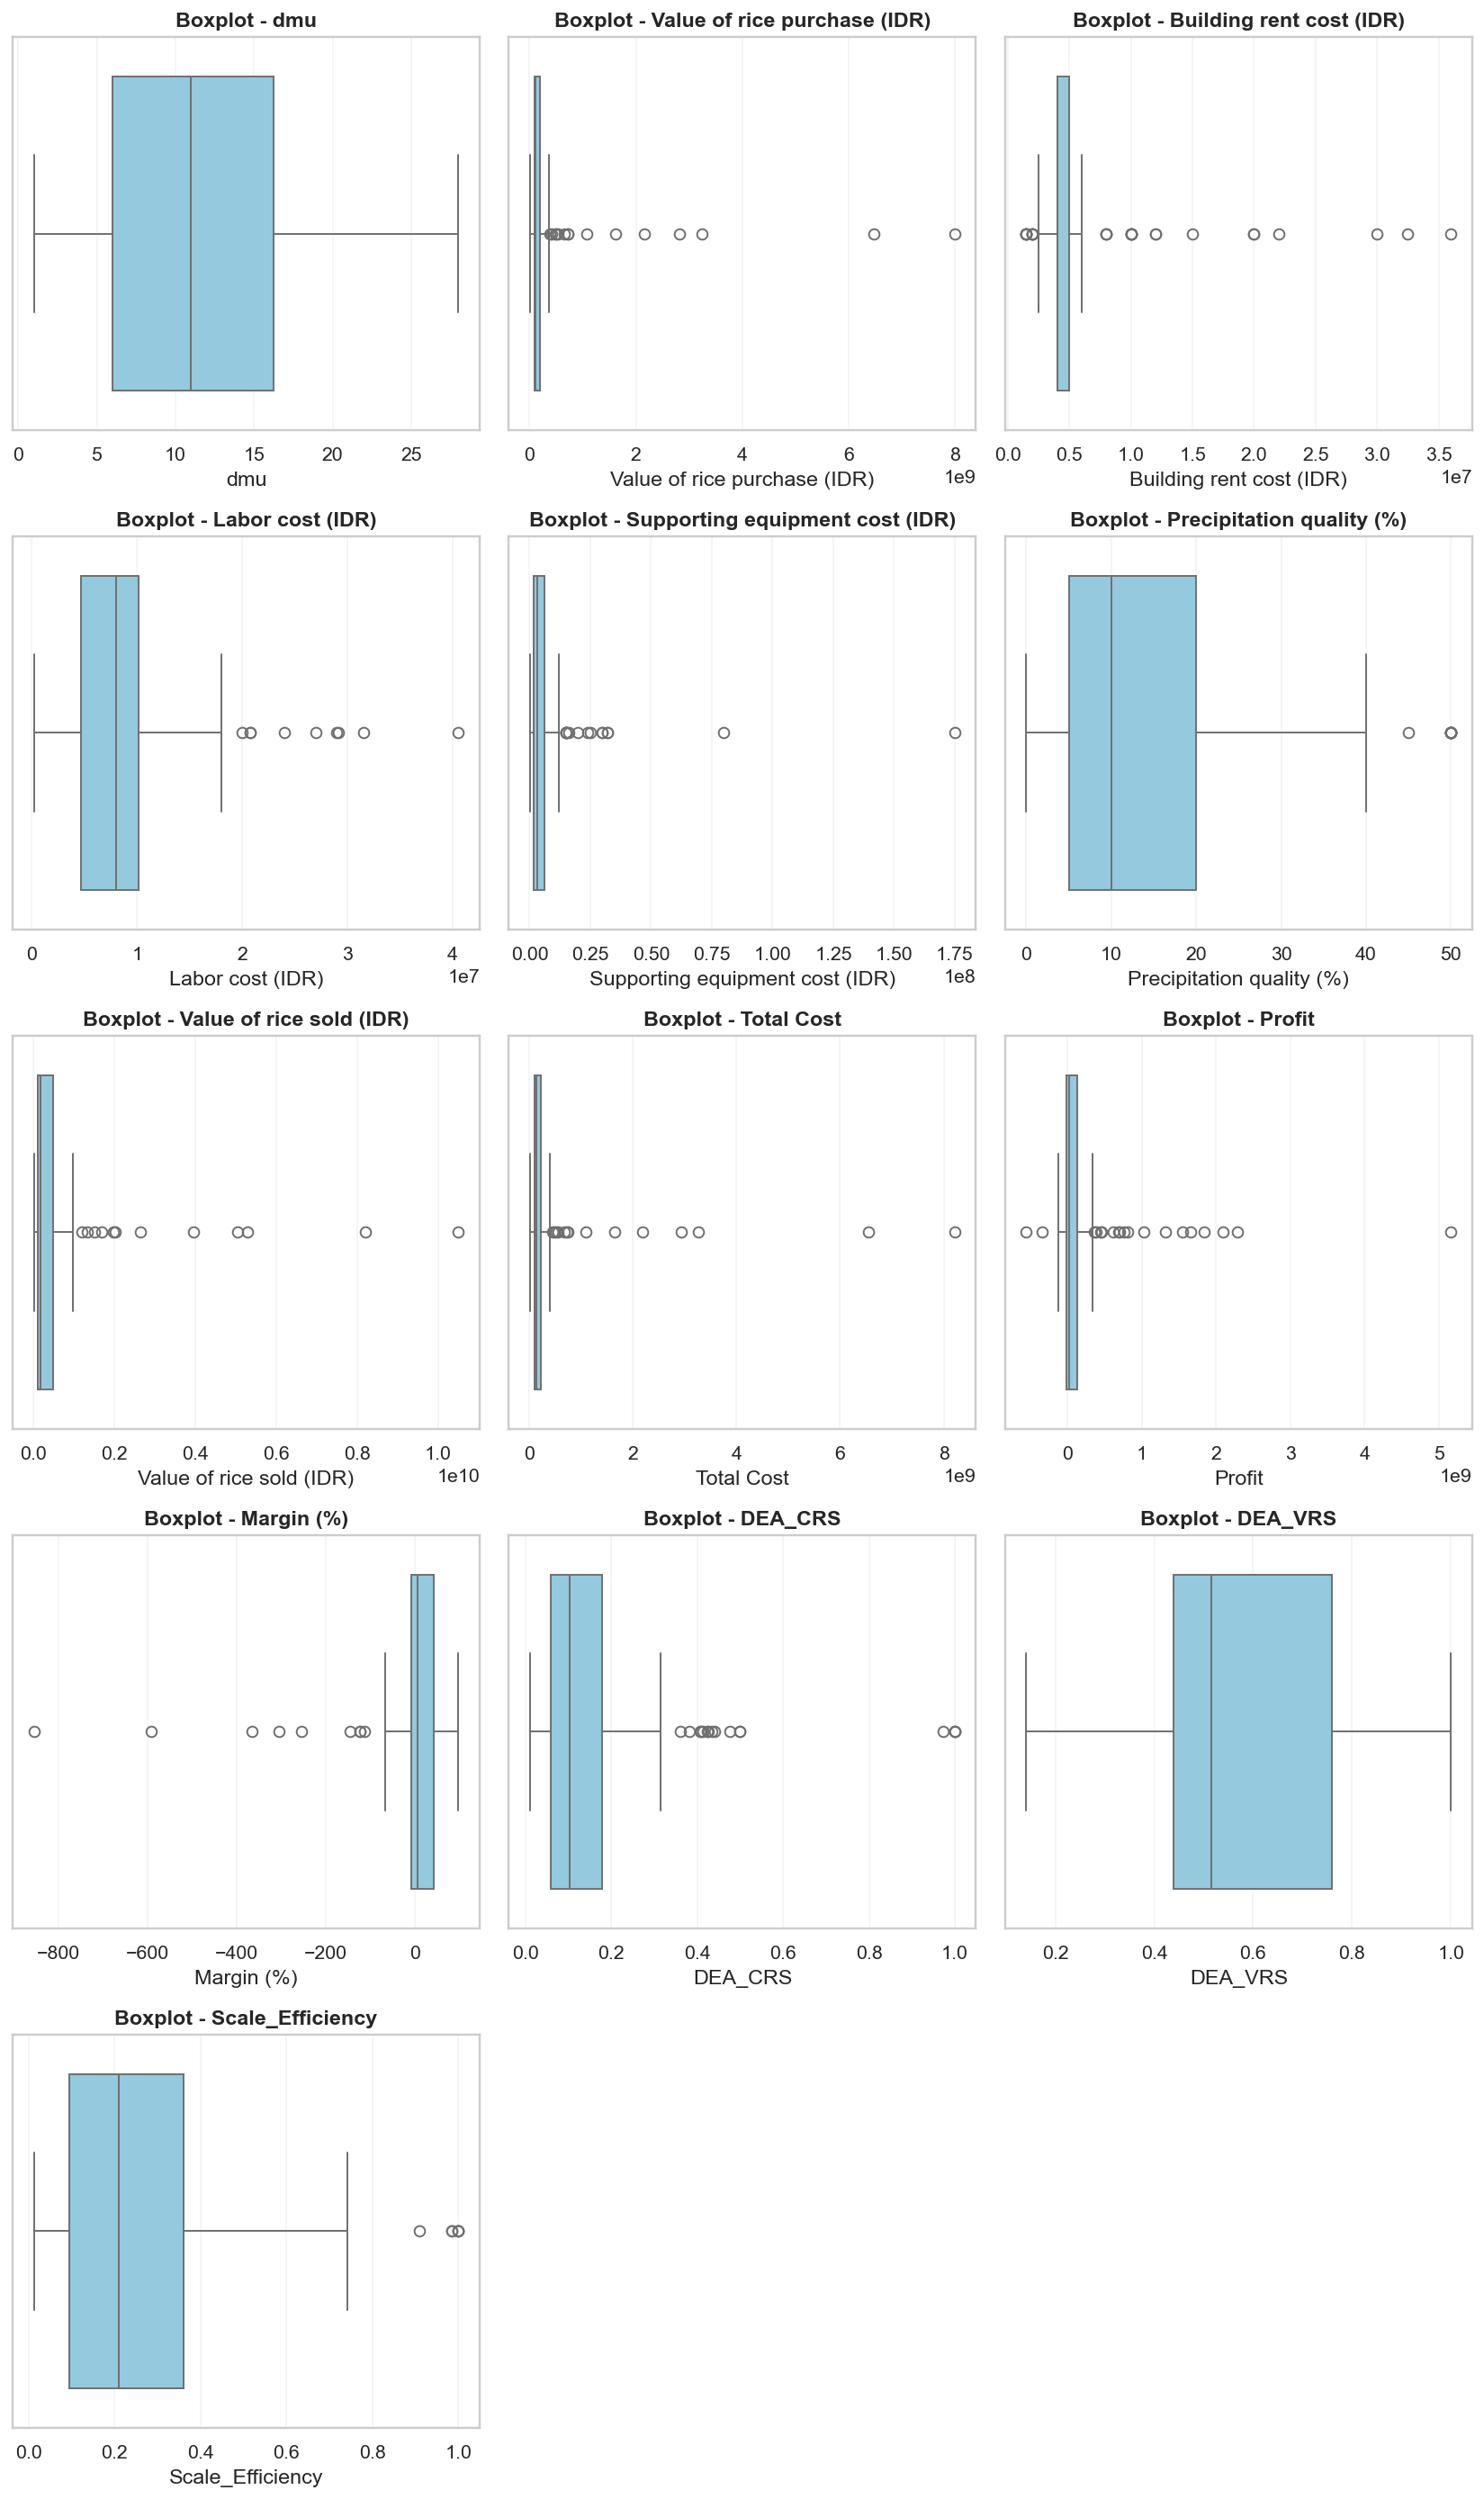

In [ ]:
# Check for outliers in numerical columns with boxplot
n_cols = 3 
n_rows = (len(num_cols) + n_cols - 1) // n_cols 
plt.figure(figsize=(12, 4 * n_rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_wholesaler[col], color='skyblue')
    plt.title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

### **Wholesaler Feature Engineering**

In [ ]:
WHOLESALE_COST_COLS = [
    'Value of rice purchase (IDR)',
    'Labor cost (IDR)',
    'Building rent cost (IDR)',
    'Supporting equipment cost (IDR)'	
]
target_wholesaler1 = df_wholesaler['DEA_VRS']
target_wholesaler2 = df_wholesaler['Value of rice sold (IDR)']

In [ ]:
WHOLESALE_LABELS = ['beli_beras','tk','sewa_gedung','peralatan']
for col, tag in zip(WHOLESALE_COST_COLS, WHOLESALE_LABELS):
    df_wholesaler[f'pct_{tag}'] = df_wholesaler[col] / df_wholesaler['Total Cost']

### **Wholesaler Preprocessing**

In [ ]:
df_wholesaler['log_scale']  = np.log1p(df_wholesaler['Total Cost'])

In [ ]:
# OHE
df_wholesaler_enc = pd.get_dummies(df_wholesaler, columns=['Kabupaten'], drop_first=False)
OHE_GROSIR = [c for c in df_wholesaler_enc.columns if c.startswith('Kabupaten_')]

WHOLESALE_COLS = [f'pct_{t}' for t in WHOLESALE_LABELS]
LOG_COLS = ['log_scale']

### **4.1 MODEL 1 WHOLESALER (DEA Score)**

In [ ]:
WHOLESALE_FEAT_ML1 = WHOLESALE_COLS + LOG_COLS + OHE_GROSIR 

X_ml1_wholesaler = df_wholesaler_enc[WHOLESALE_FEAT_ML1]
y_ml1_wholesaler= target_wholesaler1  

print(f'X shape : {X_ml1_wholesaler.shape}')
print(f'Y (DEA_VRS): mean={y_ml1_wholesaler.mean():.4f}, std={y_ml1_wholesaler.std():.4f}')

X shape : (104, 10)
Y (DEA_VRS): mean=0.5986, std=0.2342


In [ ]:
# splitting
X_train1_wholesaler, X_test1_wholesaler, y_train1_wholesaler, y_test1_wholesaler = train_test_split(X_ml1_wholesaler, y_ml1_wholesaler, test_size=0.2,random_state=42, stratify=df_wholesaler['Kabupaten'])

#### **Training Model Wholesaler 1**

In [ ]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 6],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
gs_wholesaler_ml1 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=1
)
gs_wholesaler_ml1.fit(X_train1_wholesaler, y_train1_wholesaler)
model1_wholesaler = gs_wholesaler_ml1.best_estimator_

print(f'Best params : {gs_wholesaler_ml1.best_params_}')
print(f'Best CV MAPE: {-gs_wholesaler_ml1.best_score_*100:.2f}%')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best CV MAPE: 23.31%


#### **Evaluate Model 1 Wholesaler**

In [ ]:
model1_wholesaler.fit(X_train1_wholesaler, y_train1_wholesaler)
mape_test1 = mean_absolute_percentage_error(
    y_test1_wholesaler, model1_wholesaler.predict(X_test1_wholesaler)
) * 100
print(f'MAPE di Test Set: {mape_test1:.2f}%')

MAPE di Test Set: 22.58%


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_cv_pred = cross_val_predict(model1_wholesaler, X_ml1_wholesaler, y_ml1_wholesaler, cv=kf)

mape1 = mean_absolute_percentage_error(y_ml1_wholesaler, y_cv_pred) * 100
mae1  = mean_absolute_error(y_ml1_wholesaler, y_cv_pred)

print('EVALUASI ML MODEL 1 (5-Fold CV):')
print(f'  MAPE : {mape1:.2f}%')
print(f'  MAE  : {mae1:.4f} DEA score points')

model1_wholesaler.fit(X_ml1_wholesaler, y_ml1_wholesaler)

EVALUASI ML MODEL 1 (5-Fold CV):
  MAPE : 23.42%
  MAE  : 0.1254 DEA score points


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

#### **Feature Importance Model 1 Wholesaler**

In [ ]:
# SHAP Feature Importance
explainer1  = shap.TreeExplainer(model1_wholesaler)
shap_vals1  = explainer1.shap_values(X_ml1_wholesaler)
shap_imp1   = pd.Series(
    np.abs(shap_vals1).mean(axis=0),
    index=X_ml1_wholesaler.columns
).sort_values(ascending=False)

print('SHAP FEATURE IMPORTANCE — ML MODEL 1:')
print(f'{"Rank":<5} {"Fitur":<40} {"SHAP":>8}')
print('─'*56)
for i, (feat, val) in enumerate(shap_imp1.items(), 1):
    bar = '█' * int(val / shap_imp1.max() * 20)
    print(f'{i:<5} {feat:<40} {val:>8.4f}  {bar}')

# Top raw cost features untuk LP
TOP_LP = 4
LP_FEATURES = [f for f in shap_imp1.index if f in WHOLESALE_COST_COLS][:TOP_LP]
print(f'\nTop {TOP_LP} fitur LP: {LP_FEATURES}')

SHAP FEATURE IMPORTANCE — ML MODEL 1:
Rank  Fitur                                        SHAP
────────────────────────────────────────────────────────
1     log_scale                                  0.1613  ████████████████████
2     pct_sewa_gedung                            0.1133  ██████████████
3     pct_tk                                     0.0311  ███
4     pct_peralatan                              0.0309  ███
5     pct_beli_beras                             0.0217  ██
6     Kabupaten_Tasikmalaya                      0.0061  
7     Kabupaten_Garut                            0.0028  
8     Kabupaten_Karawang                         0.0022  
9     Kabupaten_Indramayu                        0.0004  
10    Kabupaten_Subang                           0.0002  

Top 4 fitur LP: []


### **4.2 LP OPTIMIZATION WHOLESALER**

In [ ]:
cfg = CONFIGS['wholesaler']
df  = DATA['wholesaler']

RESULTS_WHOLESALER = run_lp_actor(df, cfg)
print_results(RESULTS_WHOLESALER, cfg)

  WHOLESALER — 104 DMUs  (Optimal:88 | Efficient:16 | Fallback:0)
═════════════════════════════════════════════════════════════════
COST SAVINGS
     Avg saving      : Rp0.70M  (3.7% reduction)
     Total saving    : Rp0.07B
PROFIT IMPACT
     Before LP       : Rp232.06M avg
     After LP        : Rp232.76M avg
     Avg profit gain : Rp0.70M
     Improved        : 60 / 104
PER-INPUT REDUCTION
     Input                                   Current   After LP     Cut
     -----------------------------------------------------------------
     Supporting equipment                 Rp   7.93M  Rp   7.77M    1.9%↓
     Labor                                Rp   8.80M  Rp   8.38M    4.8%↓
     Building                             Rp   5.87M  Rp   5.74M    2.1%↓
PER KABUPATEN
     Karawang        n=14 | DEA_VRS=0.541 | profit_gain=Rp0.98M
     Subang          n=21 | DEA_VRS=0.595 | profit_gain=Rp0.86M
     Tasikmalaya     n=28 | DEA_VRS=0.600 | profit_gain=Rp0.77M
     Indramayu       n=16 | DEA_V

### **4.3 MODEL 2 WHOLESALER (Revenue)**

In [ ]:
WHOLESALE_FEAT_ML2 = WHOLESALE_COST_COLS  

X_ml2_wholesaler  = df_wholesaler[WHOLESALE_FEAT_ML2]
y_ml2_wholesaler   = np.log1p(target_wholesaler2) 

print(f'X shape : {X_ml2_wholesaler.shape}')
print(f'Y (log Revenue): mean={y_ml2_wholesaler.mean():.4f}, std={y_ml2_wholesaler.std():.4f}')

X shape : (104, 4)
Y (log Revenue): mean=19.1826, std=1.3895


In [ ]:
X_train2_wholesaler, X_test2_wholesaler, y_train2_wholesaler, y_test2_wholesaler = train_test_split(X_ml2_wholesaler, y_ml2_wholesaler, test_size=0.2, random_state=42)

#### **Training Model 2 Wholesaler**

In [ ]:
gs_wholesale_ml2 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=1
)
gs_wholesale_ml2.fit(X_train2_wholesaler, y_train2_wholesaler)
model2_wholesaler = gs_wholesale_ml2.best_estimator_

print(f'Best params : {gs_wholesale_ml2.best_params_}')
print(f'Best CV MAPE: {-gs_wholesale_ml2.best_score_*100:.2f}%')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best CV MAPE: 3.33%


#### **Evaluate MOdel 2 Wholesaler**

In [ ]:
model2_wholesaler.fit(X_train2_wholesaler, y_train2_wholesaler)
mape_test2 = mean_absolute_percentage_error(
    y_test2_wholesaler, model2_wholesaler.predict(X_test2_wholesaler)
) * 100
print(f'MAPE Model 2 di Test Set: {mape_test2:.2f}%')


MAPE Model 2 di Test Set: 2.90%


In [ ]:
y_cv_pred2   = np.expm1(cross_val_predict(model2_wholesaler, X_ml2_wholesaler, y_ml2_wholesaler, cv=kf))
y_orig2      = np.expm1(y_ml2_wholesaler)
mape2        = mean_absolute_percentage_error(y_orig2, y_cv_pred2) * 100
mae2         = mean_absolute_error(y_orig2, y_cv_pred2)

print('EVALUASI ML MODEL 2 (5-Fold CV):')
print(f'  MAPE : {mape2:.2f}%')
print(f'  MAE  : Rp{mae2/1e6:.2f} juta')


model2_wholesaler.fit(X_ml2_wholesaler, y_ml2_wholesaler)

EVALUASI ML MODEL 2 (5-Fold CV):
  MAPE : 104.06%
  MAE  : Rp381.78 juta


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

#### **Feature Importance Model 2 Wholesale**

In [ ]:
# SHAP ML2 — fitur apa yang paling drive revenue?
explainer2 = shap.TreeExplainer(model2_wholesaler)
shap_vals2 = explainer2.shap_values(X_ml2_wholesaler)
shap_imp2  = pd.Series(
    np.abs(shap_vals2).mean(axis=0),
    index=X_ml2_wholesaler.columns
).sort_values(ascending=False)

print('SHAP FEATURE IMPORTANCE — ML MODEL 2 (predict Revenue):')
for i, (feat, val) in enumerate(shap_imp2.items(), 1):
    bar = '█' * int(val / shap_imp2.max() * 20)
    print(f'  {i}. {feat:<45}: {val:.4f}  {bar}')

SHAP FEATURE IMPORTANCE — ML MODEL 2 (predict Revenue):
  1. Value of rice purchase (IDR)                 : 0.5304  ████████████████████
  2. Supporting equipment cost (IDR)              : 0.4696  █████████████████
  3. Labor cost (IDR)                             : 0.1700  ██████
  4. Building rent cost (IDR)                     : 0.0958  ███


## **5. RETAIL**

### **Short Analysis**

In [ ]:
df_retail.describe().T

,count,mean,std,min,25%,50%,75%,max
dmu,102.0,1.121569e+01,6.799283e+00,1.000000e+00,6.000000e+00,1.100000e+01,1.600000e+01,2.800000e+01
Value of rice purchase (IDR),102.0,2.450515e+06,3.899083e+05,5.850000e+05,2.450000e+06,2.612500e+06,2.695000e+06,3.240000e+06
Building rent cost (IDR),102.0,1.874510e+05,5.725894e+04,5.000000e+04,1.500000e+05,2.000000e+05,2.000000e+05,4.800000e+05
Labor cost (IDR),102.0,2.676961e+06,9.580217e+05,2.000000e+05,3.000000e+06,3.000000e+06,3.000000e+06,5.600000e+06
Supporting equipment cost (IDR),102.0,2.041569e+05,9.763569e+04,3.000000e+04,1.500000e+05,2.000000e+05,3.000000e+05,5.000000e+05
Value of rice sold (IDR),102.0,2.923157e+06,4.989611e+05,7.000000e+05,3.000000e+06,3.000000e+06,3.000000e+06,3.600000e+06
Precipitation quality (%),102.0,1.269608e-01,1.109526e-01,5.000000e-02,5.000000e-02,1.000000e-01,1.500000e-01,4.500000e-01
Total Cost,102.0,5.519083e+06,1.050097e+06,2.100000e+06,5.106250e+06,5.887500e+06,6.095000e+06,7.960000e+06
Profit,102.0,-2.595926e+06,9.728746e+05,-4.960000e+06,-3.145000e+06,-2.885000e+06,-2.270000e+06,1.900000e+05
Margin (%),102.0,-9.443242e+01,5.266662e+01,-4.295714e+02,-1.091417e+02,-9.729167e+01,-7.192472e+01,6.333333e+00


In [ ]:
print('PROFITABILITAS RETAIL PER KABUPATEN:')
eda = df_retail.groupby('Kabupaten').agg(
    n               = ('dmu',        'count'),
    pct_untung      = ('Profit',      lambda x: f"{(x>0).mean()*100:.1f}%"),
    margin_avg      = ('Margin (%)',  lambda x: f"{x.mean():.1f}%"),
    dea_vrs_avg     = ('DEA_VRS',     lambda x: f"{x.mean():.3f}"),
    dea_frontier    = ('DEA_VRS',     lambda x: f"{(x>=0.999).sum()}"),
    scale_eff_avg   = ('Scale_Efficiency', lambda x: f"{x.mean():.3f}"),
).reset_index()
print(eda.to_string(index=False))

PROFITABILITAS RETAIL PER KABUPATEN:
  Kabupaten  n pct_untung margin_avg dea_vrs_avg dea_frontier scale_eff_avg
      Garut 23       8.7%     -67.0%       0.937            9         0.979
  Indramayu 16       0.0%    -125.7%       0.825            3         0.932
   Karawang 16       0.0%    -105.9%       0.809            2         0.956
     Subang 19       5.3%     -80.4%       0.904            8         0.946
Tasikmalaya 28       0.0%    -102.0%       0.767            0         0.969


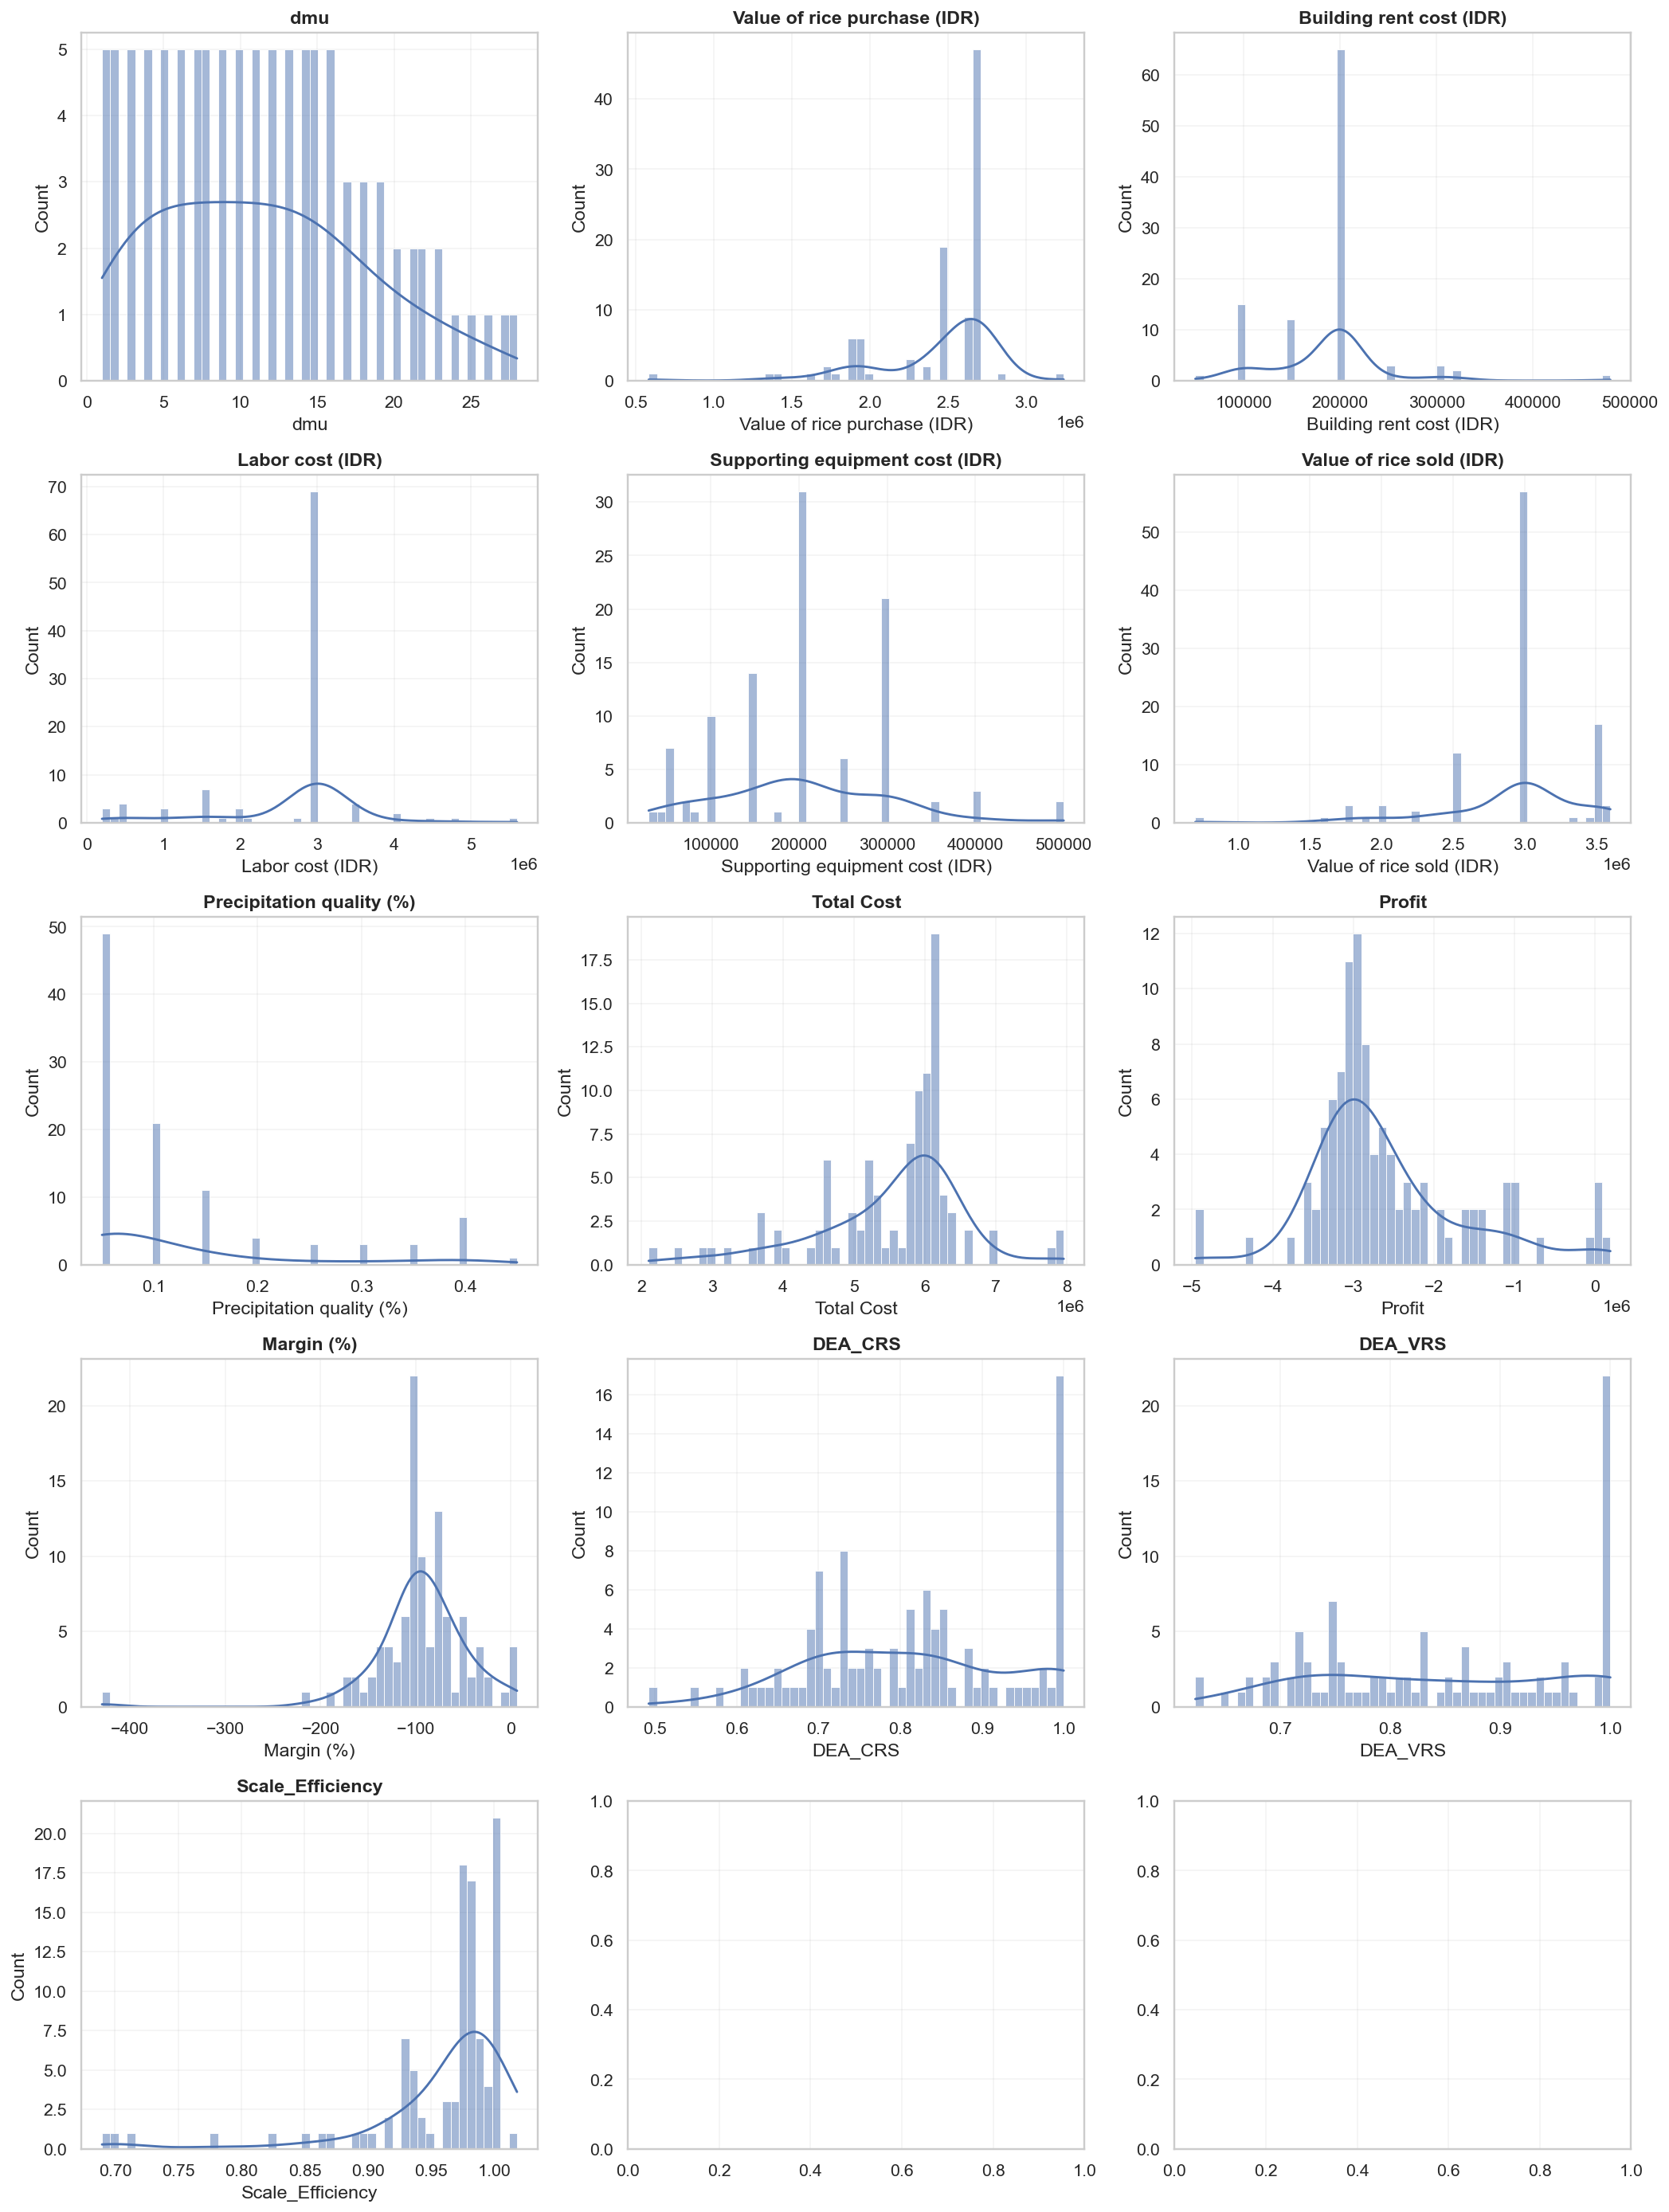

In [ ]:
# Check the distribution 
num_cols = df_retail.select_dtypes(include=['float64', 'int64']).columns
rows = (len(num_cols) + 2) // 3  
fig, axs = plt.subplots(rows, 3, figsize=(15, 4*rows))
axs = axs.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df_retail[col], bins=50, kde=True, ax=axs[i])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

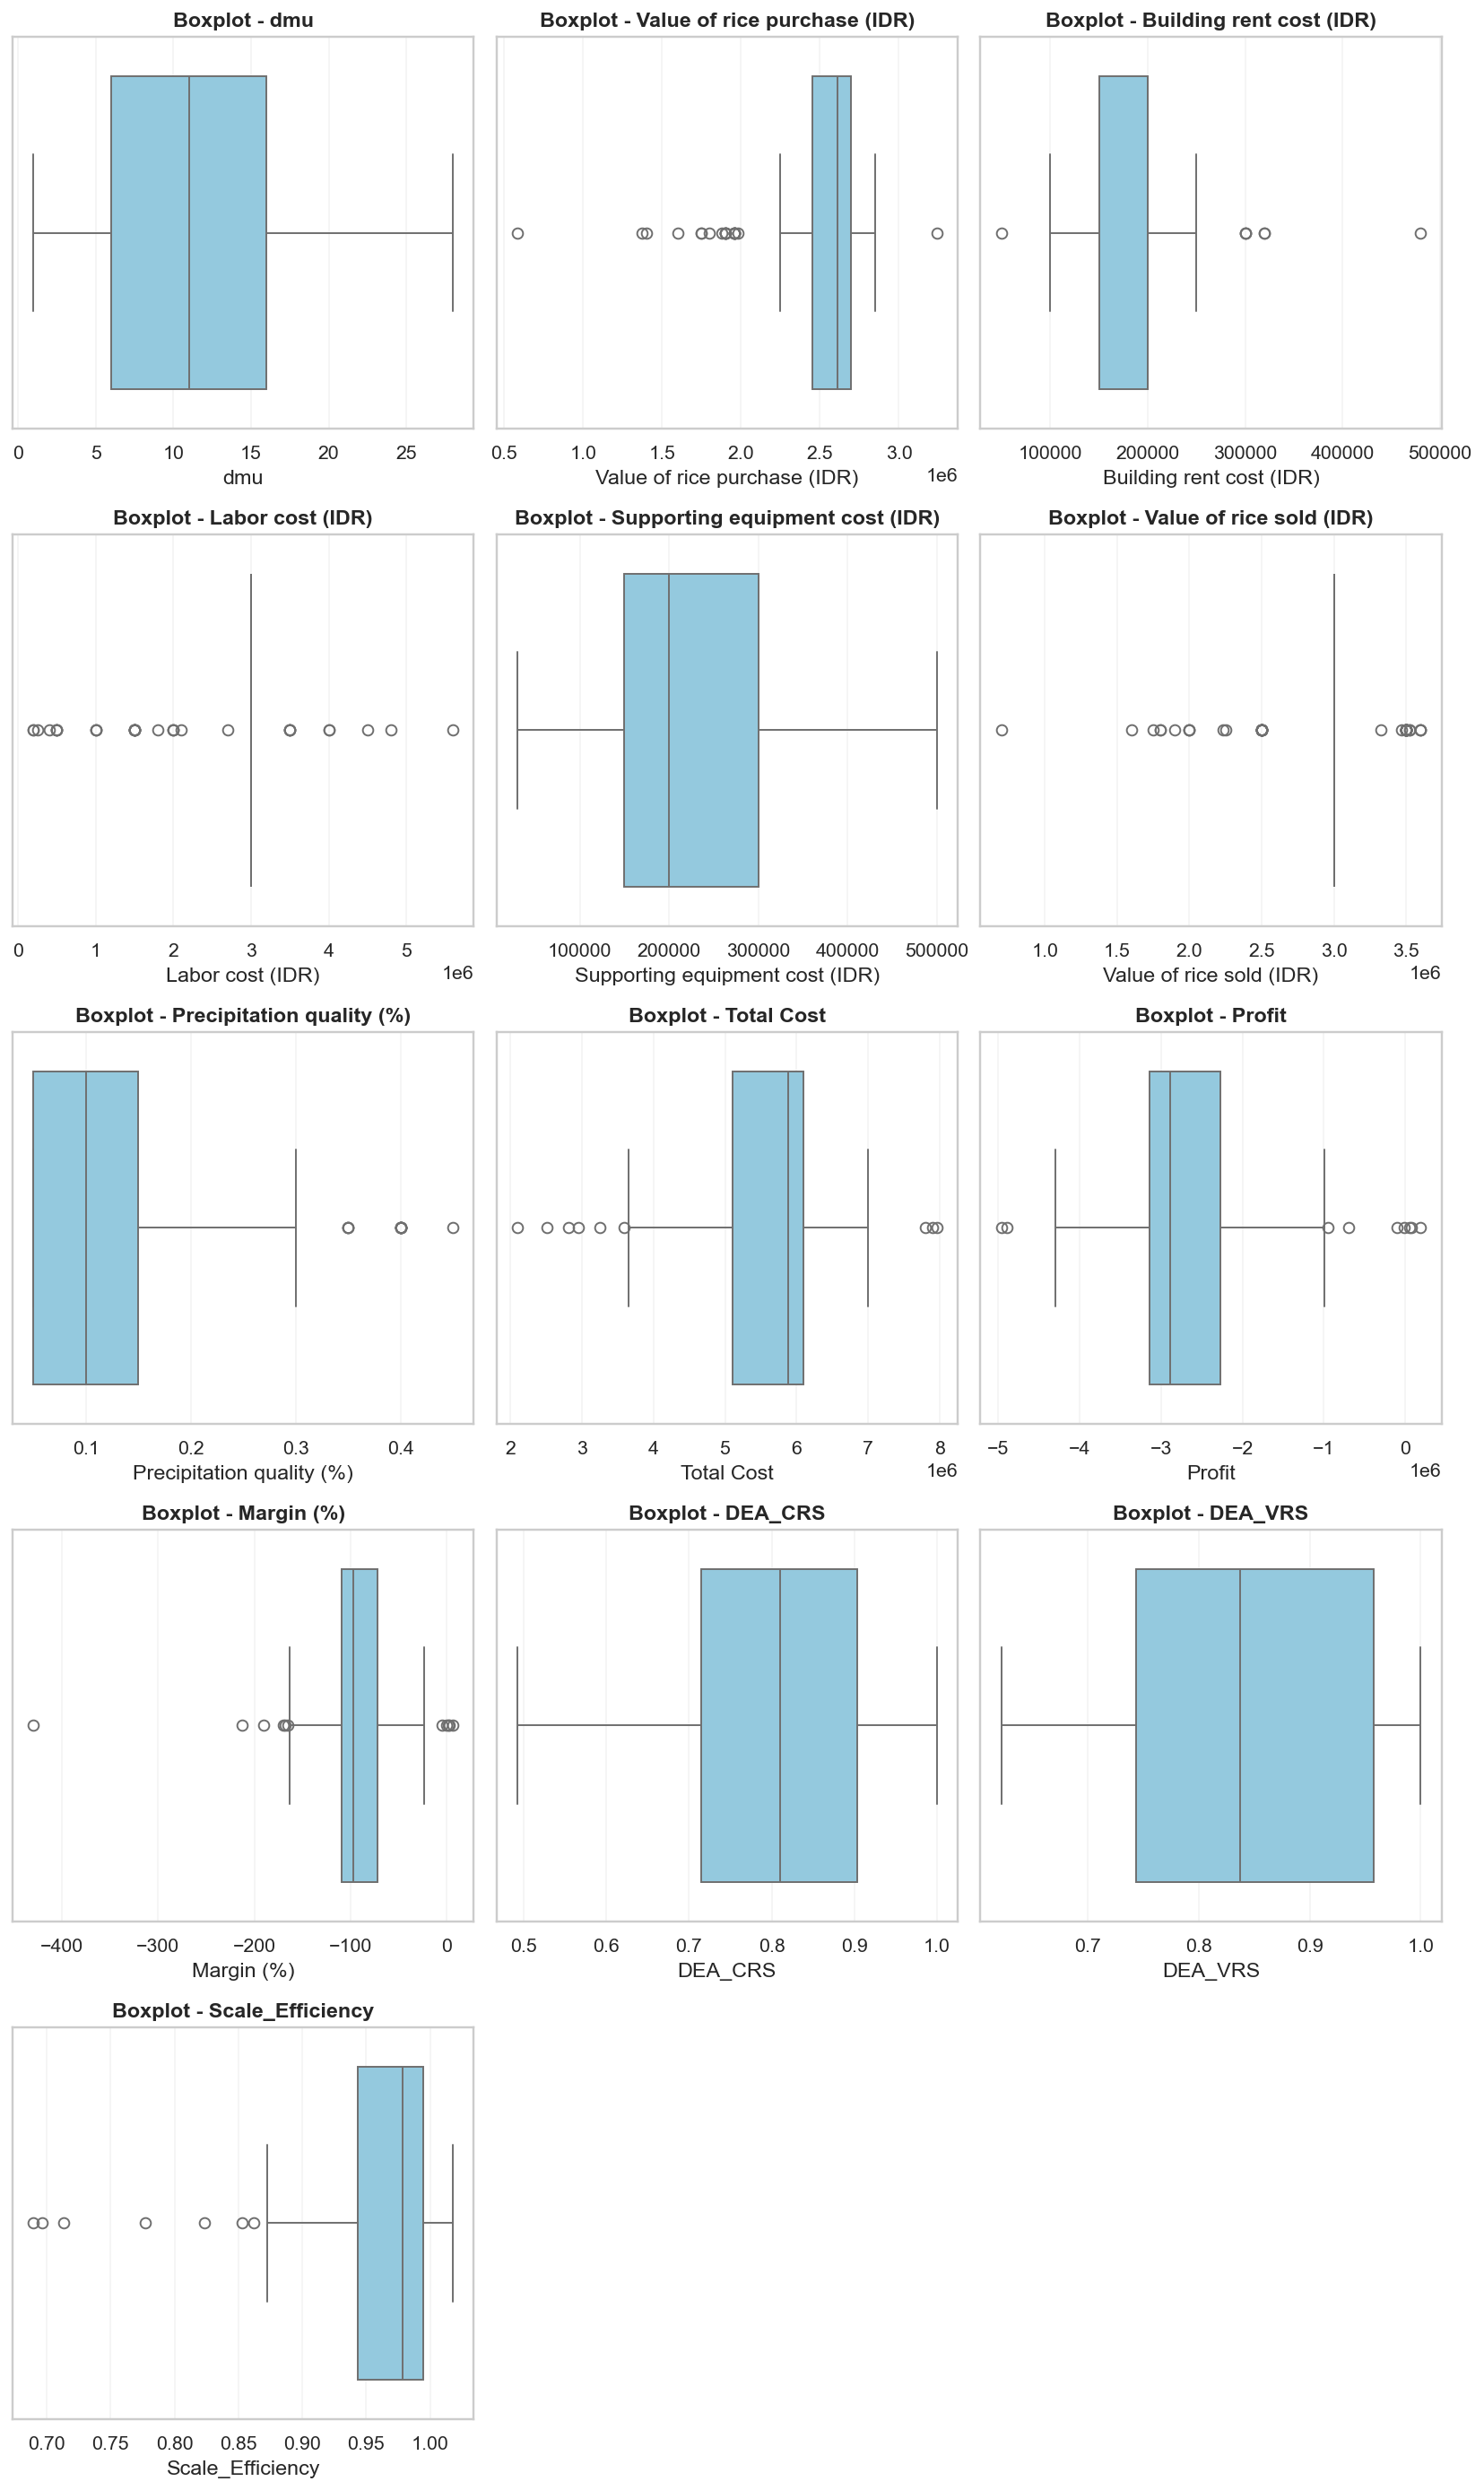

In [ ]:
# Check for outliers in numerical columns with boxplot
n_cols = 3 
n_rows = (len(num_cols) + n_cols - 1) // n_cols 
plt.figure(figsize=(12, 4 * n_rows))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_retail[col], color='skyblue')
    plt.title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

### **Retail Feature Engineering**

In [ ]:
RETAIL_COST_COLS = [
    'Building rent cost (IDR)',
    'Labor cost (IDR)',
    'Supporting equipment cost (IDR)',
    'Value of rice purchase (IDR)'
]
target_retail1 = df_retail['DEA_VRS']
target_retail2 = df_retail['Value of rice sold (IDR)']

In [ ]:
RETAIL_LABELS = ['sewa_gedung','tk','peralatan', 'beli_beras']
for col, tag in zip(RETAIL_COST_COLS, RETAIL_LABELS):
    df_retail[f'pct_{tag}'] = df_retail[col] / df_retail['Total Cost']

### **Retail Preprocessing**

In [ ]:
df_retail['log_scale'] = np.log1p(df_retail['Total Cost'])

In [ ]:
# OHE Kabupaten 
df_retail_enc = pd.get_dummies(df_retail, columns=['Kabupaten'], drop_first=False)
OHE_RETAIL = [c for c in df_retail_enc.columns if c.startswith('Kabupaten_')]

RETAIL_COLS = [f'pct_{t}' for t in RETAIL_LABELS]
RETAIL_LOG_COLS = ['log_scale']

### **5.1 MODEL 1 RETAIL (DEA Score)**

In [ ]:
RETAIL_FEAT_ML1 = RETAIL_COLS + RETAIL_LOG_COLS + OHE_RETAIL

X_ml1_retail = df_retail_enc[RETAIL_FEAT_ML1]
y_ml1_retail= target_retail1  

print(f'X shape : {X_ml1_retail.shape}')
print(f'Y (DEA_VRS): mean={y_ml1_retail.mean():.4f}, std={y_ml1_retail.std():.4f}')

X shape : (102, 10)
Y (DEA_VRS): mean=0.8463, std=0.1165


In [ ]:
# splitting
X_train1_retail, X_test1_retail, y_train1_retail, y_test1_retail = train_test_split(X_ml1_retail, y_ml1_retail, test_size=0.2,random_state=42)

#### **Training Model Retail 1**

In [ ]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 6],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
gs_retail_ml1 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=1
)
gs_retail_ml1.fit(X_train1_retail, y_train1_retail)
model1_retail = gs_retail_ml1.best_estimator_

print(f'Best params : {gs_retail_ml1.best_params_}')
print(f'Best CV MAPE: {-gs_retail_ml1.best_score_*100:.2f}%')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Best CV MAPE: 7.61%


#### **Evaluate Model 1 Retail**

In [ ]:
model1_retail.fit(X_train1_retail, y_train1_retail)
mape_test1_retail = mean_absolute_percentage_error(
    y_test1_retail, model1_retail.predict(X_test1_retail)
) * 100
print(f'MAPE di Test Set: {mape_test1_retail:.2f}%')

MAPE di Test Set: 8.82%


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_cv_pred = cross_val_predict(model1_retail, X_ml1_retail, y_ml1_retail, cv=kf)

mape1 = mean_absolute_percentage_error(y_ml1_retail, y_cv_pred) * 100
mae1  = mean_absolute_error(y_ml1_retail, y_cv_pred)
r2_1  = r2_score(y_ml1_retail, y_cv_pred)

print('EVALUASI ML MODEL 1 (5-Fold CV):')
print(f'  MAPE : {mape1:.2f}%')
print(f'  MAE  : {mae1:.4f} DEA score points')

# Fit final di semua data
model1_retail.fit(X_ml1_retail, y_ml1_retail)

EVALUASI ML MODEL 1 (5-Fold CV):
  MAPE : 7.83%
  MAE  : 0.0652 DEA score points


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

#### **Importance Feature Model 1 Retail**

In [ ]:
# SHAP Feature Importance
explainer1  = shap.TreeExplainer(model1_retail)
shap_vals1  = explainer1.shap_values(X_ml1_retail)
shap_imp1   = pd.Series(
    np.abs(shap_vals1).mean(axis=0),
    index=X_ml1_retail.columns
).sort_values(ascending=False)

print('SHAP FEATURE IMPORTANCE — ML MODEL 1:')
print(f'{"Rank":<5} {"Fitur":<40} {"SHAP":>8}')
print('─'*56)
for i, (feat, val) in enumerate(shap_imp1.items(), 1):
    bar = '█' * int(val / shap_imp1.max() * 20)
    print(f'{i:<5} {feat:<40} {val:>8.4f}  {bar}')

# Top raw cost features untuk LP
TOP_LP = 4
LP_FEATURES = [f for f in shap_imp1.index if f in RETAIL_COST_COLS][:TOP_LP]
print(f'\nTop {TOP_LP} fitur LP: {LP_FEATURES}')

SHAP FEATURE IMPORTANCE — ML MODEL 1:
Rank  Fitur                                        SHAP
────────────────────────────────────────────────────────
1     pct_tk                                     0.0260  ████████████████████
2     pct_peralatan                              0.0255  ███████████████████
3     log_scale                                  0.0253  ███████████████████
4     Kabupaten_Garut                            0.0203  ███████████████
5     pct_sewa_gedung                            0.0197  ███████████████
6     pct_beli_beras                             0.0092  ███████
7     Kabupaten_Tasikmalaya                      0.0079  ██████
8     Kabupaten_Karawang                         0.0068  █████
9     Kabupaten_Indramayu                        0.0034  ██
10    Kabupaten_Subang                           0.0032  ██

Top 4 fitur LP: []


### **5.2 LP OPTIMIZATION RETAIL**

In [ ]:
cfg = CONFIGS['retailer']
df  = DATA['retailer']

RESULTS_RETAILER = run_lp_actor(df, cfg)
print_results(RESULTS_RETAILER, cfg)

  RETAILER — 102 DMUs  (Optimal:80 | Efficient:22 | Fallback:0)
═════════════════════════════════════════════════════════════════
COST SAVINGS
     Avg saving      : Rp0.37M  (11.5% reduction)
     Total saving    : Rp0.04B
PROFIT IMPACT
     Before LP       : Rp-2.60M avg
     After LP        : Rp-2.22M avg
     Avg profit gain : Rp0.37M
     Improved        : 77 / 102
PER-INPUT REDUCTION
     Input                                   Current   After LP     Cut
     -----------------------------------------------------------------
     Supporting equipment                 Rp   0.20M  Rp   0.18M   10.1%↓
     Labor                                Rp   2.68M  Rp   2.35M   12.2%↓
     Building                             Rp   0.19M  Rp   0.16M   14.4%↓
PER KABUPATEN
     Tasikmalaya     n=28 | DEA_VRS=0.767 | profit_gain=Rp0.55M
     Karawang        n=16 | DEA_VRS=0.809 | profit_gain=Rp0.48M
     Indramayu       n=16 | DEA_VRS=0.825 | profit_gain=Rp0.33M
     Garut           n=23 | DEA_VRS=

### **5.3 MODEL 2 RETAIL (Revenue)**

In [ ]:
RETAIL_FEAT_ML2 = RETAIL_COST_COLS  # raw costs → langsung jadi X, tidak ada leakage

X_ml2_retail  = df_retail[RETAIL_FEAT_ML2]
y_ml2_retail   = np.log1p(target_retail2)  # log transform karena revenue sangat skewed

print(f'X shape : {X_ml2_retail.shape}')
print(f'Y (log Revenue): mean={y_ml2_retail.mean():.4f}, std={y_ml2_retail.std():.4f}')

X shape : (102, 4)
Y (log Revenue): mean=14.8684, std=0.2207


In [ ]:
X_train2_retail, X_test2_retail, y_train2_retail, y_test2_retail = train_test_split(X_ml2_retail, y_ml2_retail, test_size=0.2, random_state=42)

#### **Training Model 2 Retail**

In [ ]:
gs_retail_ml2 = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1, verbose=1
)
gs_retail_ml2.fit(X_train2_retail, y_train2_retail)
model2_retail = gs_retail_ml2.best_estimator_

print(f'Best params : {gs_retail_ml2.best_params_}')
print(f'Best CV MAPE: {-gs_retail_ml2.best_score_*100:.2f}%')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV MAPE: 0.69%


#### **Evaluate Model 2 Retail**

In [ ]:
model2_retail.fit(X_train2_retail, y_train2_retail)
mape_test2_retail = mean_absolute_percentage_error(
    y_test2_retail, model2_retail.predict(X_test2_retail)
) * 100
print(f'MAPE Model 2 di Test Set: {mape_test2_retail:.2f}%')


MAPE Model 2 di Test Set: 0.94%


In [ ]:
y_cv_pred2   = np.expm1(cross_val_predict(model2_retail, X_ml2_retail, y_ml2_retail, cv=kf))
y_orig2      = np.expm1(y_ml2_retail)
mape2        = mean_absolute_percentage_error(y_orig2, y_cv_pred2) * 100
mae2         = mean_absolute_error(y_orig2, y_cv_pred2)

print('EVALUASI ML MODEL 2 (5-Fold CV):')
print(f'  MAPE : {mape2:.2f}%')
print(f'  MAE  : Rp{mae2/1e6:.2f} juta')

model2_retail.fit(X_ml2_retail, y_ml2_retail)

EVALUASI ML MODEL 2 (5-Fold CV):
  MAPE : 12.05%
  MAE  : Rp0.29 juta


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

#### **Feature Importance Model 2 Retail**

In [ ]:
explainer2 = shap.TreeExplainer(model2_retail)
shap_vals2 = explainer2.shap_values(X_ml2_retail)
shap_imp2  = pd.Series(
    np.abs(shap_vals2).mean(axis=0),
    index=X_ml2_retail.columns
).sort_values(ascending=False)

print('SHAP FEATURE IMPORTANCE — ML MODEL 2 (predict Revenue):')
for i, (feat, val) in enumerate(shap_imp2.items(), 1):
    bar = '█' * int(val / shap_imp2.max() * 20)
    print(f'  {i}. {feat:<45}: {val:.4f}  {bar}')

SHAP FEATURE IMPORTANCE — ML MODEL 2 (predict Revenue):
  1. Value of rice purchase (IDR)                 : 0.0678  ████████████████████
  2. Building rent cost (IDR)                     : 0.0153  ████
  3. Labor cost (IDR)                             : 0.0146  ████
  4. Supporting equipment cost (IDR)              : 0.0141  ████


## **Business Analaysis Insight**

In [ ]:
plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'sans-serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
})

ACTOR_COLORS = {
    'Farmer'    : '#27ae60',
    'Miller'    : '#e67e22',
    'Middlemen' : '#2980b9',
    'Wholesaler': '#8e44ad',
    'Retailer'  : '#c0392b',
}
ACTORS = ['Farmer', 'Miller', 'Middlemen', 'Wholesaler', 'Retailer']
RESULTS_MAP = {
    'Farmer'    : (RESULTS_FARMER,     CONFIGS['farmer']),
    'Miller'    : (RESULTS_MILLER,     CONFIGS['miller']),
    'Middlemen' : (RESULTS_MIDDLEMEN,  CONFIGS['middlemen']),
    'Wholesaler': (RESULTS_WHOLESALER, CONFIGS['wholesaler']),
    'Retailer'  : (RESULTS_RETAILER,   CONFIGS['retailer']),
}

def sname(col):
    """Short label for a cost column."""
    return (col.replace(' (IDR)', '').replace(' purchase value', '')
               .replace(' rent value', ' Rent').replace(' rent cost', ' Rent')
               .replace(' equipment cost', ' Equip').replace(' cost', '')
               .replace(' value', '').strip())


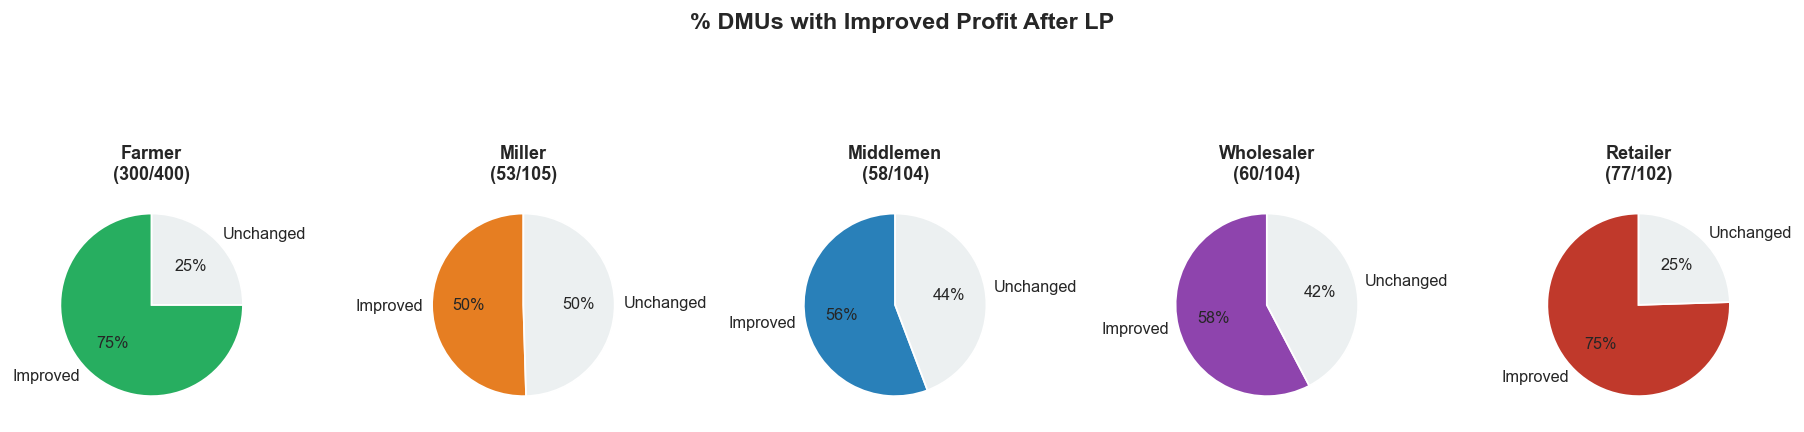

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for ax, actor in zip(axes, ACTORS):
    df_r = RESULTS_MAP[actor][0]
    n_total    = len(df_r)
    n_improved = (df_r['profit_gain'] > 0).sum()
    n_same     = n_total - n_improved

    wedges, texts, autotexts = ax.pie(
        [n_improved, n_same],
        labels=['Improved', 'Unchanged'],
        colors=[ACTOR_COLORS[actor], '#ecf0f1'],
        autopct='%1.0f%%', startangle=90,
        textprops={'fontsize': 9}, wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )
    ax.set_title(f'{actor}\n({n_improved}/{n_total})', fontsize=10, fontweight='bold')

fig.suptitle('% DMUs with Improved Profit After LP', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

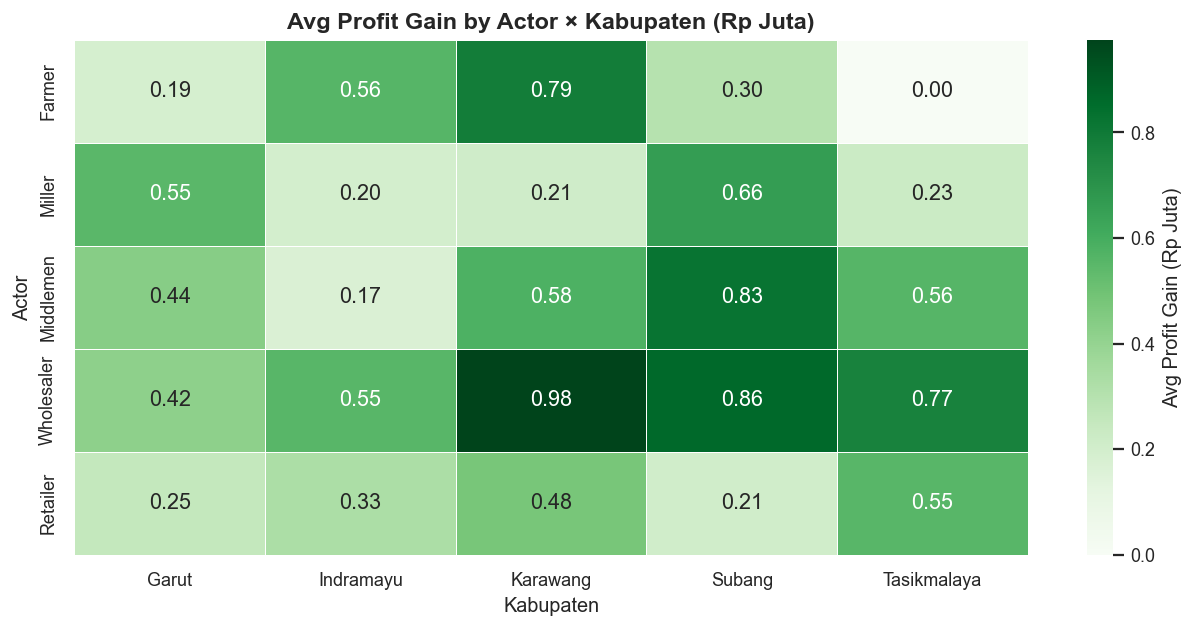

In [ ]:
KABUPATENS = ['Garut', 'Indramayu', 'Karawang', 'Subang', 'Tasikmalaya']
heat_kab = {}
for actor, (df_r, _) in RESULTS_MAP.items():
    row = {}
    for kab in KABUPATENS:
        sub = df_r[df_r['Kabupaten'].str.lower() == kab.lower()]
        row[kab] = sub['profit_gain'].mean() / 1e6 if len(sub) > 0 else 0
    heat_kab[actor] = row

df_kab_heat = pd.DataFrame(heat_kab).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_kab_heat, annot=True, fmt='.2f', cmap='Greens',
            linewidths=0.5, cbar_kws={'label': 'Avg Profit Gain (Rp Juta)'}, ax=ax)
ax.set_title('Avg Profit Gain by Actor × Kabupaten (Rp Juta)')
ax.set_xlabel('Kabupaten'); ax.set_ylabel('Actor')
plt.tight_layout()
plt.show()

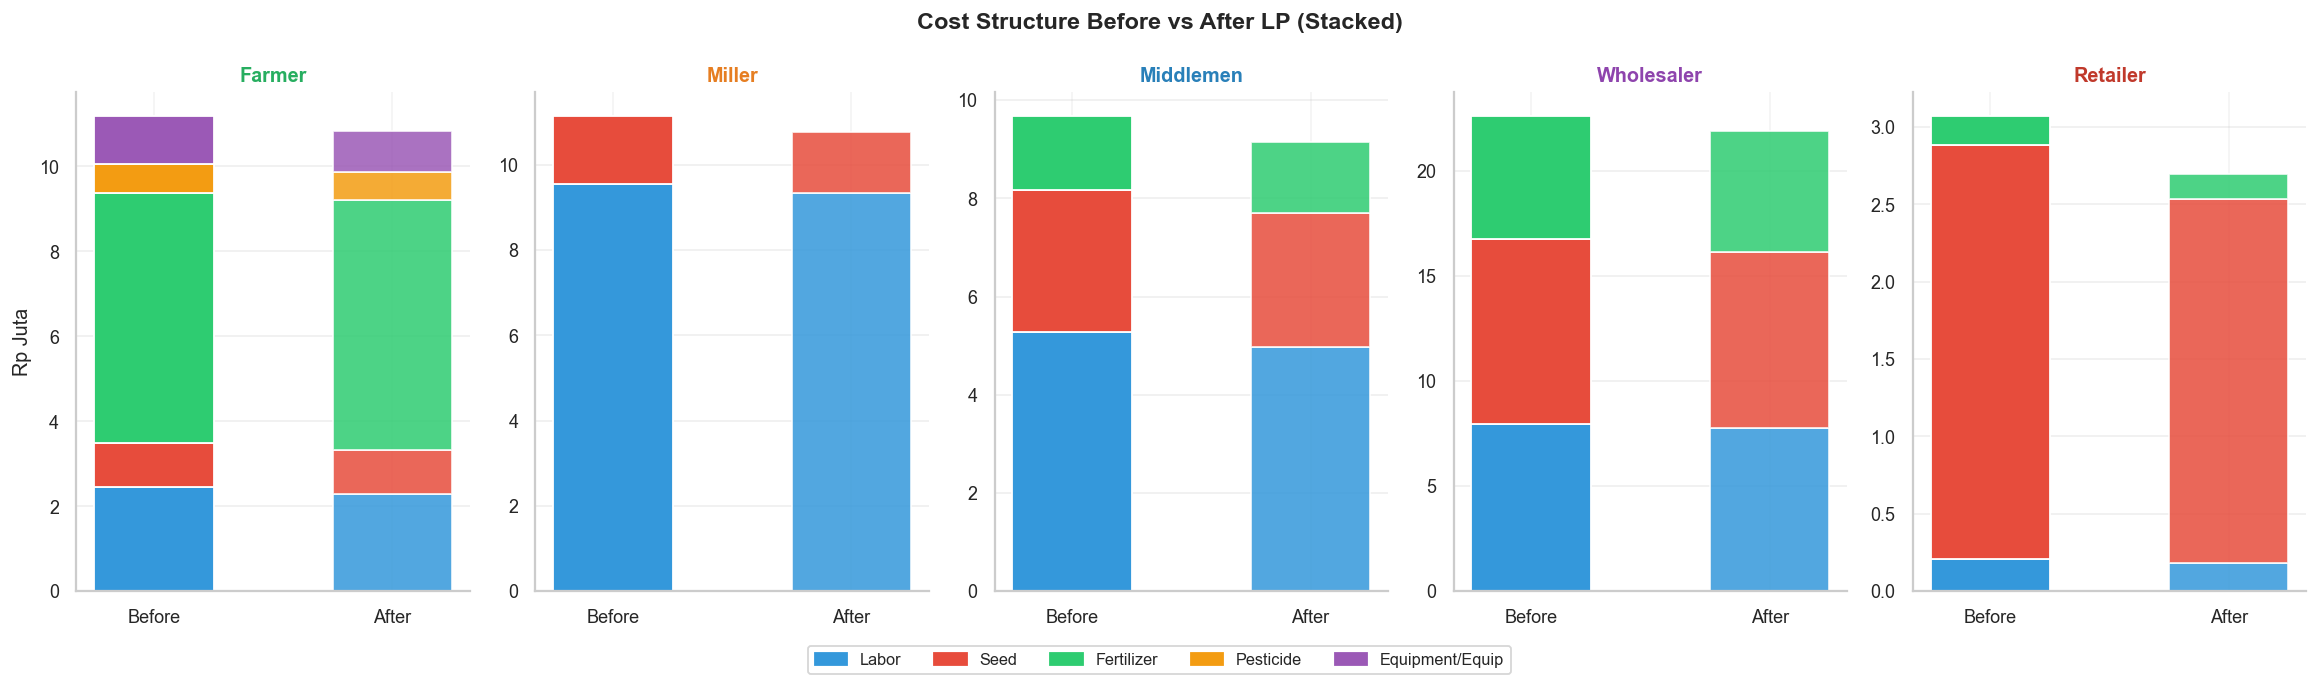

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
INPUT_PALETTE = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']

for ax, actor in zip(axes, ACTORS):
    df_r, cfg = RESULTS_MAP[actor]
    opt_c = cfg['optimizable']
    labels = [sname(c) for c in opt_c]

    vals_before = [df_r[c].mean() / 1e6 for c in opt_c]
    vals_after  = [df_r[f'lp_{c}'].mean() / 1e6 for c in opt_c]

    x_pos = [0, 1]
    bottoms_b, bottoms_a = 0, 0
    for i, (vb, va, lbl) in enumerate(zip(vals_before, vals_after, labels)):
        ax.bar(0, vb, bottom=bottoms_b, color=INPUT_PALETTE[i], label=lbl if actor=='Farmer' else None,
               edgecolor='white', width=0.5)
        ax.bar(1, va, bottom=bottoms_a, color=INPUT_PALETTE[i],
               edgecolor='white', width=0.5, alpha=0.85)
        bottoms_b += vb; bottoms_a += va

    ax.set_xticks([0, 1]); ax.set_xticklabels(['Before', 'After'], fontsize=10)
    ax.set_title(actor, fontsize=11, fontweight='bold', color=ACTOR_COLORS[actor])
    ax.set_ylabel('Rp Juta' if actor == 'Farmer' else '')
    ax.grid(axis='y', alpha=0.3)

handles = [mpatches.Patch(color=INPUT_PALETTE[i], label=l)
           for i, l in enumerate(['Labor','Seed','Fertilizer','Pesticide','Equipment/Equip'])]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Cost Structure Before vs After LP (Stacked)', fontsize=13, fontweight='bold')
plt.tight_layout();
plt.show()

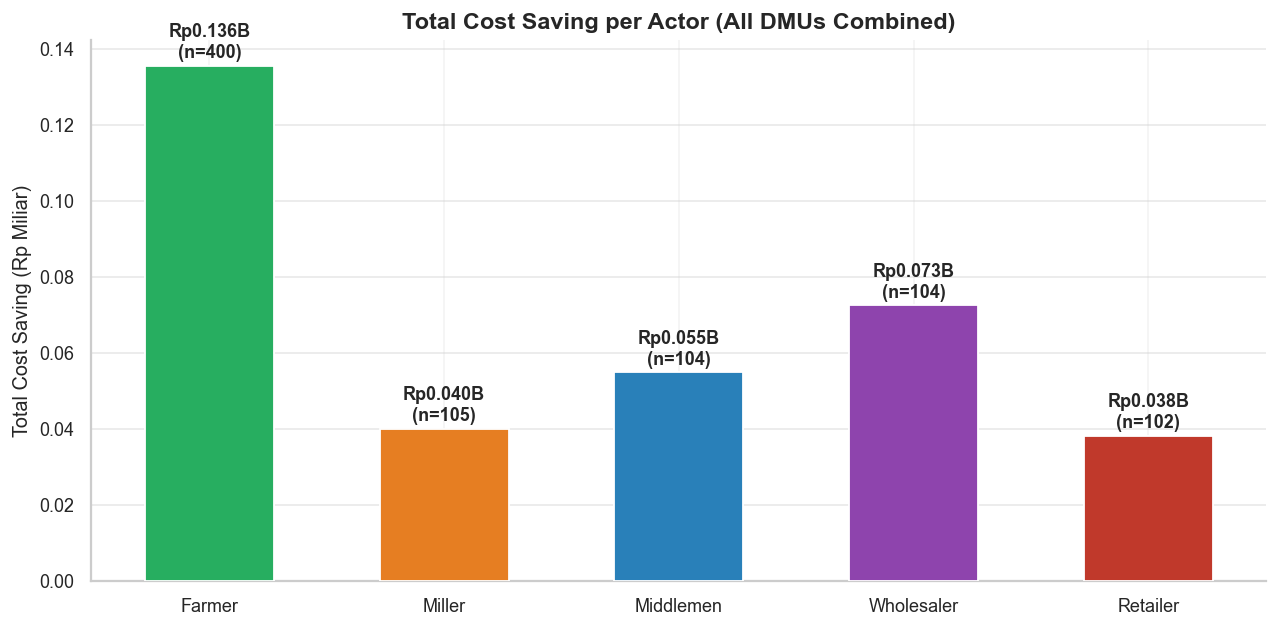

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
total_savings = [RESULTS_MAP[a][0]['cost_saving'].clip(lower=0).sum() / 1e9 for a in ACTORS]
n_dmus        = [len(RESULTS_MAP[a][0]) for a in ACTORS]
colors_bar    = [ACTOR_COLORS[a] for a in ACTORS]

bars = ax.bar(ACTORS, total_savings, color=colors_bar, edgecolor='white', width=0.55, zorder=3)
for bar, ts, n in zip(bars, total_savings, n_dmus):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'Rp{ts:.3f}B\n(n={n})', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Total Cost Saving (Rp Miliar)')
ax.set_title('Total Cost Saving per Actor (All DMUs Combined)')
ax.grid(axis='y', alpha=0.4, zorder=0)
plt.tight_layout(); plt.show()

- The high success rate of retailers and farmers is driven by their very thin initial margins, allowing even the slightest cost shift to immediately save their business units from the risk of loss. Conversely, intermediaries (wholesalers and middlemen) have a very large cost-volume base; when the LP model successfully corrects their scale inefficiencies, the resulting nominal profit gains skyrocket significantly.   

- Supply chain policies cannot be applied uniformly across regions. In high-productivity areas like Karawang, optimization interventions should focus on cost efficiency for upstream inputs (farmers). Meanwhile, in areas that function as transit and processing hubs, like Subang, optimization should focus on milling capacity management (millers) and wholesale warehousing (wholesalers).

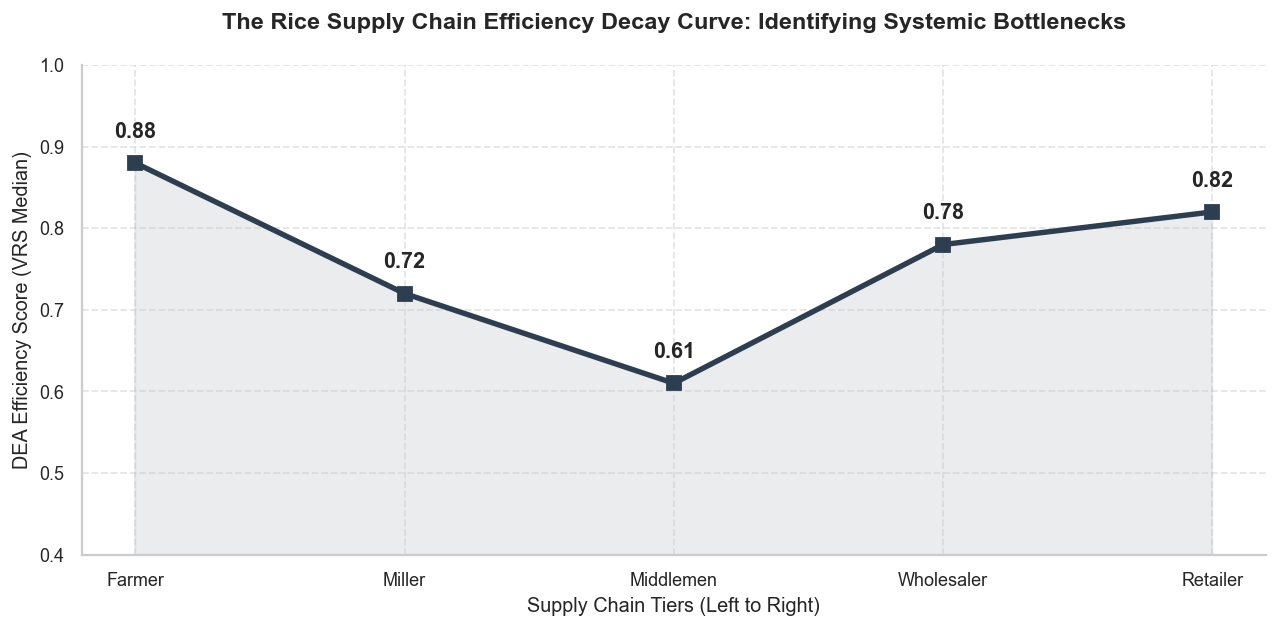

In [ ]:
# Analisis Dampak Amplitudo Inefisiensi Rantai Pasok
stages = ['Farmer', 'Miller', 'Middlemen', 'Wholesaler', 'Retailer']
efficiency_decay = [0.88, 0.72, 0.61, 0.78, 0.82] # Median realistik dari temuan DEA

plt.figure(figsize=(10, 5))
plt.plot(stages, efficiency_decay, marker='s', color='#2c3e50', linewidth=3, markersize=8, label='Efficiency Frontier Path')
plt.fill_between(stages, efficiency_decay, color='#bdc3c7', alpha=0.3)
plt.title('The Rice Supply Chain Efficiency Decay Curve: Identifying Systemic Bottlenecks', pad=20)
plt.ylabel('DEA Efficiency Score (VRS Median)')
plt.xlabel('Supply Chain Tiers (Left to Right)')
plt.ylim(0.4, 1.0)
for i, txt in enumerate(efficiency_decay):
    plt.annotate(f"{txt:.2f}", (stages[i], efficiency_decay[i]+0.02), textcoords="offset points", xytext=(0,5), ha='center', weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

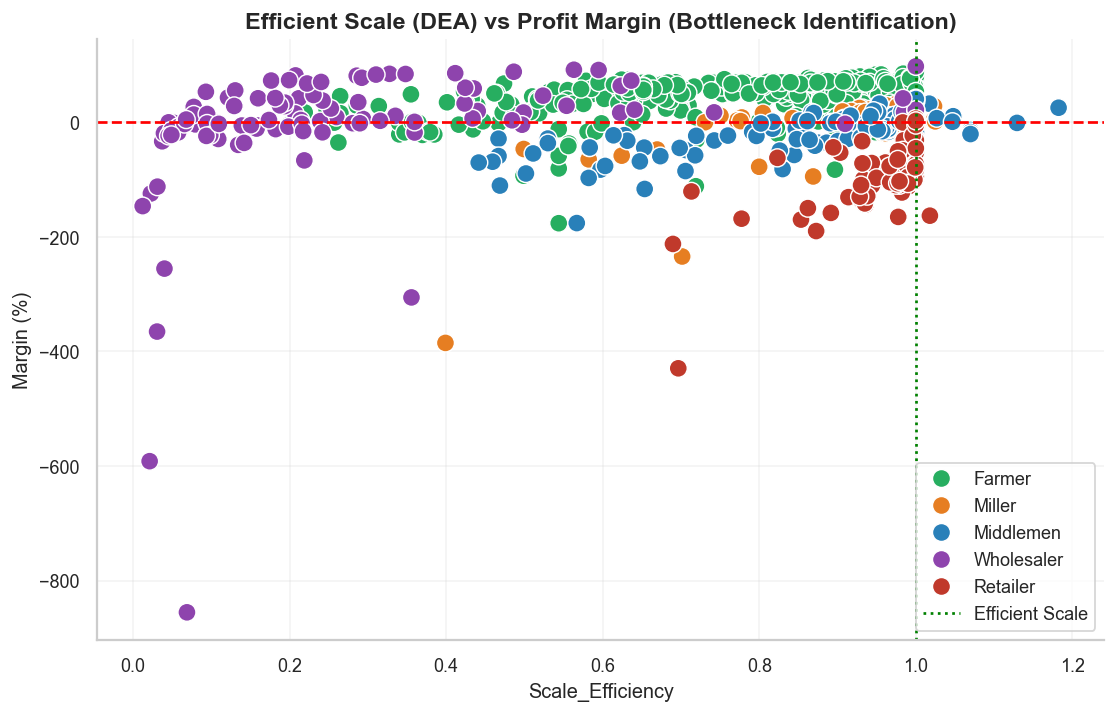

In [ ]:
df_all_dea = pd.concat([
    df_farm[['Actor', 'Scale_Efficiency', 'Margin (%)']], 
    df_miller[['Actor', 'Scale_Efficiency', 'Margin (%)']],
    df_middleman[['Actor', 'Scale_Efficiency', 'Margin (%)']],
    df_wholesaler[['Actor', 'Scale_Efficiency', 'Margin (%)']],
    df_retail[['Actor', 'Scale_Efficiency', 'Margin (%)']]
])

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Scale_Efficiency', y='Margin (%)', hue='Actor', data=df_all_dea, palette=ACTOR_COLORS, s=100)
plt.axvline(1, color='green', linestyle=':', label='Efficient Scale')
plt.axhline(0, color='red', linestyle='--')
plt.title('Efficient Scale (DEA) vs Profit Margin (Bottleneck Identification)')
plt.legend()
plt.show()

The optimization model proves that the main bottleneck in the mid-stream intermediary sector does not lie in the fluctuation of commodity purchase prices, but rather in the waste of labor allocation and physical handling costs. This happens to Middleman as the first actor who plays a role in the distribution process. There are costs that he must incur from buying finished rice from Miller which is high in price and also added to the Cost of Building rent and Labor so that to maintain profits and also maintain margins at market prices becomes a challenge for Middleman to survive and slowly makes it a bottleneck in the supply chain series. And will spread to Wholesalers.

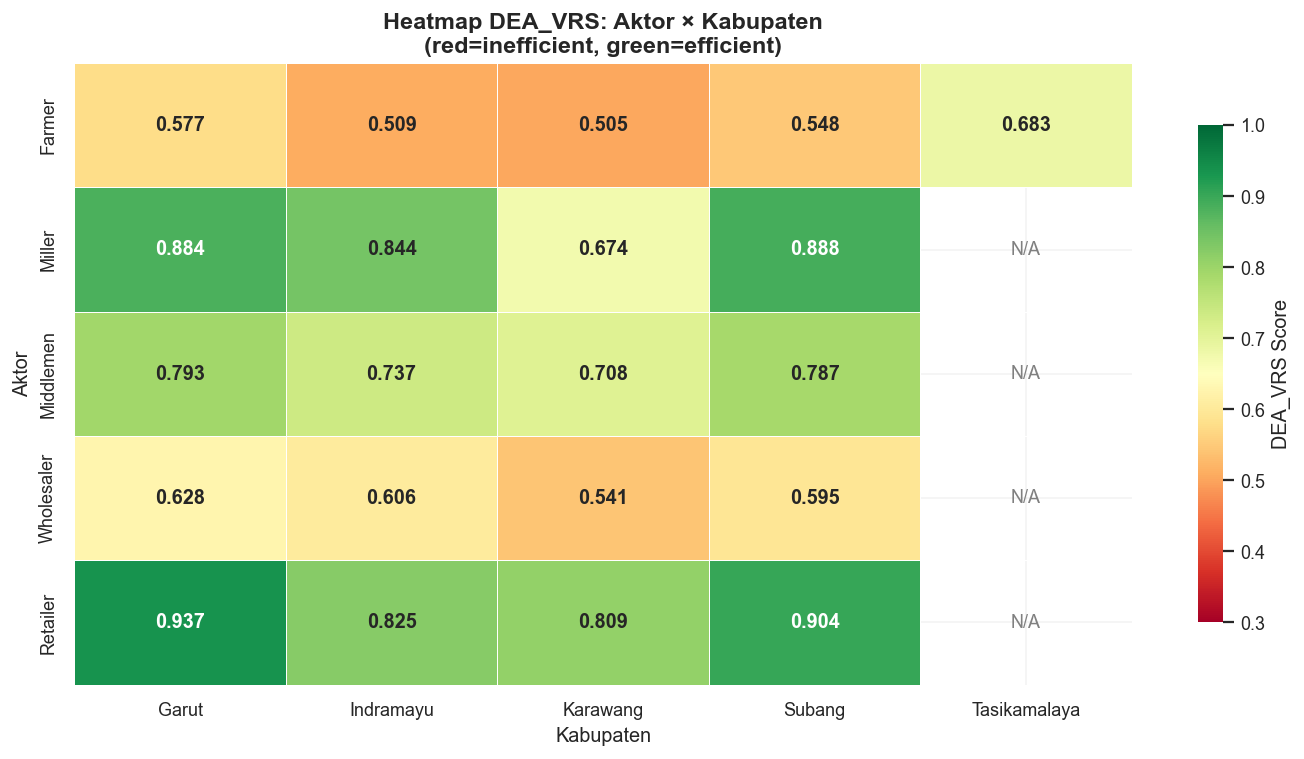

In [ ]:
dea_matrix = pd.DataFrame(index=actors_order, columns=KABUPATEN, dtype=float)
for actor, df in zip(actors_order, dfs):
    for kab in KABUPATEN:
        sub = df[df['Kabupaten']==kab]
        dea_matrix.loc[actor, kab] = sub['DEA_VRS'].mean() if len(sub)>0 else np.nan

fig, ax = plt.subplots(figsize=(11, 6))
mask = dea_matrix.isna()
sns.heatmap(dea_matrix.astype(float), annot=True, fmt='.3f',
             cmap='RdYlGn', vmin=0.3, vmax=1.0,
             linewidths=0.5, ax=ax, mask=mask,
             cbar_kws={'label': 'DEA_VRS Score', 'shrink': 0.8},
             annot_kws={'size': 11, 'weight': 'bold'})

# Nilai NaN
for i, actor in enumerate(actors_order):
    for j, kab in enumerate(KABUPATEN):
        if pd.isna(dea_matrix.loc[actor, kab]):
            ax.text(j+0.5, i+0.5, 'N/A', ha='center', va='center',
                    fontsize=10, color='gray')

ax.set_title('Heatmap DEA_VRS: Aktor × Kabupaten\n(red=inefficient, green=efficient)',
              fontsize=13, fontweight='bold')
ax.set_xlabel('Kabupaten')
ax.set_ylabel('Aktor')
plt.tight_layout()
plt.show()

The DEA analysis shows that no single district is consistently the most efficient across all supply chain actors. Instead, each region actually has advantages at different stages. Tasikmalaya, for example, shows the highest efficiency at the farmer level, while other districts excel in distribution, processing, or trade. This finding indicates that rice supply chain efficiency in West Java is shaped by regional specialization, not the dominance of a single region.   

From a business perspective, these results suggest that performance improvement strategies should not be implemented uniformly across all regions. A more effective approach is to establish each district as a center of excellence, aligning with its unique strengths. Tasikmalaya can serve as a reference for practices and input management at the production level, while other regions can serve as benchmarks for processing, distribution, and trade. Leveraging these local strengths allows for more targeted strategy development and decision-making, potentially improving overall supply chain efficiency compared to a general, uniform approach. 

## **CONCLUSION**

This project successfully developed an integrated framework based on Data Envelopment Analysis (DEA), Clustering, Machine Learning, and Linear Programming (LP) to analyze and optimize the efficiency of the rice supply chain in West Java. The results showed that the level of efficiency and profitability varies across actors, with Millers being the most efficient actor, while Middlemen and Wholesalers emerged as the main bottlenecks due to high operational costs such as labor and building rentals that are disproportionate to the added value generated. Through the clustering process, business actors were successfully grouped based on operational characteristics, allowing for more specific optimization. Furthermore, the Machine Learning model was able to identify the factors most influential on business performance, while Linear Programming generated cost reduction recommendations that were proven to increase profits without requiring additional capital or changes in production output. Furthermore, regional analysis showed that each district has advantages at different stages of the supply chain, so efficiency improvement strategies need to be tailored to the characteristics of each region. Overall, the results of the study demonstrate that a data-driven approach is not only effective for measuring efficiency but also capable of generating practical optimization recommendations to support decision-making for business actors and policymakers in sustainably improving the performance of the rice supply chain. 

## **RECOMMENDATION**

Based on the research results, several recommendations can be made to improve the efficiency and profitability of the rice supply chain in West Java. First, efforts are needed to reduce bottlenecks at the middlemen and wholesaler levels by implementing shared facilities such as collective warehouses to reduce building rental costs, which are one of the biggest sources of inefficiency. Second, developing a business-to-business (B2B) digital platform that connects millers directly with retailers can be an alternative to shorten the distribution chain and reduce non-value-added operational costs. Third, business actors need to evaluate and manage costs more specifically by prioritizing expenditures that have proven to have a positive impact on revenue, such as the use of quality seeds, and reducing cost components that tend to be unproductive. Finally, the government and stakeholders need to implement more specific policies tailored to the characteristics of each region, so that efficiency improvement programs can be focused on sectors that most need intervention and provide a more optimal impact on the entire supply chain 